In [5]:
!pip install wfdb


In [6]:
!pip install wfdb pywavelets


In [16]:
!wget -r -N -c -np https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip
!unzip mit-bih-arrhythmia-database-1.0.0.zip


--2025-05-06 05:53:25--  https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 304 Not Modified
File ‘physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip’ not modified on server. Omitting download.

unzip:  cannot find or open mit-bih-arrhythmia-database-1.0.0.zip, mit-bih-arrhythmia-database-1.0.0.zip.zip or mit-bih-arrhythmia-database-1.0.0.zip.ZIP.


In [4]:
!unzip physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip


Archive:  physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip
  inflating: mit-bih-arrhythmia-database-1.0.0/100.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/102-0.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/10

In [7]:
!pip install neurokit2


Signal shape: (10000,), Sampling frequency: 360 Hz


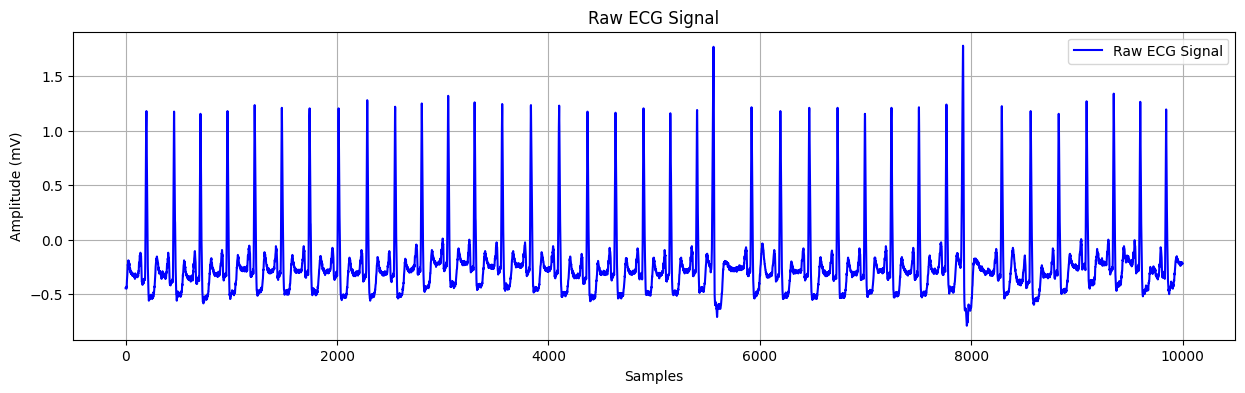

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, hilbert
import wfdb

# Use an abnormal record to test; record '228' is known to have abnormal morphology.
record_path = 'mit-bih-arrhythmia-database-1.0.0/105'
record = wfdb.rdrecord(record_path, sampto=10000)  # load a subset for quick testing
signal = record.p_signal[:, 0]  # select MLII lead
fs = record.fs  # sampling frequency
print(f"Signal shape: {signal.shape}, Sampling frequency: {fs} Hz")

# Plot raw ECG signal
plt.figure(figsize=(15, 4))
plt.plot(signal, color='blue', label='Raw ECG Signal')
plt.title('Raw ECG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True)
plt.show()


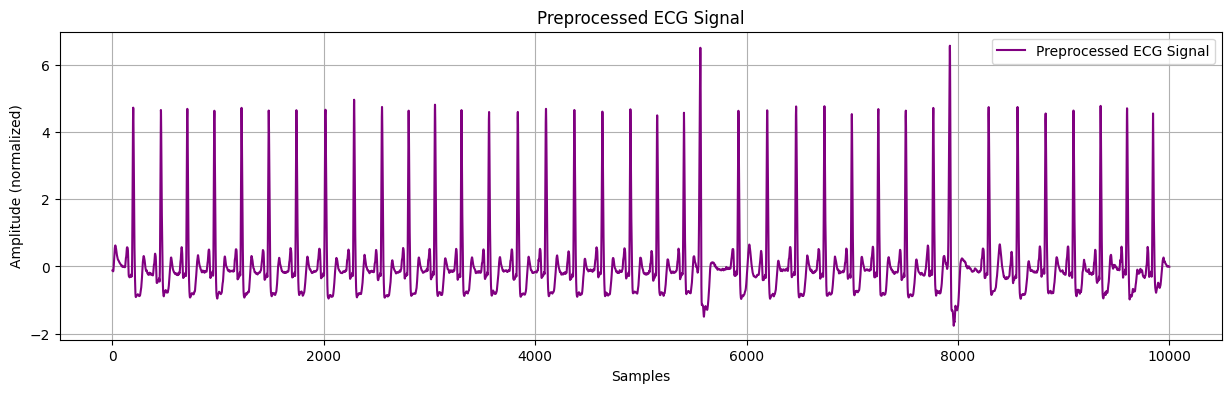

In [33]:
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def notch_filter(data, freq, fs, Q=30):
    nyq = 0.5 * fs
    freq_norm = freq / nyq
    b, a = iirnotch(freq_norm, Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    filtered_hp = filtfilt(b_hp, a_hp, signal)
    filtered_notch = notch_filter(filtered_hp, freq=50, fs=fs)
    b_lp, a_lp = butter_lowpass(40.0, fs)
    filtered_signal = filtfilt(b_lp, a_lp, filtered_notch)
    preprocessed = (filtered_signal - np.mean(filtered_signal)) / np.std(filtered_signal)
    return preprocessed

preprocessed_signal = preprocess_ecg(signal, fs)

plt.figure(figsize=(15, 4))
plt.plot(preprocessed_signal, color='purple', label='Preprocessed ECG Signal')
plt.title('Preprocessed ECG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (normalized)')
plt.legend()
plt.grid(True)
plt.show()


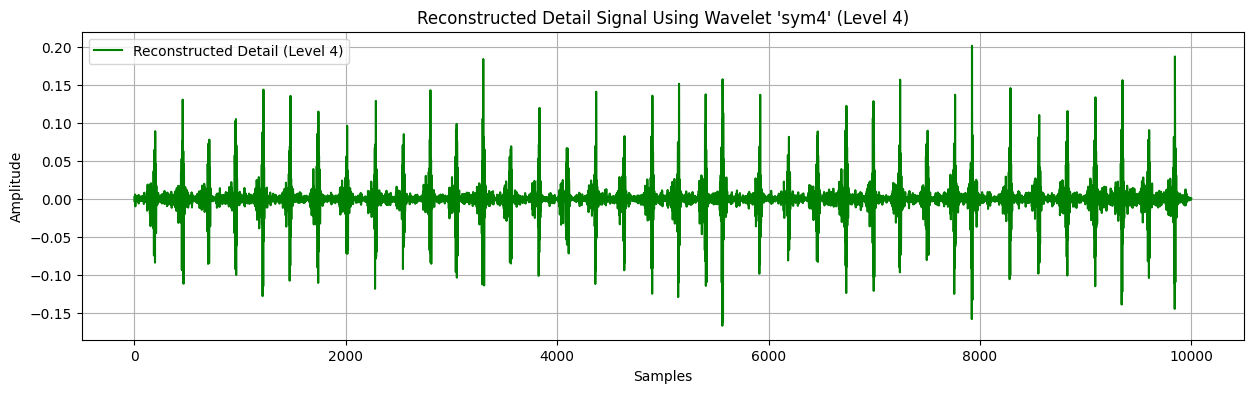

In [34]:
wavelet = 'sym4'
total_level = 5
detail_level = 4

coeffs = pywt.wavedec(preprocessed_signal, wavelet, level=total_level)
# Zero out all levels except the chosen detail level
for i in range(len(coeffs)):
    if i != detail_level:
        coeffs[i] = np.zeros_like(coeffs[i])
detail_signal = pywt.waverec(coeffs, wavelet)

plt.figure(figsize=(15, 4))
plt.plot(detail_signal, color='green', label=f'Reconstructed Detail (Level {detail_level})')
plt.title(f"Reconstructed Detail Signal Using Wavelet '{wavelet}' (Level {detail_level})")
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


Wavelet detector (Enhanced SWT Method) found 35 peaks.


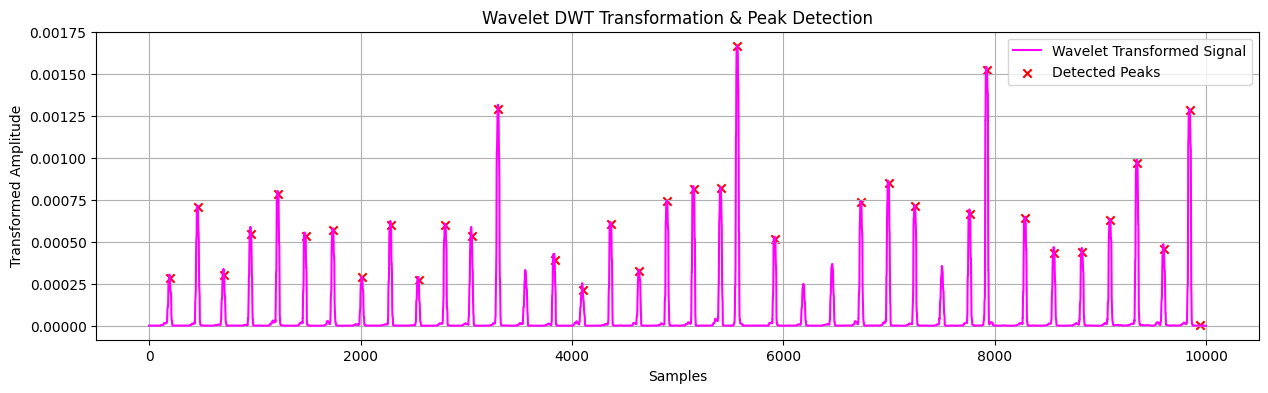

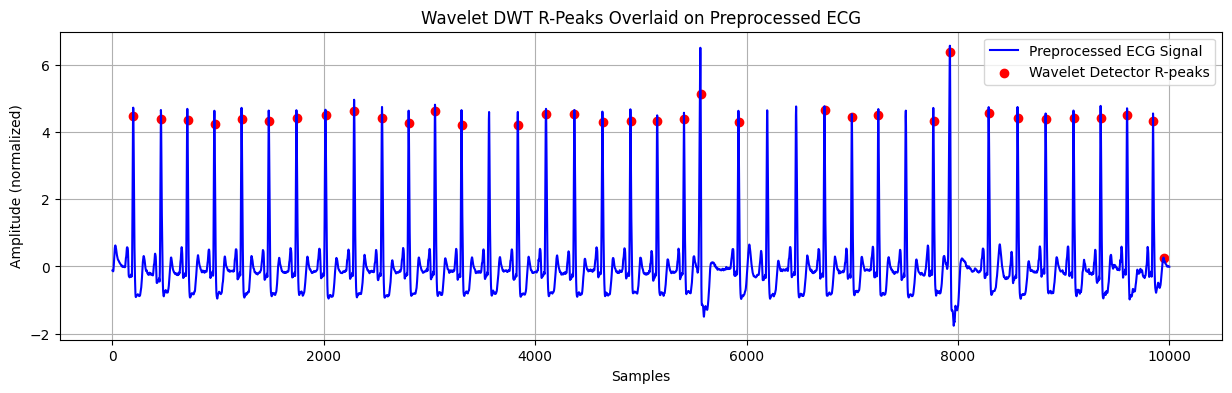

In [35]:

def refine_peak(signal, index, search_window=5):
    """
    Improved refinement: Also handle edge QRS morphologies by weighting peak selection.
    """
    start = max(index - search_window, 0)
    end = min(index + search_window + 1, len(signal))
    local_seg = signal[start:end]
    if np.median(local_seg) < 0:
        weighted_scores = -np.abs(local_seg) * np.linspace(1, 2, end - start)
        local_peak = np.argmax(weighted_scores)
    else:
        weighted_scores = np.abs(local_seg) * np.linspace(1, 2, end - start)
        local_peak = np.argmax(weighted_scores)
    return start + local_peak

def sliding_window_peak_detection_adaptive(signal, fs, window_sec=5, init_threshold_ratio=0.28, min_distance_sec=0.2):
    window_size = int(window_sec * fs)
    min_distance = int(min_distance_sec * fs)
    N = len(signal)
    detected_peaks = []
    step = window_size // 2
    acceptable_min = 3
    acceptable_max = 12
    max_iter = 12
    update_factor = 0.08

    for start in range(0, N, step):
        end = min(start + window_size, N)
        window_data = signal[start:end]
        ratio = init_threshold_ratio
        iteration = 0
        peaks = []
        while iteration < max_iter:
            local_thresh = ratio * np.max(window_data)
            peaks, _ = find_peaks(window_data, height=local_thresh, distance=min_distance)
            if acceptable_min <= len(peaks) <= acceptable_max:
                break
            if len(peaks) > acceptable_max:
                ratio *= (1 + update_factor)
            elif len(peaks) < acceptable_min:
                ratio *= (1 - update_factor)
            iteration += 1
        refined_peaks = [refine_peak(signal, p + start, search_window=5) for p in peaks]
        detected_peaks.extend(refined_peaks)
    return np.unique(detected_peaks)

def detect_r_peaks_wavelet(ecg_signal, fs, wavelet='sym4', total_level=5, detail_level=4,
                             threshold_ratio=0.28, ma_window_sec=0.08, exp_factor=2.6, window_sec=5):
    # Wavelet decomposition
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=total_level)
    for i in range(len(coeffs)):
        if i != detail_level:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail_signal = pywt.waverec(coeffs, wavelet)

    # Power transformation and smoothing
    detail_pow = np.abs(detail_signal) ** exp_factor
    window_size = int(ma_window_sec * fs)
    window_size = max(window_size, 1)
    kernel = np.ones(window_size) / window_size
    filtered_detail = np.convolve(detail_pow, kernel, mode='same')

    # Adaptive peak detection
    peaks = sliding_window_peak_detection_adaptive(filtered_detail, fs, window_sec=window_sec,
                                                   init_threshold_ratio=threshold_ratio, min_distance_sec=0.2)
    # Refine using original signal context
    refined_peaks = [refine_peak(ecg_signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), filtered_detail

# Detect using wavelet method
peaks_wavelet, filtered_detail_wavelet = detect_r_peaks_wavelet(preprocessed_signal, fs)
print(f"Wavelet detector (Enhanced SWT Method) found {len(peaks_wavelet)} peaks.")

# Plot detected wavelet peaks over both the transformed signal and the preprocessed signal
plt.figure(figsize=(15, 4))
plt.plot(filtered_detail_wavelet, color='magenta', label='Wavelet Transformed Signal')
plt.scatter(peaks_wavelet, filtered_detail_wavelet[peaks_wavelet], color='red', marker='x', label='Detected Peaks')
plt.title('Wavelet DWT Transformation & Peak Detection')
plt.xlabel('Samples')
plt.ylabel('Transformed Amplitude')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(preprocessed_signal, color='blue', label='Preprocessed ECG Signal')
plt.scatter(peaks_wavelet, preprocessed_signal[peaks_wavelet], color='red', marker='o', label='Wavelet Detector R-peaks')
plt.title('Wavelet DWT R-Peaks Overlaid on Preprocessed ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude (normalized)')
plt.legend()
plt.grid(True)
plt.show()

Hilbert-derivative detector found 39 peaks.


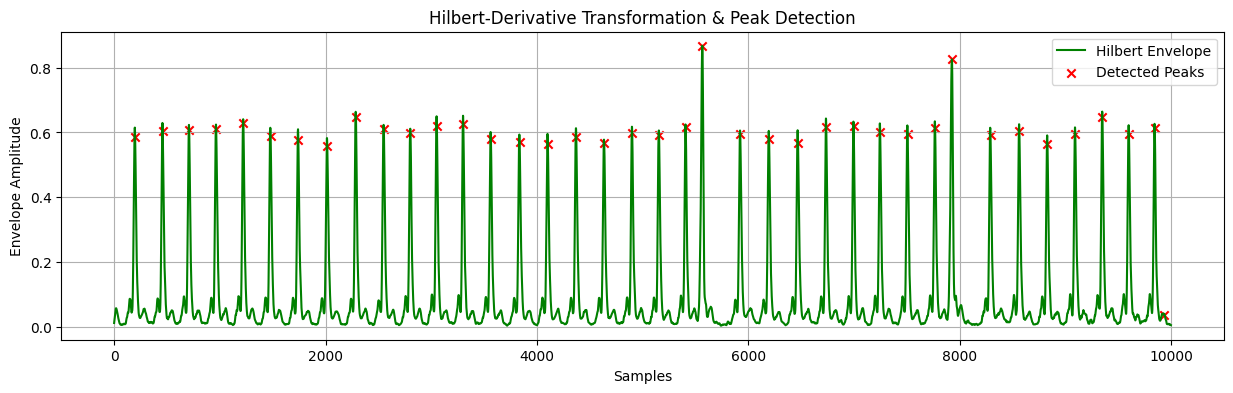

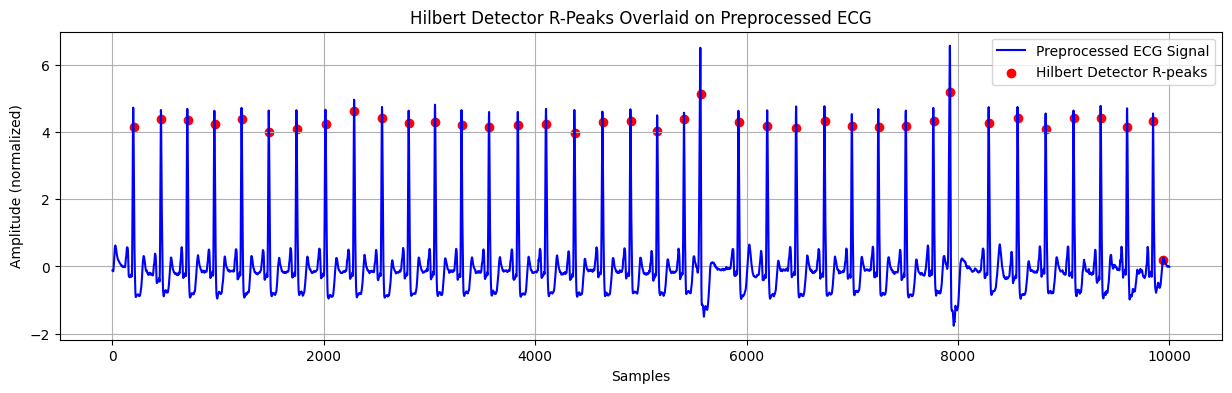

In [36]:
def detect_r_peaks_derivative_hilbert(ecg_signal, fs, ma_window_sec=0.05):
    diff_signal = np.diff(ecg_signal, prepend=ecg_signal[0])
    analytic_signal = hilbert(diff_signal)
    envelope = np.abs(analytic_signal)
    window_size = max(int(ma_window_sec * fs), 1)
    smoothed_envelope = np.convolve(envelope, np.ones(window_size) / window_size, mode='same')

    # Adaptive peak detection with refinement
    peaks = sliding_window_peak_detection_adaptive(smoothed_envelope, fs, window_sec=5,
                                                   init_threshold_ratio=0.2, min_distance_sec=0.2)
    refined_peaks = [refine_peak(ecg_signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), smoothed_envelope

# Detect using Hilbert–derivative method
peaks_hilbert, smoothed_env = detect_r_peaks_derivative_hilbert(preprocessed_signal, fs)
print(f"Hilbert-derivative detector found {len(peaks_hilbert)} peaks.")

# Plot Hilbert transformation and overlay peaks on both envelope and original ECG
plt.figure(figsize=(15, 4))
plt.plot(smoothed_env, color='green', label='Hilbert Envelope')
plt.scatter(peaks_hilbert, smoothed_env[peaks_hilbert], color='red', marker='x', label='Detected Peaks')
plt.title('Hilbert-Derivative Transformation & Peak Detection')
plt.xlabel('Samples')
plt.ylabel('Envelope Amplitude')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(preprocessed_signal, color='blue', label='Preprocessed ECG Signal')
plt.scatter(peaks_hilbert, preprocessed_signal[peaks_hilbert], color='red', marker='o', label='Hilbert Detector R-peaks')
plt.title('Hilbert Detector R-Peaks Overlaid on Preprocessed ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude (normalized)')
plt.legend()
plt.grid(True)
plt.show()

Pan-Tompkins detector found 38 peaks.


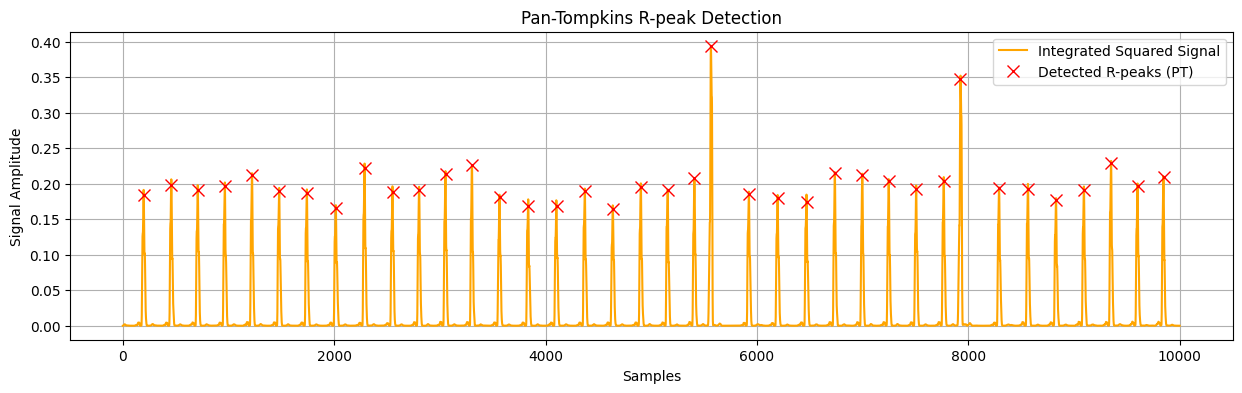

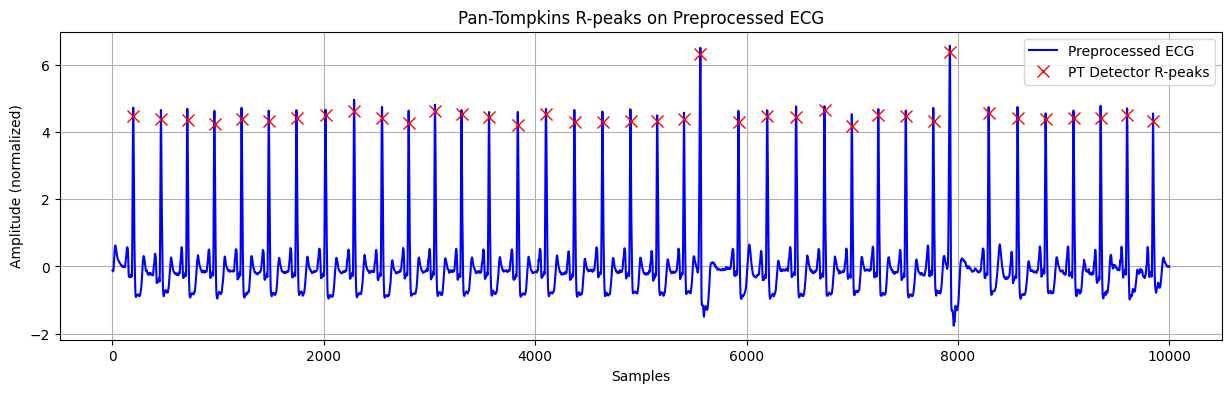

In [37]:
def detect_r_peaks_pantompkins(ecg_signal, fs, ma_window_sec=0.05, threshold_ratio=0.1, min_distance_sec=0.2):
    # Step 1: Differentiate
    diff_signal = np.diff(ecg_signal, prepend=ecg_signal[0])
    # Step 2: Square the differentiated signal
    squared_signal = diff_signal ** 2
    # Step 3: Moving window integration
    window_size = int(ma_window_sec * fs)
    if window_size < 1:
        window_size = 1
    kernel = np.ones(window_size) / window_size
    integrated_signal = np.convolve(squared_signal, kernel, mode='same')
    # Step 4: Adaptive thresholding based on a fraction of the maximum
    threshold = threshold_ratio * np.max(integrated_signal)
    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(integrated_signal, height=threshold, distance=min_distance)
    refined_peaks = [refine_peak(ecg_signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), integrated_signal

# Test Pan-Tompkins detector:
peaks_pt, integrated_signal = detect_r_peaks_pantompkins(preprocessed_signal, fs)
print(f"Pan-Tompkins detector found {len(peaks_pt)} peaks.")

# Plot the integrated signal and detected peaks for Pan-Tompkins
plt.figure(figsize=(15, 4))
plt.plot(integrated_signal, label='Integrated Squared Signal', color='orange')
plt.plot(peaks_pt, integrated_signal[peaks_pt], 'rx', markersize=8, label='Detected R-peaks (PT)')
plt.title("Pan-Tompkins R-peak Detection")
plt.xlabel("Samples")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Overlay PT detector peaks on preprocessed ECG
plt.figure(figsize=(15, 4))
plt.plot(preprocessed_signal, label="Preprocessed ECG", color="blue")
plt.plot(peaks_pt, preprocessed_signal[peaks_pt], "rx", markersize=8, label="PT Detector R-peaks")
plt.title("Pan-Tompkins R-peaks on Preprocessed ECG")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid(True)
plt.show()


Wavelet-SWT detector found 38 peaks.


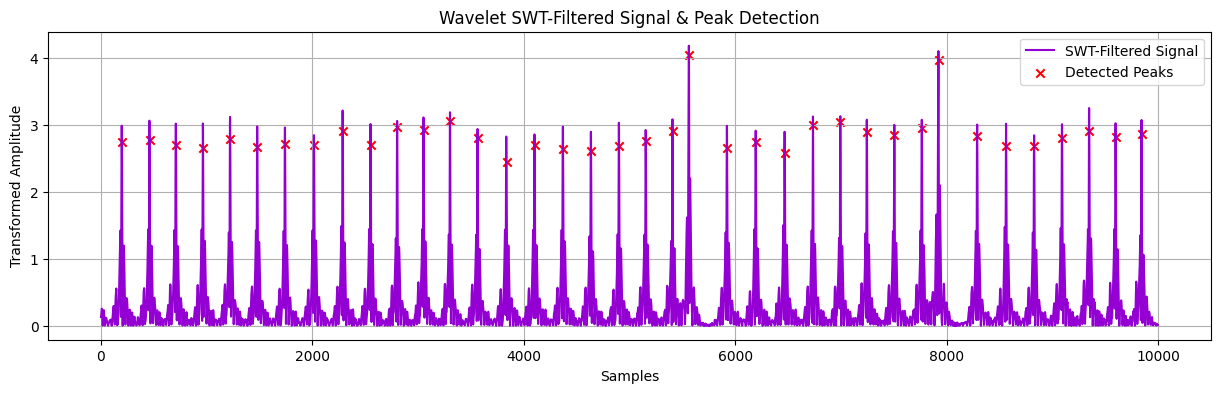

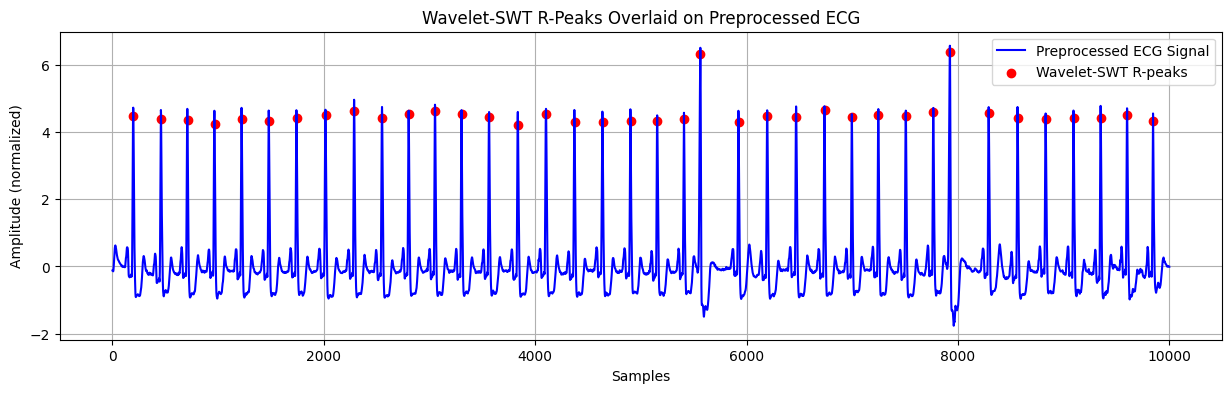

In [38]:
def detect_r_peaks_wavelet_swt(ecg_signal, fs, threshold_ratio=0.25, min_distance_sec=0.25):
    """
    Detect R-peaks using Stationary Wavelet Transform (SWT) based filtering.
    """
    N = 240
    padded_signal = np.pad(ecg_signal, (0, N), 'constant')
    swt_coeffs = pywt.swt(padded_signal, 'sym6', level=6)

    processed_coeffs = []
    for i, (cA, cD) in enumerate(swt_coeffs):
        if i + 1 in [2, 3, 4, 5, 6, 7]:
            processed_coeffs.append((np.zeros_like(cA), cD))
        else:
            processed_coeffs.append((np.zeros_like(cA), np.zeros_like(cD)))

    reconstructed = pywt.iswt(processed_coeffs, 'sym6')[:len(ecg_signal)]
    abs_signal = np.abs(reconstructed)
    min_distance = int(min_distance_sec * fs)

    # Peak detection
    peaks, _ = find_peaks(abs_signal, height=threshold_ratio * np.max(abs_signal), distance=min_distance)
    refined_peaks = [refine_peak(ecg_signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), abs_signal

# Detect using Wavelet-SWT method
peaks_swt, transformed_swt = detect_r_peaks_wavelet_swt(preprocessed_signal, fs)
print(f"Wavelet-SWT detector found {len(peaks_swt)} peaks.")

# Plot SWT transformation and detected peaks
plt.figure(figsize=(15, 4))
plt.plot(transformed_swt, color='darkviolet', label='SWT-Filtered Signal')
plt.scatter(peaks_swt, transformed_swt[peaks_swt], color='red', marker='x', label='Detected Peaks')
plt.title('Wavelet SWT-Filtered Signal & Peak Detection')
plt.xlabel('Samples')
plt.ylabel('Transformed Amplitude')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(preprocessed_signal, color='blue', label='Preprocessed ECG Signal')
plt.scatter(peaks_swt, preprocessed_signal[peaks_swt], color='red', marker='o', label='Wavelet-SWT R-peaks')
plt.title('Wavelet-SWT R-Peaks Overlaid on Preprocessed ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude (normalized)')
plt.legend()
plt.grid(True)
plt.show()


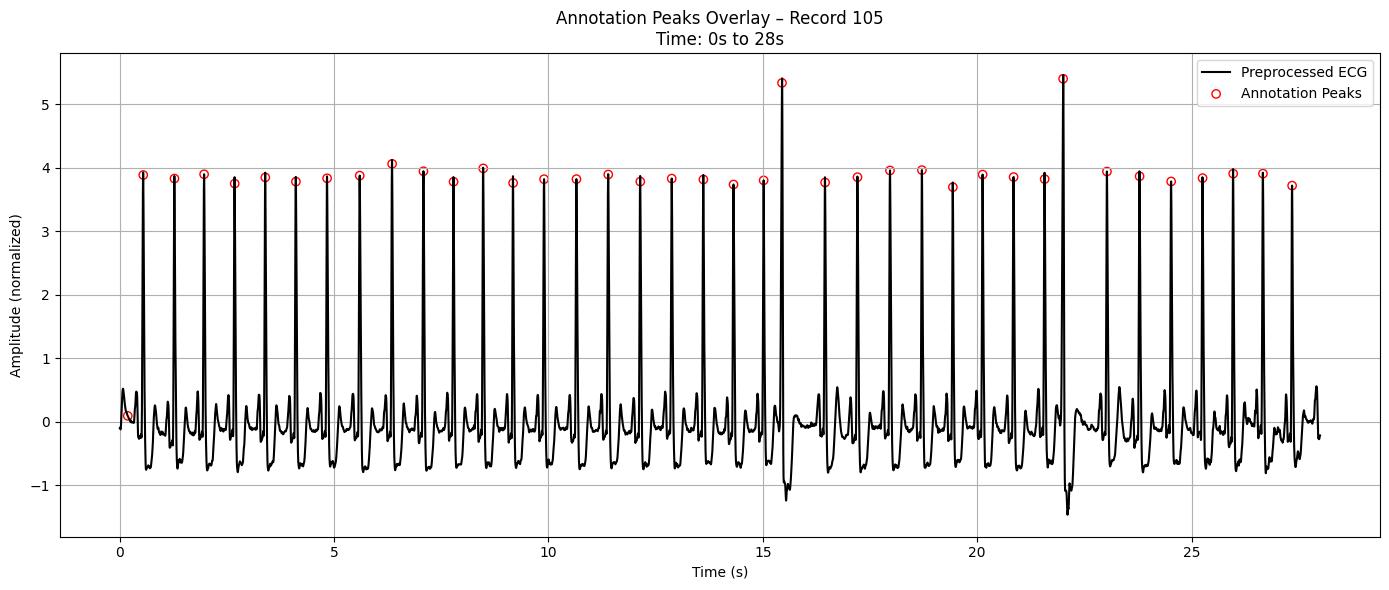

In [39]:
def plot_annotations_only(record_name, data_dir='mit-bih-arrhythmia-database-1.0.0',
                          start_time_sec=50, duration_sec=10):
    record_path = os.path.join(data_dir, record_name)
    record = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, extension='atr')
    ann_samples = np.array(ann.sample)

    signal = record.p_signal[:, 0]
    fs = record.fs
    preprocessed = preprocess_ecg(signal, fs)

    start_idx = int(start_time_sec * fs)
    end_idx = int((start_time_sec + duration_sec) * fs)
    time_axis = np.arange(start_idx, end_idx) / fs
    window_signal = preprocessed[start_idx:end_idx]

    ann_win = [p for p in ann_samples if start_idx <= p < end_idx]

    plt.figure(figsize=(14, 6))
    plt.plot(time_axis, window_signal, label="Preprocessed ECG", color='black')
    plt.scatter(np.array(ann_win)/fs, preprocessed[ann_win],
                color='red', marker='o', facecolors='none', edgecolors='red', label='Annotation Peaks')

    plt.title(f"Annotation Peaks Overlay – Record {record_name}\nTime: {start_time_sec}s to {start_time_sec+duration_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example: Plot annotations only for record "228" in a 10-second window starting at 50 seconds.
plot_annotations_only("105", start_time_sec=0, duration_sec=28)


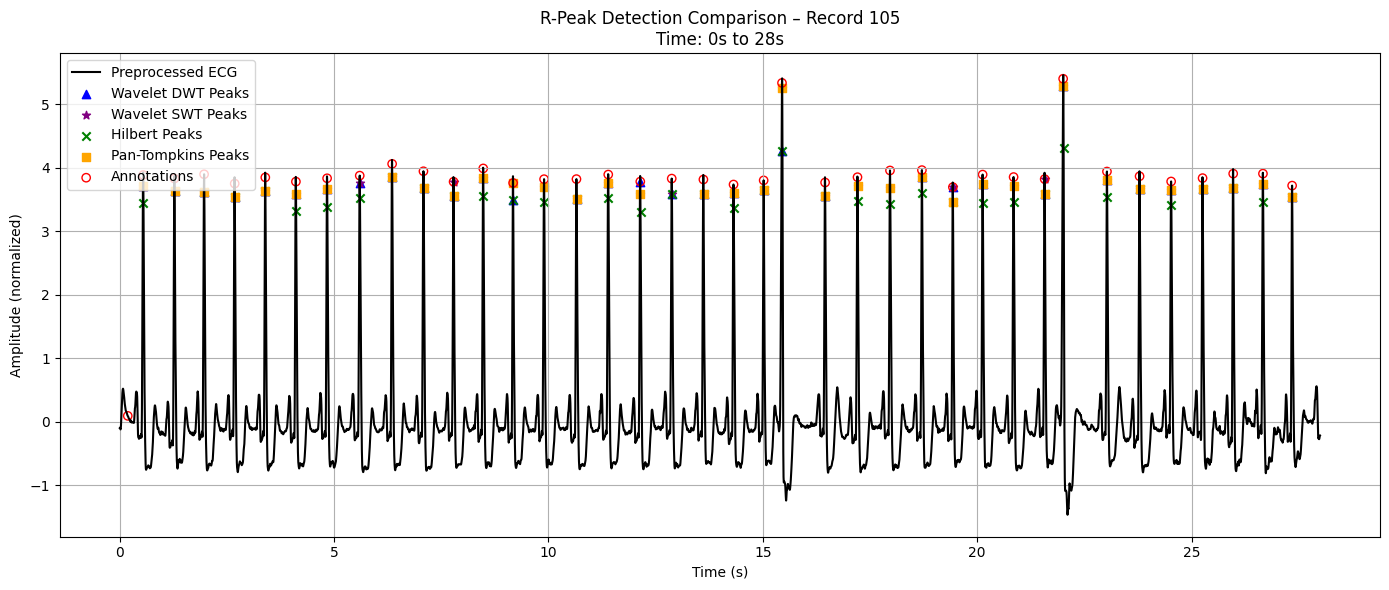

In [40]:
def plot_all_detection_methods(record_name, data_dir='mit-bih-arrhythmia-database-1.0.0',
                               start_time_sec=50, duration_sec=10):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import wfdb

    # Load record and annotations
    record_path = os.path.join(data_dir, record_name)
    record = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, extension='atr')
    ann_samples = np.array(ann.sample)

    # Preprocess signal
    signal = record.p_signal[:, 0]  # using MLII
    fs = record.fs
    preprocessed = preprocess_ecg(signal, fs)

    # Define time window (in samples)
    start_idx = int(start_time_sec * fs)
    end_idx = int((start_time_sec + duration_sec) * fs)
    time_axis = np.arange(start_idx, end_idx) / fs
    window_signal = preprocessed[start_idx:end_idx]

    # Detect peaks by each method over the entire signal
    peaks_wavelet, _ = detect_r_peaks_wavelet(preprocessed, fs, wavelet='sym4', total_level=5, detail_level=4,
                                              threshold_ratio=0.28, ma_window_sec=0.08, exp_factor=2.6, window_sec=5)

    peaks_wavelet_swt, _ = detect_r_peaks_wavelet_swt(preprocessed, fs)

    peaks_hilbert, _ = detect_r_peaks_derivative_hilbert(preprocessed, fs, ma_window_sec=0.05)

    peaks_pt, _ = detect_r_peaks_pantompkins(preprocessed, fs, ma_window_sec=0.05, threshold_ratio=0.1, min_distance_sec=0.2)

    # Get peaks that fall within the selected window
    peaks_wavelet_win = [p for p in peaks_wavelet if start_idx <= p < end_idx]
    peaks_wavelet_swt_win = [p for p in peaks_wavelet_swt if start_idx <= p < end_idx]
    peaks_hilbert_win = [p for p in peaks_hilbert if start_idx <= p < end_idx]
    peaks_pt_win = [p for p in peaks_pt if start_idx <= p < end_idx]
    ann_win = [p for p in ann_samples if start_idx <= p < end_idx]

    # Plot all detected peaks with annotations
    plt.figure(figsize=(14, 6))
    plt.plot(time_axis, window_signal, label="Preprocessed ECG", color='black')
    plt.scatter(np.array(peaks_wavelet_win) / fs, preprocessed[peaks_wavelet_win],
                color='blue', marker='^', label='Wavelet DWT Peaks')
    plt.scatter(np.array(peaks_wavelet_swt_win) / fs, preprocessed[peaks_wavelet_swt_win],
                color='purple', marker='*', label='Wavelet SWT Peaks')
    plt.scatter(np.array(peaks_hilbert_win) / fs, preprocessed[peaks_hilbert_win],
                color='green', marker='x', label='Hilbert Peaks')
    plt.scatter(np.array(peaks_pt_win) / fs, preprocessed[peaks_pt_win],
                color='orange', marker='s', label='Pan-Tompkins Peaks')
    plt.scatter(np.array(ann_win) / fs, preprocessed[ann_win],
                color='red', marker='o', facecolors='none', edgecolors='red', label='Annotations')

    plt.title(f"R-Peak Detection Comparison – Record {record_name}\nTime: {start_time_sec}s to {start_time_sec+duration_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example: Plot for record "228" between 0s and 28s
plot_all_detection_methods("105", start_time_sec=0, duration_sec=28)


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# --- Provided: PQRST detection function ---
def detect_pqrst(ecg_signal, fs, r_peaks):
    """
    Detect P, Q, S, T waves based on R-peak anchors.
    """
    p_peaks, q_peaks, s_peaks, t_peaks = [], [], [], []
    for r_loc in r_peaks:
        # P wave (200ms to 70ms before R)
        p_start = int(r_loc - 0.2 * fs)
        p_end = int(r_loc - 0.07 * fs)
        if p_start >= 0 and p_end < len(ecg_signal):
            p_window = ecg_signal[p_start:p_end]
            if len(p_window) > 0:
                p_peak = p_start + np.argmax(p_window)
                p_peaks.append(p_peak)
        # Q wave (70ms before R until R)
        q_start = int(r_loc - 0.07 * fs)
        q_end = r_loc
        if q_start >= 0 and q_end < len(ecg_signal):
            q_window = ecg_signal[q_start:q_end]
            if len(q_window) > 0:
                q_peak = q_start + np.argmin(q_window)
                q_peaks.append(q_peak)
        # S wave (R to 70ms after R)
        s_start = r_loc
        s_end = int(r_loc + 0.07 * fs)
        if s_start >= 0 and s_end < len(ecg_signal):
            s_window = ecg_signal[s_start:s_end]
            if len(s_window) > 0:
                s_peak = s_start + np.argmin(s_window)
                s_peaks.append(s_peak)
        # T wave (80ms to 400ms after R)
        t_start = int(r_loc + 0.08 * fs)
        t_end = int(r_loc + 0.4 * fs)
        if t_start >= 0 and t_end < len(ecg_signal):
            t_window = ecg_signal[t_start:t_end]
            if len(t_window) > 0:
                t_peak = t_start + np.argmax(t_window)
                t_peaks.append(t_peak)
    return {'P': np.array(p_peaks), 'Q': np.array(q_peaks),
            'R': np.array(r_peaks), 'S': np.array(s_peaks),
            'T': np.array(t_peaks)}

# --- Functions for visualization of PQRST results ---

def plot_pqrst_overlay(ecg_signal, fs, pqrst_dict, method_name, zoom_start, zoom_end):
    time_axis = np.arange(zoom_start, zoom_end) / fs
    window_signal = ecg_signal[zoom_start:zoom_end]

    plt.figure(figsize=(14, 5))
    plt.plot(time_axis, window_signal, label="ECG Signal", color='black')

    colors = {'P': 'magenta', 'Q': 'cyan', 'R': 'red', 'S': 'green', 'T': 'orange'}
    markers = {'P': 'o', 'Q': 'o', 'R': 'o', 'S': 'o', 'T': 'o'}

    for wave in ['P', 'Q', 'R', 'S', 'T']:
        points = pqrst_dict[wave]
        mask = (points >= zoom_start) & (points < zoom_end)
        if np.sum(mask) > 0:
            plt.scatter(points[mask] / fs, ecg_signal[points[mask]],
                        color=colors[wave], marker=markers[wave],
                        label=f'{wave} peaks')

    plt.title(f"PQRST Overlay ({method_name})\nTime: {zoom_start/fs:.2f}s to {zoom_end/fs:.2f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_zoomed_annotations(ecg_signal, fs, ann_samples, zoom_start, zoom_end):
    time_axis = np.arange(zoom_start, zoom_end) / fs
    window_signal = ecg_signal[zoom_start:zoom_end]
    ann_window = [p for p in ann_samples if zoom_start <= p < zoom_end]

    plt.figure(figsize=(14, 5))
    plt.plot(time_axis, window_signal, label="ECG Signal", color='blue')
    plt.scatter(np.array(ann_window)/fs, ecg_signal[ann_window],
                color='red', marker='o', facecolors='none', edgecolors='red',
                label='Annotations')
    plt.title(f"Annotations Only\nTime: {zoom_start/fs:.2f}s to {zoom_end/fs:.2f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_single_beat(ecg_signal, fs, pqrst_dict, beat_idx):
    p = pqrst_dict['P'][beat_idx]
    q = pqrst_dict['Q'][beat_idx]
    r = pqrst_dict['R'][beat_idx]
    s = pqrst_dict['S'][beat_idx]
    t = pqrst_dict['T'][beat_idx]
    window = int(0.5 * fs)
    start = max(0, r - window)
    end = min(len(ecg_signal), r + window)

    plt.figure(figsize=(14, 4))
    plt.plot(ecg_signal[start:end], label='ECG Beat', color='blue')
    plt.axvline(x=p - start, color='magenta', linestyle='--', label='P')
    plt.axvline(x=q - start, color='cyan', linestyle='--', label='Q')
    plt.axvline(x=r - start, color='red', linestyle='--', label='R')
    plt.axvline(x=s - start, color='green', linestyle='--', label='S')
    plt.axvline(x=t - start, color='orange', linestyle='--', label='T')
    plt.title(f"Single ECG Beat with Fiducial Markers (Beat index {beat_idx})")
    plt.xlabel("Samples (windowed)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Use the existing detection results to produce PQRST maps for each method ---
pqrst_wavelet = detect_pqrst(preprocessed_signal, fs, peaks_wavelet)
pqrst_hilbert = detect_pqrst(preprocessed_signal, fs, peaks_hilbert)
pqrst_pt = detect_pqrst(preprocessed_signal, fs, peaks_pt)
pqrst_wavelet_swt = detect_pqrst(preprocessed_signal, fs, peaks_wavelet_swt)

# --- Visualization: Overlay PQRST points for each detector on a zoomed ECG window ---
zoom_start = 3200
zoom_end = 4000

plot_pqrst_overlay(preprocessed_signal, fs, pqrst_wavelet, "Wavelet-Based", zoom_start, zoom_end)
plot_pqrst_overlay(preprocessed_signal, fs, pqrst_hilbert, "Hilbert-Derivative", zoom_start, zoom_end)
plot_pqrst_overlay(preprocessed_signal, fs, pqrst_pt, "Pan-Tompkins", zoom_start, zoom_end)
plot_pqrst_overlay(preprocessed_signal, fs, pqrst_wavelet_swt, "Wavelet-SWT", zoom_start, zoom_end)

# --- Visualization: Plot a small window showing just annotation peaks ---
ann = wfdb.rdann('mit-bih-arrhythmia-database-1.0.0/228', extension='atr')
ann_samples = np.array(ann.sample)
plot_zoomed_annotations(preprocessed_signal, fs, ann_samples, zoom_start, zoom_end)

# --- Visualization: Plot a single beat (choose a beat index from a chosen method)
beat_idx = 10
plot_single_beat(preprocessed_signal, fs, pqrst_pt, beat_idx)


NameError: name 'peaks_wavelet_swt' is not defined

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# --- Preprocessing Functions ---
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def notch_filter(data, freq, fs, Q=30):
    nyq = 0.5 * fs
    freq_norm = freq / nyq
    b, a = iirnotch(freq_norm, Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    filtered_hp = filtfilt(b_hp, a_hp, signal)
    filtered_notch = notch_filter(filtered_hp, freq=50, fs=fs)
    b_lp, a_lp = butter_lowpass(40.0, fs)
    filtered_signal = filtfilt(b_lp, a_lp, filtered_notch)
    preprocessed = (filtered_signal - np.mean(filtered_signal)) / np.std(filtered_signal)
    return preprocessed

# --- Peak Refinement ---
def refine_peak(signal, index, search_window=5):
    start = max(index - search_window, 0)
    end = min(index + search_window + 1, len(signal))
    segment = signal[start:end]
    # If median is negative, choose the local minimum (inverted QRS), otherwise maximum.
    if np.median(segment) < 0:
        local_index = np.argmin(segment)
    else:
        local_index = np.argmax(segment)
    return start + local_index

# --- Adaptive Peak Detection (common helper) ---
def sliding_window_peak_detection_adaptive(signal, fs, window_sec=5, init_threshold_ratio=0.28, min_distance_sec=0.2):
    window_size = int(window_sec * fs)
    min_distance = int(min_distance_sec * fs)
    N = len(signal)
    detected_peaks = []
    step = window_size // 2
    acceptable_min = 3
    acceptable_max = 10
    max_iter = 10
    update_factor = 0.05

    for start in range(0, N, step):
        end = min(start + window_size, N)
        window_data = signal[start:end]
        ratio = init_threshold_ratio
        iteration = 0
        peaks = []
        while iteration < max_iter:
            local_thresh = ratio * np.max(window_data)
            peaks, _ = find_peaks(window_data, height=local_thresh, distance=min_distance)
            if acceptable_min <= len(peaks) <= acceptable_max:
                break
            if len(peaks) > acceptable_max:
                ratio *= (1 + update_factor)
            elif len(peaks) < acceptable_min:
                ratio *= (1 - update_factor)
            iteration += 1
        refined_peaks = [refine_peak(signal, p + start, search_window=5) for p in peaks]
        detected_peaks.extend(refined_peaks)
    return np.unique(detected_peaks)

# --- Wavelet-Based Detector ---
def detect_r_peaks_wavelet(ecg_signal, fs, wavelet='sym4', total_level=5, detail_level=4,
                             threshold_ratio=0.3, ma_window_sec=0.04, exp_factor=2.6, window_sec=3):
    # Wavelet decomposition:
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=total_level)
    for i in range(len(coeffs)):
        if i != detail_level:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail_signal = pywt.waverec(coeffs, wavelet)
    detail_pow = np.abs(detail_signal) ** exp_factor
    window_size = int(ma_window_sec * fs)
    window_size = max(window_size, 1)
    kernel = np.ones(window_size) / window_size
    filtered_detail = np.convolve(detail_pow, kernel, mode='same')
    peaks = sliding_window_peak_detection_adaptive(filtered_detail, fs, window_sec=window_sec,
                                                   init_threshold_ratio=threshold_ratio, min_distance_sec=0.2)
    refined_peaks = [refine_peak(ecg_signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), filtered_detail

# --- Evaluation Function ---
def evaluate_detections(candidate_peaks, ann_samples, tolerance=50):
    candidate_peaks = np.array(candidate_peaks)
    ann_samples = np.array(ann_samples)
    TP = 0
    matched = []
    for p in candidate_peaks:
        diff = np.abs(ann_samples - p)
        if np.min(diff) <= tolerance:
            TP += 1
            matched.append(np.argmin(diff))
    FP = len(candidate_peaks) - TP
    FN = len(ann_samples) - len(np.unique(matched))
    sensitivity = TP / (TP + FN + 1e-6)
    PPV = TP / (TP + FP + 1e-6)
    return sensitivity, PPV, TP, FP, FN

def plot_detection_window(ecg_signal, fs, detected_peaks, ann_samples, start_time_sec, duration_sec, title_suffix=""):
    start_idx = int(start_time_sec * fs)
    end_idx = int((start_time_sec + duration_sec) * fs)
    time_axis = np.arange(start_idx, end_idx) / fs
    window_signal = ecg_signal[start_idx:end_idx]
    detected_window = [p for p in detected_peaks if start_idx <= p < end_idx]
    ann_window = [p for p in ann_samples if start_idx <= p < end_idx]

    plt.figure(figsize=(15, 5))
    plt.plot(time_axis, window_signal, label='Preprocessed ECG', color='black')
    plt.scatter(np.array(detected_window)/fs, ecg_signal[detected_window], color='red', marker='x', s=100, label='Detected R-peaks')
    plt.scatter(np.array(ann_window)/fs, ecg_signal[ann_window], color='blue', marker='o', facecolors='none', edgecolors='blue', s=100, label='Annotation R-peaks')
    plt.title(f"Wavelet-Based Detection {title_suffix}\nTime: {start_time_sec}s to {start_time_sec+duration_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------- Main Evaluation for Wavelet Detector ----------
record_name = "108"
data_dir = 'mit-bih-arrhythmia-database-1.0.0'
record_path = os.path.join(data_dir, record_name)
record = wfdb.rdrecord(record_path)
fs = record.fs
signal = record.p_signal[:, 0]
ann = wfdb.rdann(record_path, extension='atr')
ann_samples = np.array(ann.sample)

preprocessed = preprocess_ecg(signal, fs)
detected_peaks_wavelet, filtered_detail = detect_r_peaks_wavelet(preprocessed, fs)
tolerance = 50

sens_w, PPV_w, TP_w, FP_w, FN_w = evaluate_detections(detected_peaks_wavelet, ann_samples, tolerance)
print("Wavelet-DWT Based Detector Evaluation:")
print(f"  Sensitivity: {sens_w:.3f}, PPV: {PPV_w:.3f}, TP: {TP_w}, FP: {FP_w}, FN: {FN_w}")

plot_detection_window(preprocessed, fs, detected_peaks_wavelet, ann_samples,
                        start_time_sec=0, duration_sec=28, title_suffix="(Wavelet)")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# =================== 1. Preprocessing Functions ===================

def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def notch_filter(data, freq, fs, Q=30):
    nyq = 0.5 * fs
    freq_norm = freq / nyq
    b, a = iirnotch(freq_norm, Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    filtered_hp = filtfilt(b_hp, a_hp, signal)
    filtered_notch = notch_filter(filtered_hp, freq=50, fs=fs)
    b_lp, a_lp = butter_lowpass(40.0, fs)
    filtered_signal = filtfilt(b_lp, a_lp, filtered_notch)
    preprocessed = (filtered_signal - np.mean(filtered_signal)) / np.std(filtered_signal)
    return preprocessed

# =================== 2. Pan-Tompkins R-Peak Detection ===================

def refine_peak(signal, index, search_window=5):
    start = max(index - search_window, 0)
    end = min(index + search_window + 1, len(signal))
    window = signal[start:end]
    if np.median(window) < 0:
        peak_local = np.argmin(window)
    else:
        peak_local = np.argmax(window)
    return start + peak_local

def detect_r_peaks_pantompkins(signal, fs, ma_window_sec=0.04, threshold_ratio=0.08, min_distance_sec=0.2):
    diff_signal = np.diff(signal, prepend=signal[0])
    squared_signal = diff_signal ** 2
    window_size = max(int(ma_window_sec * fs), 1)
    kernel = np.ones(window_size) / window_size
    integrated_signal = np.convolve(squared_signal, kernel, mode='same')
    threshold = threshold_ratio * np.max(integrated_signal)
    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(integrated_signal, height=threshold, distance=min_distance)
    refined_peaks = [refine_peak(signal, p, search_window=5) for p in peaks]
    return np.array(refined_peaks), integrated_signal

# =================== 3. Evaluation Function ===================

def evaluate_detections(candidate_peaks, ann_samples, tolerance=80):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    sensitivity = TP / (TP + FN + 1e-6)
    PPV = TP / (TP + FP + 1e-6)
    return sensitivity, PPV, TP, FP, FN

# =================== 4. Plotting Function ===================

def plot_detection_window(ecg_signal, fs, detected_peaks, ann_samples, start_time_sec, duration_sec, title_suffix=""):
    start_idx = int(start_time_sec * fs)
    end_idx = int((start_time_sec + duration_sec) * fs)
    time_axis = np.arange(start_idx, end_idx) / fs
    window_signal = ecg_signal[start_idx:end_idx]
    detected_window = [p for p in detected_peaks if start_idx <= p < end_idx]
    ann_window = [p for p in ann_samples if start_idx <= p < end_idx]

    plt.figure(figsize=(15, 5))
    plt.plot(time_axis, window_signal, label='Preprocessed ECG', color='black')
    plt.scatter(np.array(detected_window)/fs, ecg_signal[detected_window], color='red', marker='x', s=100, label='Detected R-peaks')
    plt.scatter(np.array(ann_window)/fs, ecg_signal[ann_window], color='blue', marker='o', facecolors='none', edgecolors='blue', s=100, label='Annotation R-peaks')
    plt.title(f"Pan-Tompkins Detection {title_suffix}\nTime: {start_time_sec}s to {start_time_sec + duration_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =================== 5. Main Execution ===================

data_dir = './mit-bih-arrhythmia-database-1.0.0'
record_name = '108'
record_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(record_path)
fs = record.fs
signal_raw = record.p_signal[:, 0]

ann = wfdb.rdann(record_path, extension='atr')
ann_samples = np.array(ann.sample)
ann_symbols = np.array(ann.symbol)
real_peaks = ann_samples[[i for i, s in enumerate(ann_symbols) if s in ['N', 'V', 'A']]]

signal = preprocess_ecg(signal_raw, fs)

peaks_pt, _ = detect_r_peaks_pantompkins(signal, fs)

sens, ppv, tp, fp, fn = evaluate_detections(peaks_pt, real_peaks)
print("Pan-Tompkins R-Peak Detector Evaluation:")
print(f"  Sensitivity: {sens:.3f}")
print(f"  PPV: {ppv:.3f}")
print(f"  TP: {tp}, FP: {fp}, FN: {fn}")

plot_detection_window(signal, fs, peaks_pt, real_peaks, start_time_sec=0, duration_sec=28, title_suffix="(Pan-Tompkins)")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# =================== 1. Preprocessing Functions ===================

def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def notch_filter(data, freq, fs, Q=30):
    nyq = 0.5 * fs
    freq_norm = freq / nyq
    b, a = iirnotch(freq_norm, Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    filtered_hp = filtfilt(b_hp, a_hp, signal)
    filtered_notch = notch_filter(filtered_hp, freq=50, fs=fs)
    b_lp, a_lp = butter_lowpass(40.0, fs)
    filtered_signal = filtfilt(b_lp, a_lp, filtered_notch)
    return (filtered_signal - np.mean(filtered_signal)) / np.std(filtered_signal)

# =================== 2. Wavelet-SWT R-Peak Detection ===================

def detect_r_peaks_wavelet_swt(signal, fs, threshold=0.25, min_distance_sec=0.25):
    N = 240
    padded_signal = np.pad(signal, (0, N), 'constant')
    swt_coeffs = pywt.swt(padded_signal, 'sym6', level=6)

    processed_coeffs = []
    for i, (cA, cD) in enumerate(swt_coeffs):
        if i + 1 in [2, 3, 4, 5, 6, 7]:
            processed_coeffs.append((np.zeros_like(cA), cD))
        else:
            processed_coeffs.append((np.zeros_like(cA), np.zeros_like(cD)))

    filtered_signal = pywt.iswt(processed_coeffs, 'sym6')[:len(signal)]
    abs_signal = np.abs(filtered_signal)

    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(abs_signal, height=threshold * np.max(abs_signal), distance=min_distance)
    return peaks, filtered_signal

# =================== 3. Evaluation and Plotting ===================

def evaluate_detections(candidate_peaks, ann_samples, tolerance=80):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    sensitivity = TP / (TP + FN + 1e-6)
    PPV = TP / (TP + FP + 1e-6)
    return sensitivity, PPV, TP, FP, FN

def plot_detection_window(ecg_signal, fs, detected_peaks, ann_samples, start_time_sec, duration_sec, title_suffix=""):
    start_idx = int(start_time_sec * fs)
    end_idx = int((start_time_sec + duration_sec) * fs)
    time_axis = np.arange(start_idx, end_idx) / fs
    window_signal = ecg_signal[start_idx:end_idx]

    detected_window = [p for p in detected_peaks if start_idx <= p < end_idx]
    ann_window = [p for p in ann_samples if start_idx <= p < end_idx]

    plt.figure(figsize=(15, 5))
    plt.plot(time_axis, window_signal, label='Preprocessed ECG', color='black')
    plt.scatter(np.array(detected_window)/fs, ecg_signal[detected_window], color='red', marker='x', s=100, label='Detected R-peaks')
    plt.scatter(np.array(ann_window)/fs, ecg_signal[ann_window], color='blue', marker='o', facecolors='none', edgecolors='blue', s=100, label='Annotation R-peaks')
    plt.title(f"Wavelet-SWT Detection {title_suffix}\nTime: {start_time_sec}s to {start_time_sec + duration_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =================== 4. Main Execution ===================

record_name = '228'
data_dir = './mit-bih-arrhythmia-database-1.0.0'
record = wfdb.rdrecord(record_path)
signal = record.p_signal[:, 0]
fs = record.fs


# Preprocess
signal = preprocess_ecg(signal, fs)

# Load Annotations
ann = wfdb.rdann(record_path, 'atr')
ann_samples = np.array(ann.sample)
ann_symbols = np.array(ann.symbol)
real_peaks = ann_samples[[i for i, s in enumerate(ann_symbols) if s in ['N', 'V', 'A']]]

# Detect Peaks
peaks_wavelet_swt, _ = detect_r_peaks_wavelet_swt(signal, fs)

# Evaluate
sens, ppv, tp, fp, fn = evaluate_detections(peaks_wavelet_swt, real_peaks)
print(f"Wavelet-SWT R-Peak Detector Evaluation:")
print(f"  Sensitivity: {sens:.3f}")
print(f"  PPV: {ppv:.3f}")
print(f"  TP: {tp}, FP: {fp}, FN: {fn}")

# Plot
plot_detection_window(signal, fs, peaks_wavelet_swt, real_peaks, start_time_sec=0, duration_sec=28, title_suffix="(Wavelet-SWT)")


In [ ]:
import os
import numpy as np
import pandas as pd
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# --- Preprocessing ---
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='high', analog=False)

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='low', analog=False)

def notch_filter(data, freq, fs, Q=30):
    b, a = iirnotch(freq / (0.5 * fs), Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    signal = filtfilt(b_hp, a_hp, signal)
    signal = notch_filter(signal, 50, fs)
    b_lp, a_lp = butter_lowpass(40, fs)
    signal = filtfilt(b_lp, a_lp, signal)
    return (signal - np.mean(signal)) / np.std(signal)

# --- Detection ---
def refine_peak(signal, index, search_window=5):
    start, end = max(index - search_window, 0), min(index + search_window + 1, len(signal))
    window = signal[start:end]
    return start + (np.argmin(window) if np.median(window) < 0 else np.argmax(window))

def sliding_window_peak_detection_adaptive(signal, fs, window_sec=5, init_threshold_ratio=0.28, min_distance_sec=0.2):
    window_size = int(window_sec * fs)
    min_distance = int(min_distance_sec * fs)
    N = len(signal)
    detected_peaks = []
    step = window_size // 2
    acceptable_min, acceptable_max, max_iter = 3, 10, 10
    update_factor = 0.05

    for start in range(0, N, step):
        end = min(start + window_size, N)
        window_data = signal[start:end]
        ratio = init_threshold_ratio
        for _ in range(max_iter):
            local_thresh = ratio * np.max(window_data)
            peaks, _ = find_peaks(window_data, height=local_thresh, distance=min_distance)
            if acceptable_min <= len(peaks) <= acceptable_max:
                break
            ratio *= (1 + update_factor) if len(peaks) > acceptable_max else (1 - update_factor)
        refined = [refine_peak(signal, p + start) for p in peaks]
        detected_peaks.extend(refined)
    return np.unique(detected_peaks)

def detect_r_peaks_wavelet(ecg_signal, fs, wavelet='sym4', total_level=5, detail_level=4,
                            threshold_ratio=0.2, ma_window_sec=0.04, exp_factor=2.6, window_sec=3):
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=total_level)
    for i in range(len(coeffs)):
        if i != detail_level:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail_signal = pywt.waverec(coeffs, wavelet)
    detail_pow = np.abs(detail_signal) ** exp_factor
    window_size = max(int(ma_window_sec * fs), 1)
    smoothed = np.convolve(detail_pow, np.ones(window_size) / window_size, mode='same')
    peaks = sliding_window_peak_detection_adaptive(smoothed, fs, window_sec, threshold_ratio, 0.2)
    return np.array([refine_peak(ecg_signal, p) for p in peaks])

# --- Evaluation ---
def evaluate_detections(candidate_peaks, ann_samples, tolerance=50):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    SEN = 100 * TP / (TP + FN + 1e-6)
    PPV = 100 * TP / (TP + FP + 1e-6)
    ACC = 100 * TP / (TP + FN + FP + 1e-6)
    return TP + FN, TP, FN, FP, SEN, PPV, ACC

# --- Batch Evaluation ---
data_dir = './mit-bih-arrhythmia-database-1.0.0'
available_records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

results = []

for record_name in available_records:
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = preprocess_ecg(record.p_signal[:, 0], record.fs)
        ann = wfdb.rdann(os.path.join(data_dir, record_name), 'atr')
        ann_samples = np.array(ann.sample)

        peaks_wavelet = detect_r_peaks_wavelet(signal, record.fs)
        total_beats, TP, FN, FP, SEN, PPV, ACC = evaluate_detections(peaks_wavelet, ann_samples)

        results.append([record_name, total_beats, TP, FN, FP, SEN, PPV, ACC])
    except Exception as e:
        print(f"Error processing record {record_name}: {e}")

# Convert to DataFrame and calculate totals
columns = ['Record', 'Total Beats', 'TP', 'FN', 'FP', 'SEN (%)', '+P (%)', 'ACC (%)']
df = pd.DataFrame(results, columns=columns)
df.loc['Total'] = ['Total'] + df[columns[1:5]].sum().tolist() + [
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FP'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum() + df['FP'].sum())
]

# Pretty display using tabulate if available
try:
    from tabulate import tabulate
    print("\nWavelet DWT R-Peak Detection Accuracy Table:\n")
    print(tabulate(df, headers='keys', tablefmt='grid', showindex=False, floatfmt=".2f"))
except ImportError:
    print("\nWavelet DWT R-Peak Detection Accuracy Table:")
    print(df.to_string(index=False))

In [42]:
import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, hilbert

# --- Preprocessing ---
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='high', analog=False)

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='low', analog=False)

def notch_filter(data, freq, fs, Q=30):
    b, a = iirnotch(freq / (0.5 * fs), Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    signal = filtfilt(b_hp, a_hp, signal)
    signal = notch_filter(signal, 50, fs)
    b_lp, a_lp = butter_lowpass(40, fs)
    signal = filtfilt(b_lp, a_lp, signal)
    return (signal - np.mean(signal)) / np.std(signal)

# --- Detection ---
def refine_peak(signal, index, search_window=5):
    start, end = max(index - search_window, 0), min(index + search_window + 1, len(signal))
    window = signal[start:end]
    return start + (np.argmin(window) if np.median(window) < 0 else np.argmax(window))

def detect_r_peaks_hilbert(signal, fs, ma_window_sec=0.04, threshold_ratio=0.3, min_distance_sec=0.25):
    diff_signal = np.diff(signal, prepend=signal[0])
    envelope = np.abs(hilbert(diff_signal))
    window_size = max(int(ma_window_sec * fs), 1)
    smoothed_env = np.convolve(envelope, np.ones(window_size)/window_size, mode='same')
    threshold = threshold_ratio * np.max(smoothed_env)
    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(smoothed_env, height=threshold, distance=min_distance)
    return np.array([refine_peak(signal, p) for p in peaks])

# --- Evaluation ---
def evaluate_detections(candidate_peaks, ann_samples, tolerance=50):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    SEN = 100 * TP / (TP + FN + 1e-6)
    PPV = 100 * TP / (TP + FP + 1e-6)
    ACC = 100 * TP / (TP + FN + FP + 1e-6)
    return TP + FN, TP, FN, FP, SEN, PPV, ACC

# --- Batch Evaluation ---
data_dir = './mit-bih-arrhythmia-database-1.0.0'
available_records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

results = []

for record_name in available_records:
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = preprocess_ecg(record.p_signal[:, 0], record.fs)
        ann = wfdb.rdann(os.path.join(data_dir, record_name), 'atr')
        ann_samples = np.array(ann.sample)

        peaks_hilbert = detect_r_peaks_hilbert(signal, record.fs)
        total_beats, TP, FN, FP, SEN, PPV, ACC = evaluate_detections(peaks_hilbert, ann_samples)

        results.append([record_name, total_beats, TP, FN, FP, SEN, PPV, ACC])
    except Exception as e:
        print(f"Error processing record {record_name}: {e}")

# Convert to DataFrame and calculate totals
columns = ['Record', 'Total Beats', 'TP', 'FN', 'FP', 'SEN (%)', '+P (%)', 'ACC (%)']
df = pd.DataFrame(results, columns=columns)
df.loc['Total'] = ['Total'] + df[columns[1:5]].sum().tolist() + [
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FP'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum() + df['FP'].sum())
]

# Pretty display using tabulate if available
try:
    from tabulate import tabulate
    print("\nHilbert R-Peak Detection Accuracy Table:\n")
    print(tabulate(df, headers='keys', tablefmt='grid', showindex=False, floatfmt=".2f"))
except ImportError:
    print("\nHilbert R-Peak Detection Accuracy Table:")
    print(df.to_string(index=False))


Hilbert R-Peak Detection Accuracy Table:
Record  Total Beats     TP   FN  FP   SEN (%)     +P (%)   ACC (%)
   100         2274   2273    1   0 99.956025 100.000000 99.956025
   101         1874   1867    7   3 99.626467  99.839572 99.467235
   102         2192   2187    5   0 99.771898 100.000000 99.771898
   103         2091   2083    8   0 99.617408 100.000000 99.617408
   104         2311   2189  122  29 94.720900  98.692516 93.547009
   105         2691   2555  136  20 94.946117  99.223301 94.245666
   106         2098   1808  290   1 86.177312  99.944721 86.136255
   107         2140   2135    5   0 99.766355 100.000000 99.766355
   108         1824   1487  337  15 81.524123  99.001331 80.859163
   109         2535   2448   87   0 96.568047 100.000000 96.568047
   111         2133   2121   12   1 99.437412  99.952875 99.390815
   112         2550   2539   11   2 99.568627  99.921291 99.490596
   113         1796   1795    1   0 99.944321 100.000000 99.944321
   114         1890 

In [24]:
import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# --- Preprocessing ---
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='high', analog=False)

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='low', analog=False)

def notch_filter(data, freq, fs, Q=30):
    b, a = iirnotch(freq / (0.5 * fs), Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    signal = filtfilt(b_hp, a_hp, signal)
    signal = notch_filter(signal, 50, fs)
    b_lp, a_lp = butter_lowpass(40, fs)
    signal = filtfilt(b_lp, a_lp, signal)
    return (signal - np.mean(signal)) / np.std(signal)

# --- Detection ---
def refine_peak(signal, index, search_window=5):
    start, end = max(index - search_window, 0), min(index + search_window + 1, len(signal))
    window = signal[start:end]
    return start + (np.argmin(window) if np.median(window) < 0 else np.argmax(window))

def detect_r_peaks_pantompkins(signal, fs, ma_window_sec=0.04, threshold_ratio=0.08, min_distance_sec=0.2):
    diff_signal = np.diff(signal, prepend=signal[0])
    squared_signal = diff_signal ** 2
    window_size = max(int(ma_window_sec * fs), 1)
    integrated_signal = np.convolve(squared_signal, np.ones(window_size) / window_size, mode='same')
    threshold = threshold_ratio * np.max(integrated_signal)
    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(integrated_signal, height=threshold, distance=min_distance)
    return np.array([refine_peak(signal, p) for p in peaks])

# --- Evaluation ---
def evaluate_detections(candidate_peaks, ann_samples, tolerance=80):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    SEN = 100 * TP / (TP + FN + 1e-6)
    PPV = 100 * TP / (TP + FP + 1e-6)
    ACC = 100 * TP / (TP + FN + FP + 1e-6)
    return TP + FN, TP, FN, FP, SEN, PPV, ACC

# --- Batch Evaluation ---
data_dir = './mit-bih-arrhythmia-database-1.0.0'
available_records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

results = []

for record_name in available_records:
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = preprocess_ecg(record.p_signal[:, 0], record.fs)
        ann = wfdb.rdann(os.path.join(data_dir, record_name), 'atr')
        ann_samples = np.array(ann.sample)

        peaks_pt = detect_r_peaks_pantompkins(signal, record.fs)
        total_beats, TP, FN, FP, SEN, PPV, ACC = evaluate_detections(peaks_pt, ann_samples)

        results.append([record_name, total_beats, TP, FN, FP, SEN, PPV, ACC])
    except Exception as e:
        print(f"Error processing record {record_name}: {e}")

# Convert to DataFrame and calculate totals
columns = ['Record', 'Total Beats', 'TP', 'FN', 'FP', 'SEN (%)', '+P (%)', 'ACC (%)']
df = pd.DataFrame(results, columns=columns)
df.loc['Total'] = ['Total'] + df[columns[1:5]].sum().tolist() + [
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FP'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum() + df['FP'].sum())
]

# Pretty display using tabulate if available
try:
    from tabulate import tabulate
    print("\nPan-Tompkins R-Peak Detection Accuracy Table:\n")
    print(tabulate(df, headers='keys', tablefmt='grid', showindex=False, floatfmt=".2f"))
except ImportError:
    print("\nPan-Tompkins R-Peak Detection Accuracy Table:")
    print(df.to_string(index=False))



Pan-Tompkins R-Peak Detection Accuracy Table:
Record  Total Beats     TP   FN  FP   SEN (%)     +P (%)   ACC (%)
   100         2274   2273    1   0 99.956025 100.000000 99.956025
   101         1874   1868    6   3 99.679829  99.839658 99.520511
   102         2192   2187    5   0 99.771898 100.000000 99.771898
   103         2091   2083    8   0 99.617408 100.000000 99.617408
   104         2311   2220   91  39 96.062311  98.273572 94.468085
   105         2691   2504  187  23 93.050910  99.089830 92.262343
   106         2098   1853  245   1 88.322212  99.946063 88.280133
   107         2140   2136    4   0 99.813084 100.000000 99.813084
   108         1824   1570  254  30 86.074561  98.125000 84.681769
   109         2535   2490   45   0 98.224852 100.000000 98.224852
   111         2133   2123   10   1 99.531177  99.952919 99.484536
   112         2550   2539   11   5 99.568627  99.803459 99.373777
   113         1796   1795    1   0 99.944321 100.000000 99.944321
   114         

In [25]:
import os
import numpy as np
import pandas as pd
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks

# --- Preprocessing ---
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='high', analog=False)

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    return butter(order, cutoff / nyq, btype='low', analog=False)

def notch_filter(data, freq, fs, Q=30):
    b, a = iirnotch(freq / (0.5 * fs), Q)
    return filtfilt(b, a, data)

def preprocess_ecg(signal, fs):
    b_hp, a_hp = butter_highpass(0.5, fs)
    signal = filtfilt(b_hp, a_hp, signal)
    signal = notch_filter(signal, 50, fs)
    b_lp, a_lp = butter_lowpass(40, fs)
    signal = filtfilt(b_lp, a_lp, signal)
    return (signal - np.mean(signal)) / np.std(signal)

# --- Detection ---
def detect_r_peaks_wavelet_swt(signal, fs, threshold=0.25, min_distance_sec=0.25):
    N = 240
    padded_signal = np.pad(signal, (0, N), 'constant')
    swt_coeffs = pywt.swt(padded_signal, 'sym6', level=6)

    processed_coeffs = []
    for i, (cA, cD) in enumerate(swt_coeffs):
        if i + 1 in [2, 3, 4, 5, 6, 7]:
            processed_coeffs.append((np.zeros_like(cA), cD))
        else:
            processed_coeffs.append((np.zeros_like(cA), np.zeros_like(cD)))

    filtered_signal = pywt.iswt(processed_coeffs, 'sym6')[:len(signal)]
    abs_signal = np.abs(filtered_signal)
    min_distance = int(min_distance_sec * fs)
    peaks, _ = find_peaks(abs_signal, height=threshold * np.max(abs_signal), distance=min_distance)
    return peaks

# --- Evaluation ---
def evaluate_detections(candidate_peaks, ann_samples, tolerance=80):
    TP, FP = 0, 0
    matched = np.zeros(len(ann_samples), dtype=bool)
    for p in candidate_peaks:
        diffs = np.abs(ann_samples - p)
        if np.min(diffs) <= tolerance:
            idx = np.argmin(diffs)
            if not matched[idx]:
                TP += 1
                matched[idx] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    SEN = 100 * TP / (TP + FN + 1e-6)
    PPV = 100 * TP / (TP + FP + 1e-6)
    ACC = 100 * TP / (TP + FN + FP + 1e-6)
    return TP + FN, TP, FN, FP, SEN, PPV, ACC

# --- Batch Evaluation ---
data_dir = './mit-bih-arrhythmia-database-1.0.0'
available_records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

results = []

for record_name in available_records:
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = preprocess_ecg(record.p_signal[:, 0], record.fs)
        ann = wfdb.rdann(os.path.join(data_dir, record_name), 'atr')
        ann_samples = np.array(ann.sample)

        peaks_swt = detect_r_peaks_wavelet_swt(signal, record.fs)
        total_beats, TP, FN, FP, SEN, PPV, ACC = evaluate_detections(peaks_swt, ann_samples)

        results.append([record_name, total_beats, TP, FN, FP, SEN, PPV, ACC])
    except Exception as e:
        print(f"Error processing record {record_name}: {e}")

# Convert to DataFrame and calculate totals
columns = ['Record', 'Total Beats', 'TP', 'FN', 'FP', 'SEN (%)', '+P (%)', 'ACC (%)']
df = pd.DataFrame(results, columns=columns)
df.loc['Total'] = ['Total'] + df[columns[1:5]].sum().tolist() + [
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FP'].sum()),
    100 * df['TP'].sum() / (df['TP'].sum() + df['FN'].sum() + df['FP'].sum())
]

# Pretty display using tabulate if available
try:
    from tabulate import tabulate
    print("\nWavelet-SWT R-Peak Detection Accuracy Table:\n")
    print(tabulate(df, headers='keys', tablefmt='grid', showindex=False, floatfmt=".2f"))
except ImportError:
    print("\nWavelet-SWT R-Peak Detection Accuracy Table:")
    print(df.to_string(index=False))


Wavelet-SWT R-Peak Detection Accuracy Table:
Record  Total Beats     TP   FN  FP   SEN (%)     +P (%)   ACC (%)
   100         2274   2273    1   0 99.956025 100.000000 99.956025
   101         1874   1867    7   1 99.626467  99.946467 99.573333
   102         2192   2187    5   0 99.771898 100.000000 99.771898
   103         2091   2083    8   0 99.617408 100.000000 99.617408
   104         2311   2229   82  25 96.451752  98.890861 95.419521
   105         2691   2568  123  23 95.429208  99.112312 94.620486
   106         2098   1934  164   1 92.183031  99.948320 92.139114
   107         2140   2136    4   0 99.813084 100.000000 99.813084
   108         1824   1657  167   2 90.844298  99.879445 90.744797
   109         2535   2519   16   0 99.368836 100.000000 99.368836
   111         2133   2123   10   1 99.531177  99.952919 99.484536
   112         2550   2539   11   2 99.568627  99.921291 99.490596
   113         1796   1795    1   0 99.944321 100.000000 99.944321
   114         1

In [39]:
"""
Full‑feature ECG beat featuriser
• Uses four R‑peak detectors (DWT / Hilbert / Pan‑Tompkins / SWT)
• Keeps the detector with the highest number of validated peaks
• Removes outlier beats (morphology PCA)
• Extracts the complete 78‑feature set you provided
• Writes a single CSV with one row per accepted beat
"""

import os, numpy as np, pandas as pd, wfdb, pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, hilbert
from sklearn.decomposition import PCA

# ──────────────────────────────── 1  PRE‑PROCESSING ──────────────────────────────
def butter_highpass(c, fs, order=4):
    nyq = 0.5*fs
    return butter(order, c/nyq, btype="high", analog=False)

def butter_lowpass(c, fs, order=4):
    nyq = 0.5*fs
    return butter(order, c/nyq, btype="low", analog=False)

def notch_filter(x, f0, fs, Q=30):
    b, a = iirnotch(f0/(0.5*fs), Q)
    return filtfilt(b, a, x)

def preprocess_ecg(x, fs):
    b, a = butter_highpass(0.5, fs);   x = filtfilt(b, a, x)
    x = notch_filter(x, 50, fs)
    b, a = butter_lowpass(35, fs);     x = filtfilt(b, a, x)
    return (x - np.mean(x)) / np.std(x)


# ─────────────────────── 2  PEAK DETECTORS (all four) ───────────────────────────
# === 2‑A  helpers ===============================================================
def refine_peak(sig, idx, w=5):
    lo, hi = max(idx-w,0), min(idx+w+1, len(sig))
    win = sig[lo:hi]
    return lo + (np.argmin(win) if np.median(win) < 0 else np.argmax(win))

def sliding_window_peak_detection_adaptive(sig, fs,
                                           window_sec=5, init_ratio=0.28,
                                           min_distance_sec=0.2):
    win = int(window_sec*fs);  step = win//2
    min_dist = int(min_distance_sec*fs)
    peaks_all = []
    for st in range(0, len(sig), step):
        end = min(st+win, len(sig))
        seg = sig[st:end]
        ratio = init_ratio
        for _ in range(10):  # max_iter
            thr = ratio * np.max(seg)
            pks, _ = find_peaks(seg, height=thr, distance=min_dist)
            if 3 <= len(pks) <= 10:
                break
            ratio *= 1.05 if len(pks) > 10 else 0.95
        peaks_all.extend([refine_peak(sig, p+st) for p in pks])
    return np.unique(peaks_all)

# === 2‑B  UPDATED DWT detector  (« wlt »)  =====================================
def detect_r_peaks_wavelet(sig, fs, wavelet="sym4",
                           total_level=5, detail_level=4,
                           threshold_ratio=0.2, ma_window_sec=0.04,
                           exp_factor=2.6, window_sec=3):
    coeffs = pywt.wavedec(sig, wavelet, level=total_level)
    for i in range(len(coeffs)):
        if i != detail_level:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail = pywt.waverec(coeffs, wavelet)[:len(sig)]
    detail_pow = np.abs(detail)**exp_factor
    win = max(int(ma_window_sec*fs),1)
    smooth = np.convolve(detail_pow, np.ones(win)/win, mode="same")
    peaks = sliding_window_peak_detection_adaptive(
        smooth, fs, window_sec, threshold_ratio, 0.2)
    return np.array([refine_peak(sig, p) for p in peaks])

# Hilbert / Pan‑Tompkins / SWT detectors — unchanged ----------------------------
def detect_r_peaks_hilbert(sig, fs, ma_window_sec=0.05,
                           threshold_ratio=0.3, min_distance_sec=0.2):
    diff = np.diff(sig, prepend=sig[0])
    env = np.abs(hilbert(diff))
    win = max(int(ma_window_sec*fs),1)
    env_smooth = np.convolve(env, np.ones(win)/win, mode="same")
    pks, _ = find_peaks(env_smooth,
                        height=threshold_ratio*np.max(env_smooth),
                        distance=int(min_distance_sec*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_pantompkins(sig, fs, ma_window_sec=0.04,
                               threshold_ratio=0.08, min_distance_sec=0.2):
    diff_sq = np.diff(sig, prepend=sig[0])**2
    win = max(int(ma_window_sec*fs),1)
    integ = np.convolve(diff_sq, np.ones(win)/win, mode="same")
    pks, _ = find_peaks(integ,
                        height=threshold_ratio*np.max(integ),
                        distance=int(min_distance_sec*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_wavelet_swt(sig, fs, threshold=0.25, min_distance_sec=0.25):
    N = 240
    swt = pywt.swt(np.pad(sig,(0,N),'constant'), "sym6", level=6)
    kept = []
    for lvl, (cA,cD) in enumerate(swt, start=1):
        kept.append((np.zeros_like(cA), cD) if 2 <= lvl <= 6 else
                    (np.zeros_like(cA), np.zeros_like(cD)))
    rec = pywt.iswt(kept, "sym6")[:len(sig)]
    pks, _ = find_peaks(np.abs(rec),
                        height=threshold*np.max(np.abs(rec)),
                        distance=int(min_distance_sec*fs))
    return np.array(pks)

# ─────────────────── 3  Validation / Outlier removal ───────────────────────────
def evaluate_detections(pks, ann, tol=25):
    TP = FP = 0
    matched = np.zeros(len(ann), dtype=bool)
    for p in np.atleast_1d(pks):
        d = np.abs(ann - p); m = np.argmin(d)
        if d[m] <= tol:
            if not matched[m]:
                TP += 1; matched[m] = True
            else:
                FP += 1
        else:
            FP += 1
    FN = np.sum(~matched)
    return TP, FP, FN

def remove_outlier_beats(sig, peaks, fs, window=100, z=2.5):
    segs, idx = [], []
    half = window//2
    for p in peaks:
        if p-half < 0 or p+half > len(sig): continue
        segs.append(sig[p-half:p+half]); idx.append(p)
    if not segs: return np.array([])
    X = np.array(segs).reshape(len(segs), -1)
    scores = PCA(n_components=1).fit_transform(X).ravel()
    zsc = np.abs((scores - scores.mean())/(scores.std()+1e-6))
    return np.array([idx[i] for i, zval in enumerate(zsc) if zval < z])

# ─────────────────────── 4  78‑feature extractor ───────────────────────────────
def safe_divide(a,b,eps=1e-6): return a/(b+eps)
def euclidean_distance(t1,a1,t2,a2): return np.sqrt((t2-t1)**2 + (a2-a1)**2)
def angle_between(v1,v2,eps=1e-6):
    return np.arccos(safe_divide(np.dot(v1,v2),
                                 np.linalg.norm(v1)*np.linalg.norm(v2),eps))

def extract_features_for_beat(sig, fs, P,Q,R,S,T):
    t = np.asarray([P,Q,R,S,T], float)/fs
    a = sig[[P,Q,R,S,T]]
    f={}
    # --- Time differences (11) ---
    f['Tdiff_P_R']=t[0]-t[2]; f['Tdiff_Q_R']=t[1]-t[2]
    f['Tdiff_S_R']=t[3]-t[2]; f['Tdiff_T_R']=t[4]-t[2]
    f['Delta_P_Q']=t[1]-t[0]; f['Delta_P_S']=t[3]-t[0]; f['Delta_P_T']=t[4]-t[0]
    f['Delta_Q_S']=t[3]-t[1]; f['Delta_Q_T']=t[4]-t[1]; f['Delta_S_T']=t[4]-t[3]
    f['PT_duration']=t[4]-t[0]; f['QT_duration']=t[4]-t[1]
    # --- Distances (8) ---
    f['d_PQ']=euclidean_distance(t[0],a[0],t[1],a[1])
    f['d_QR']=euclidean_distance(t[1],a[1],t[2],a[2])
    f['d_RS']=euclidean_distance(t[2],a[2],t[3],a[3])
    f['d_ST']=euclidean_distance(t[3],a[3],t[4],a[4])
    f['d_PR']=euclidean_distance(t[0],a[0],t[2],a[2])
    f['d_QS']=euclidean_distance(t[1],a[1],t[3],a[3])
    f['d_PS']=euclidean_distance(t[0],a[0],t[3],a[3])
    f['d_QT']=euclidean_distance(t[1],a[1],t[4],a[4])
    # --- Amplitude differences (23) ---
    f['AmpDiff_R_P']=abs(a[2]-a[0]); f['AmpDiff_R_Q']=abs(a[2]-a[1])
    f['AmpDiff_R_S']=abs(a[2]-a[3]); f['AmpDiff_R_T']=abs(a[2]-a[4])
    f['AmpDiff_P_Q']=abs(a[0]-a[1]); f['AmpDiff_Q_R']=abs(a[1]-a[2])
    f['AmpDiff_R_S']=abs(a[2]-a[3]); f['AmpDiff_S_T']=abs(a[3]-a[4])
    f['AmpDiff_P_S']=abs(a[0]-a[3]); f['AmpDiff_Q_S']=abs(a[1]-a[3])
    f['AmpDiff_P_T']=abs(a[0]-a[4]); f['AmpDiff_Q_T']=abs(a[1]-a[4])
    # 11 amplitude ratios
    f['Ratio_A_RP_RQ']=safe_divide(f['AmpDiff_R_P'],f['AmpDiff_R_Q'])
    f['Ratio_RS_RT']=safe_divide(f['AmpDiff_R_S'],f['AmpDiff_R_T'])
    f['Ratio_PQ_QR']=safe_divide(f['AmpDiff_P_Q'],f['AmpDiff_Q_R'])
    f['Ratio_ST_PS']=safe_divide(f['AmpDiff_S_T'],f['AmpDiff_P_S'])
    f['Ratio_PT_QT']=safe_divide(f['AmpDiff_P_T'],f['AmpDiff_Q_T'])
    f['Ratio_PQ_RS']=safe_divide(f['AmpDiff_P_Q'],f['AmpDiff_R_S'])
    f['Ratio_QS_PT']=safe_divide(f['AmpDiff_Q_S'],f['AmpDiff_P_T'])
    f['Ratio_RS_PS']=safe_divide(f['AmpDiff_R_S'],f['AmpDiff_P_S'])
    f['Ratio_RT_PT']=safe_divide(f['AmpDiff_R_T'],f['AmpDiff_P_T'])
    f['Ratio_QR_ST']=safe_divide(f['AmpDiff_Q_R'],f['AmpDiff_S_T'])
    f['Ratio_QS_RT']=safe_divide(f['AmpDiff_Q_S'],f['AmpDiff_R_T'])
    # --- Slopes (9) ---
    f['Slope_P_Q']=safe_divide(a[1]-a[0],t[1]-t[0])
    f['Slope_Q_R']=safe_divide(a[2]-a[1],t[2]-t[1])
    f['Slope_R_S']=safe_divide(a[3]-a[2],t[3]-t[2])
    f['Slope_S_T']=safe_divide(a[4]-a[3],t[4]-t[3])
    f['Slope_P_R']=safe_divide(a[2]-a[0],t[2]-t[0])
    f['Slope_P_S']=safe_divide(a[3]-a[0],t[3]-t[0])
    f['Slope_P_T']=safe_divide(a[4]-a[0],t[4]-t[0])
    f['Slope_Q_S']=safe_divide(a[3]-a[1],t[3]-t[1])
    f['Slope_Q_T']=safe_divide(a[4]-a[1],t[4]-t[1])
    # --- Angles (3 main + 3 misc) ---
    vPQ = np.array([t[1]-t[0], a[1]-a[0]])
    vQR = np.array([t[2]-t[1], a[2]-a[1]])
    vRS = np.array([t[3]-t[2], a[3]-a[2]])
    vST = np.array([t[4]-t[3], a[4]-a[3]])
    f['Angle_PQR']=angle_between(vPQ,vQR)
    f['Angle_QRS']=angle_between(vQR,vRS)
    f['Angle_RST']=angle_between(vRS,vST)
    # Misc geometry (△QRS)
    area = 0.5*abs(t[1]*(a[2]-a[3]) + t[2]*(a[3]-a[1]) + t[3]*(a[1]-a[2]))
    d_qr = euclidean_distance(t[1],a[1],t[2],a[2])
    d_rs = euclidean_distance(t[2],a[2],t[3],a[3])
    d_sq = euclidean_distance(t[3],a[3],t[1],a[1])
    perim = d_qr + d_rs + d_sq
    f['QRS_area']=area; f['QRS_perimeter']=perim
    f['QRS_inradius']=safe_divide(2*area, perim)
    f['QRS_centroid_time']=(t[1]+t[2]+t[3])/3
    f['QRS_centroid_amp']=(a[1]+a[2]+a[3])/3
    # Raw indices (for diagnostics)
    f["P_idx"],f["Q_idx"],f["R_idx"],f["S_idx"],f["T_idx"]=int(P),int(Q),int(R),int(S),int(T)
    return f

def build_feature_dataframe(sig, fs, pqrst):
    rows=[]
    for i,R in enumerate(pqrst['R']):
        try:
            rows.append(extract_features_for_beat(
                sig, fs,
                pqrst['P'][i], pqrst['Q'][i], R,
                pqrst['S'][i], pqrst['T'][i]))
        except Exception:
            continue
    return pd.DataFrame(rows)

# ────────────────────────── 5  MASTER LOOP ──────────────────────────────────────
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
records = sorted(f.split(".")[0] for f in os.listdir(DATA_DIR) if f.endswith(".hea"))
print("Total records:", len(records))
master_df_list=[]

for rec in records:
    try:
        path = os.path.join(DATA_DIR, rec)
        sig = wfdb.rdrecord(path).p_signal[:,0]
        fs  = wfdb.rdrecord(path).fs
        ann = wfdb.rdann(path, "atr")
        pre = preprocess_ecg(sig, fs)

        # 1. Run all detectors --------------------------------------------------
        det_fns = {"wlt":detect_r_peaks_wavelet,
                   "hil":detect_r_peaks_hilbert,
                   "ptk":detect_r_peaks_pantompkins,
                   "swt":detect_r_peaks_wavelet_swt}
        best_name, best_tp, best_peaks = None, -1, None
        for name, fn in det_fns.items():
            peaks = fn(pre, fs)
            TP,_,_ = evaluate_detections(peaks, np.array(ann.sample))
            if TP > best_tp:
                best_tp, best_name, best_peaks = TP, name, peaks
        print(f"Record {rec}: best detector {best_name} with {best_tp} validated peaks")

        # 2. Outlier removal & PQRST localisation ------------------------------
        clean_peaks = remove_outlier_beats(pre, best_peaks, fs)
        # NOTE: you must provide your own detect_pqrst()  <───────
        pqrst = detect_pqrst(pre, fs, clean_peaks)

        # 3. Feature extraction -------------------------------------------------
        df_record = build_feature_dataframe(pre, fs, pqrst)
        ann_samples = np.array(ann.sample); ann_syms=np.array(ann.symbol)
        # label assignment (only validated beats)
        lab = []
        for r in df_record["R_idx"]:
            d = np.abs(ann_samples - r)
            idx = np.argmin(d)
            lab.append(ann_syms[idx] if d[idx]<=10 else "Unknown")
        df_record.loc[:,"label"]=lab
        df_record = df_record[df_record["label"]!="Unknown"].copy()
        df_record.loc[:,"record"]=rec   # <- no chained assignment

        print("  Valid beats kept:", len(df_record))
        master_df_list.append(df_record)

    except Exception as e:
        print(f"  !!! Error on record {rec}: {e}")

# ────────────────────── 6  SAVE & FINAL CHECK ───────────────────────────────────
if master_df_list:
    master = pd.concat(master_df_list, ignore_index=True)
    fn = "master_ecg_features_full.csv"
    master.to_csv(fn, index=False)
    print("\nSaved:", master.shape, "→", fn,
          "\n(Number of columns should be 83 = 78 features + 5 indices / label / record)")
else:
    print("No beats processed.")


Total records: 48
Record 100: best detector hil with 2273 validated peaks
  Valid beats kept: 2227
Record 101: best detector wlt with 1866 validated peaks
  Valid beats kept: 1868
Record 102: best detector hil with 2174 validated peaks
  Valid beats kept: 2109
Record 103: best detector wlt with 2084 validated peaks
  Valid beats kept: 2083
Record 104: best detector swt with 2205 validated peaks
  Valid beats kept: 2196
Record 105: best detector swt with 2562 validated peaks
  Valid beats kept: 2480
Record 106: best detector swt with 1946 validated peaks
  Valid beats kept: 1902
Record 107: best detector ptk with 2134 validated peaks
  Valid beats kept: 2078
Record 108: best detector swt with 1657 validated peaks
  Valid beats kept: 992
Record 109: best detector swt with 2519 validated peaks
  Valid beats kept: 2368
Record 111: best detector wlt with 2122 validated peaks
  Valid beats kept: 1980
Record 112: best detector hil with 2539 validated peaks
  Valid beats kept: 2517
Record 113:

In [40]:
import os
import numpy as np
import pandas as pd
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, hilbert

# ─────────────────────────────── GLOBAL SETTINGS ───────────────────────────────
TOL = 25  # matching tolerance in samples

# ─────────────────────────────── PRE‑PROCESS ────────────────────────────────
def butter_highpass(c, fs, order=4):
    b, a = butter(order, c/(0.5*fs), 'high')
    return b, a

def butter_lowpass(c, fs, order=4):
    b, a = butter(order, c/(0.5*fs), 'low')
    return b, a

def notch(x, f0, fs, Q=30):
    b, a = iirnotch(f0/(0.5*fs), Q)
    return filtfilt(b, a, x)

def preprocess_ecg(x, fs):
    b, a = butter_highpass(0.5, fs)
    x = filtfilt(b, a, x)
    x = notch(x, 50, fs)
    b, a = butter_lowpass(35, fs)
    x = filtfilt(b, a, x)
    return (x - x.mean()) / x.std()

# ───────────────────────  GENERIC SLIDING‑WINDOW DETECTOR ───────────────────
def refine_peak(sig, idx, w=5):
    lo, hi = max(idx-w,0), min(idx+w+1, len(sig))
    win = sig[lo:hi]
    # choose min if median<0 else max
    return lo + (np.argmin(win) if np.median(win)<0 else np.argmax(win))

def slid_win_detect(sig, fs, win_sec=5, thresh=0.28, min_dist_sec=0.2):
    win = int(win_sec*fs)
    step = win//2
    min_dist = int(min_dist_sec*fs)
    out = []
    N = len(sig)
    for st in range(0, N, step):
        ed = min(st+win, N)
        seg = sig[st:ed]
        ratio = thresh
        for _ in range(10):
            pks, _ = find_peaks(seg, height=ratio*seg.max(), distance=min_dist)
            if 3 <= len(pks) <= 10:
                break
            ratio *= 1.05 if len(pks)>10 else 0.95
        out += [ refine_peak(sig, p+st) for p in pks ]
    return np.unique(out)

# ──────────────────────────  FOUR R‑PEAK DETECTORS  ─────────────────────────
def detect_r_peaks_wavelet(sig, fs, wavelet='sym4'):
    coeffs = pywt.wavedec(sig, wavelet, level=5)
    for i in range(len(coeffs)):
        if i != 4:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail = pywt.waverec(coeffs, wavelet)[:len(sig)]
    detail_pow = np.abs(detail)**2.6
    win = max(int(0.04*fs),1)
    smooth = np.convolve(detail_pow, np.ones(win)/win, mode='same')
    pks = slid_win_detect(smooth, fs, win_sec=3, thresh=0.20, min_dist_sec=0.2)
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_hilbert(sig, fs):
    diff = np.diff(sig, prepend=sig[0])
    env  = np.abs(hilbert(diff))
    env  = np.convolve(env, np.ones(max(int(0.05*fs),1))/max(int(0.05*fs),1), mode='same')
    pks, _ = find_peaks(env, height=0.3*env.max(), distance=int(0.2*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_pantompkins(sig, fs):
    sq    = np.diff(sig, prepend=sig[0])**2
    integ = np.convolve(sq, np.ones(max(int(0.04*fs),1))/max(int(0.04*fs),1), mode='same')
    pks, _ = find_peaks(integ, height=0.08*integ.max(), distance=int(0.2*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_wavelet_swt(sig, fs):
    swt = pywt.swt(np.pad(sig,(0,240)), 'sym6', level=6)
    kept = []
    for lvl, (cA, cD) in enumerate(swt, 1):
        if 2 <= lvl <= 6:
            kept.append((np.zeros_like(cA), cD))
        else:
            kept.append((np.zeros_like(cA), np.zeros_like(cD)))
    rec = pywt.iswt(kept, 'sym6')[:len(sig)]
    pks, _ = find_peaks(np.abs(rec), height=0.25*np.abs(rec).max(), distance=int(0.25*fs))
    return pks

# ───────────────────────────── VALIDATION ────────────────────────
def validate_peaks(pks, ann, tol=TOL):
    ann = np.asarray(ann)
    matched = np.zeros(len(ann), dtype=bool)
    validated = []
    for p in np.atleast_1d(pks):
        d = np.abs(ann - p)
        idx = np.argmin(d)
        if d[idx] <= tol and not matched[idx]:
            matched[idx] = True
            validated.append(p)
    return np.array(validated)

# ───────────────────────────  P  Q  R  S  T  Finder  ───────────────────────
def detect_pqrst(ecg, fs, R):
    N = len(ecg)
    P, Q, S, T = [], [], [], []
    for r in R:
        # P‑wave
        ps, pe = max(int(r - 0.20*fs),0), max(int(r - 0.07*fs),0)
        p_idx = ps + np.argmax(ecg[ps:pe]) if pe>ps else r
        # Q‑wave
        qs, qe = max(int(r - 0.069*fs),0), r
        q_idx = qs + np.argmin(ecg[qs:qe]) if qe>qs else r
        # S‑wave
        ss, se = r, min(int(r + 0.07*fs), N-1)
        s_idx = ss + np.argmin(ecg[ss:se]) if se>ss else r
        # T‑wave
        ts, te = min(int(r + 0.08*fs), N-1), min(int(r + 0.40*fs), N-1)
        t_idx = ts + np.argmax(ecg[ts:te]) if te>ts else r
        P.append(p_idx); Q.append(q_idx); S.append(s_idx); T.append(t_idx)
    return {'P':np.array(P), 'Q':np.array(Q), 'R':np.array(R),
            'S':np.array(S), 'T':np.array(T)}

# ────────────────────────────── 72‑feature extractor ────────────────────────
def safe_divide(a,b,eps=1e-6): return a/(b+eps)
def eucl(t1,a1,t2,a2):          return np.sqrt((t2-t1)**2+(a2-a1)**2)
def ang(v1,v2):                 return np.arccos(safe_divide(v1.dot(v2), np.linalg.norm(v1)*np.linalg.norm(v2)))
def feat(sig,fs,P,Q,R,S,T):
    t=np.array([P,Q,R,S,T])/fs; a=sig[[P,Q,R,S,T]]
    f={}
    # time (12)
    f['Tdiff_P_R']=t[2]-t[0]; f['Tdiff_Q_R']=t[2]-t[1]; f['Tdiff_S_R']=t[3]-t[2]; f['Tdiff_T_R']=t[4]-t[2]
    f['Delta_P_Q']=t[1]-t[0]; f['Delta_P_S']=t[3]-t[0]; f['Delta_P_T']=t[4]-t[0]
    f['Delta_Q_S']=t[3]-t[1]; f['Delta_Q_T']=t[4]-t[1]; f['Delta_S_T']=t[4]-t[3]
    f['PT_duration']=t[4]-t[0]; f['QT_duration']=t[4]-t[1]
    # distance (8)
    f['d_PQ']=eucl(t[0],a[0],t[1],a[1]); f['d_QR']=eucl(t[1],a[1],t[2],a[2])
    f['d_RS']=eucl(t[2],a[2],t[3],a[3]); f['d_ST']=eucl(t[3],a[3],t[4],a[4])
    f['d_PR']=eucl(t[0],a[0],t[2],a[2]); f['d_QS']=eucl(t[1],a[1],t[3],a[3])
    f['d_PS']=eucl(t[0],a[0],t[3],a[3]); f['d_QT']=eucl(t[1],a[1],t[4],a[4])
    # amplitude diffs (12)
    dRP=abs(a[2]-a[0]); dRQ=abs(a[2]-a[1]); dRS=abs(a[2]-a[3]); dRT=abs(a[2]-a[4])
    dPQ=abs(a[0]-a[1]); dQR=abs(a[1]-a[2]); dST=abs(a[3]-a[4])
    dPS=abs(a[0]-a[3]); dQS=abs(a[1]-a[3]); dPT=abs(a[0]-a[4]); dQT=abs(a[1]-a[4])
    f.update({'AmpDiff_R_P':dRP,'AmpDiff_R_Q':dRQ,'AmpDiff_R_S':dRS,'AmpDiff_R_T':dRT,
              'AmpDiff_P_Q':dPQ,'AmpDiff_Q_R':dQR,'AmpDiff_S_T':dST,'AmpDiff_P_S':dPS,
              'AmpDiff_Q_S':dQS,'AmpDiff_P_T':dPT,'AmpDiff_Q_T':dQT})
    # amplitude ratios (11)
    f['Ratio_A_RP_RQ']=safe_divide(dRP,dRQ); f['Ratio_RS_RT']=safe_divide(dRS,dRT)
    f['Ratio_PQ_QR']=safe_divide(dPQ,dQR);   f['Ratio_ST_PS']=safe_divide(dST,dPS)
    f['Ratio_PT_QT']=safe_divide(dPT,dQT);   f['Ratio_PQ_RS']=safe_divide(dPQ,dRS)
    f['Ratio_QS_PT']=safe_divide(dQS,dPT);   f['Ratio_RS_PS']=safe_divide(dRS,dPS)
    f['Ratio_RT_PT']=safe_divide(dRT,dPT);   f['Ratio_QR_ST']=safe_divide(dQR,dST)
    f['Ratio_QS_RT']=safe_divide(dQS,dRT)
    # slopes (9)
    f['Slope_P_Q']=safe_divide(dPQ,t[1]-t[0]); f['Slope_Q_R']=safe_divide(dQR,t[2]-t[1])
    f['Slope_R_S']=safe_divide(dRS,t[3]-t[2]); f['Slope_S_T']=safe_divide(dST,t[4]-t[3])
    f['Slope_P_R']=safe_divide(dRP,t[2]-t[0]); f['Slope_P_S']=safe_divide(dPS,t[3]-t[0])
    f['Slope_P_T']=safe_divide(dPT,t[4]-t[0]); f['Slope_Q_S']=safe_divide(dQS,t[3]-t[1])
    f['Slope_Q_T']=safe_divide(dQT,t[4]-t[1])
    # angles (6)
    vPQ=np.array([t[1]-t[0],a[1]-a[0]]); vQR=np.array([t[2]-t[1],a[2]-a[1]])
    vRS=np.array([t[3]-t[2],a[3]-a[2]]); vST=np.array([t[4]-t[3],a[4]-a[3]])
    f['Angle_PQR']=ang(vPQ,vQR); f['Angle_QRS']=ang(vQR,vRS); f['Angle_RST']=ang(vRS,vST)
    f['Angle_RPT']=abs(np.arctan2(t[4]-t[2],a[4]-a[2]) - np.arctan2(t[0]-t[2],a[0]-a[2]))
    f['Angle_PST']=ang(np.array([t[3]-t[0],a[3]-a[0]]),vST)
    f['Angle_PQT']=ang(vPQ,np.array([t[4]-t[1],a[4]-a[1]]))
    # QRS triangle (5)
    area=0.5*abs(t[1]*(a[2]-a[3])+t[2]*(a[3]-a[1])+t[3]*(a[1]-a[2]))
    per = eucl(t[1],a[1],t[2],a[2])+eucl(t[2],a[2],t[3],a[3])+eucl(t[3],a[3],t[1],a[1])
    f['QRS_area']=area; f['QRS_perimeter']=per
    f['QRS_inradius']=safe_divide(2*area,per); f['QRS_centroid_time']=(t[1]+t[2]+t[3])/3
    f['QRS_centroid_amp'] =(a[1]+a[2]+a[3])/3
    # extra ratios (9)
    f['Ratio_Time_PQ_ST']=safe_divide(f['Delta_P_Q'],f['Delta_S_T'])
    f['Ratio_Time_PR_RS']=safe_divide(f['Tdiff_P_R'],f['Tdiff_S_R'])
    f['Ratio_Slope_PQ_QR']=safe_divide(f['Slope_P_Q'],f['Slope_Q_R'])
    f['Ratio_Slope_RS_ST']=safe_divide(f['Slope_R_S'],f['Slope_S_T'])
    f['Ratio_Amp_RP_RS']=safe_divide(dRP,dRS)
    f['Ratio_Amp_RQ_RS']=safe_divide(dRQ,dRS)
    f['Ratio_d_PQ_QR']=safe_divide(f['d_PQ'],f['d_QR'])
    f['Ratio_d_RS_ST']=safe_divide(f['d_RS'],f['d_ST'])
    f['Ratio_Amp_PQ_PS']=safe_divide(dPQ,f['d_PS'])
    # indices
    f.update({'P_idx':P,'Q_idx':Q,'R_idx':R,'S_idx':S,'T_idx':T})
    return f

def build_df(sig,fs,pqrst):
    rows=[]
    for P,Q,R,S,T in zip(pqrst['P'],pqrst['Q'],pqrst['R'],pqrst['S'],pqrst['T']):
        rows.append(feat(sig,fs,int(P),int(Q),int(R),int(S),int(T)))
    return pd.DataFrame(rows)

# ─────────────────────────────── MAIN LOOP ────────────────────────────────
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
records = sorted(fname[:-4] for fname in os.listdir(DATA_DIR) if fname.endswith('.hea'))
detector_fns = {
    'wlt': detect_r_peaks_wavelet,
    'hil': detect_r_peaks_hilbert,
    'ptk': detect_r_peaks_pantompkins,
    'swt': detect_r_peaks_wavelet_swt
}

all_dfs = []
for rec in records:
    rd   = wfdb.rdrecord(os.path.join(DATA_DIR, rec))
    sig  = rd.p_signal[:,0]
    fs   = rd.fs
    ann  = wfdb.rdann(os.path.join(DATA_DIR, rec), 'atr')
    pre  = preprocess_ecg(sig, fs)

    print(f"\n=== Record {rec} ===")
    # 1) evaluate all detectors
    validated_map = {}
    for name, fn in detector_fns.items():
        pks = fn(pre, fs)
        val = validate_peaks(pks, ann.sample, tol=TOL)
        print(f"  • {name.upper():4} → detected {len(pks):3d} peaks,  validated {len(val):3d}")
        validated_map[name] = val

    # 2) pick best
    best_name, best_pks = max(validated_map.items(), key=lambda kv: len(kv[1]))
    print(f"  → Best detector: {best_name.upper()} with {len(best_pks)} validated peaks")

    # 3) generate PQRST & features on those validated peaks
    pqrst = detect_pqrst(pre, fs, best_pks)
    df     = build_df(pre, fs, pqrst)

    # 4) assign label from annotation (will always match since we pre‑validated)
    labels = []
    for r in df['R_idx']:
        idx = np.argmin(np.abs(ann.sample - r))
        labels.append(ann.symbol[idx])
    df['label']  = labels
    df['record'] = rec

    print(f"  → Keeping {len(df)} beats for feature extraction (exactly the validated peaks).")
    all_dfs.append(df)

# ───────────────────────────── SAVE CSV ─────────────────────────────
if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)
    outname = 'ecg_features.csv'
    master_df.to_csv(outname, index=False)
    print(f"\n✅ Saved {master_df.shape} → {outname}")
    print(f"   Feature columns (should be 72 + label + record): {len(master_df.columns)}")
else:
    print("⚠️ No beats processed—check your data folder.")


=== Record 100 ===
  • WLT  → detected 2290 peaks,  validated 2270
  • HIL  → detected 2273 peaks,  validated 2273
  • PTK  → detected 2273 peaks,  validated 2273
  • SWT  → detected 2273 peaks,  validated 2273
  → Best detector: HIL with 2273 validated peaks
  → Keeping 2273 beats for feature extraction (exactly the validated peaks).

=== Record 101 ===
  • WLT  → detected 1881 peaks,  validated 1866
  • HIL  → detected 1869 peaks,  validated 1865
  • PTK  → detected 1868 peaks,  validated 1865
  • SWT  → detected 1868 peaks,  validated 1865
  → Best detector: WLT with 1866 validated peaks
  → Keeping 1866 beats for feature extraction (exactly the validated peaks).

=== Record 102 ===
  • WLT  → detected 2199 peaks,  validated 2166
  • HIL  → detected 2187 peaks,  validated 2174
  • PTK  → detected 2187 peaks,  validated 2174
  • SWT  → detected 2187 peaks,  validated 2173
  → Best detector: HIL with 2174 validated peaks
  → Keeping 2174 beats for feature extraction (exactly the vali

In [4]:
import os
import numpy as np
import pandas as pd
import wfdb
import pywt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, hilbert

# ─────────────────────────────── GLOBAL SETTINGS ───────────────────────────────
TOL = 25  # matching tolerance in samples

# ─────────────────────────────── PRE‑PROCESS ────────────────────────────────
def butter_highpass(c, fs, order=4):
    b, a = butter(order, c/(0.5*fs), 'high')
    return b, a

def butter_lowpass(c, fs, order=4):
    b, a = butter(order, c/(0.5*fs), 'low')
    return b, a

def notch(x, f0, fs, Q=30):
    b, a = iirnotch(f0/(0.5*fs), Q)
    return filtfilt(b, a, x)

def preprocess_ecg(x, fs):
    b, a = butter_highpass(0.5, fs)
    x = filtfilt(b, a, x)
    x = notch(x, 50, fs)
    b, a = butter_lowpass(35, fs)
    x = filtfilt(b, a, x)
    return (x - x.mean()) / x.std()

# ──────────────────────────────── UTILITIES ────────────────────────────────
def safe_divide(a, b, eps=1e-6):
    return a / (b + eps)

def eucl(t1, a1, t2, a2):
    return np.sqrt((t2 - t1)**2 + (a2 - a1)**2)

def ang(v1, v2):
    return np.arccos(safe_divide(np.dot(v1, v2), np.linalg.norm(v1)*np.linalg.norm(v2)))

# ─────────────────────── GENERIC SLIDING‑WINDOW DETECTOR ───────────────────
def refine_peak(sig, idx, w=5):
    lo, hi = max(idx-w, 0), min(idx+w+1, len(sig))
    win = sig[lo:hi]
    return lo + (np.argmin(win) if np.median(win) < 0 else np.argmax(win))

def slid_win_detect(sig, fs, win_sec=5, thresh=0.28, min_dist_sec=0.2):
    win = int(win_sec*fs)
    step = win//2
    min_dist = int(min_dist_sec*fs)
    out = []
    N = len(sig)
    for st in range(0, N, step):
        ed = min(st+win, N)
        seg = sig[st:ed]
        ratio = thresh
        for _ in range(10):
            pks, _ = find_peaks(seg,
                                height=ratio*seg.max(),
                                distance=min_dist)
            if 3 <= len(pks) <= 10:
                break
            ratio *= 1.05 if len(pks)>10 else 0.95
        out += [refine_peak(sig, p+st) for p in pks]
    return np.unique(out)

# ────────────────────────── FOUR R‑PEAK DETECTORS ──────────────────────────
def detect_r_peaks_wavelet(sig, fs, wavelet='sym4'):
    coeffs = pywt.wavedec(sig, wavelet, level=5)
    for i in range(len(coeffs)):
        if i != 4:
            coeffs[i] = np.zeros_like(coeffs[i])
    detail = pywt.waverec(coeffs, wavelet)[:len(sig)]
    detail_pow = np.abs(detail)**2.6
    win = max(int(0.04*fs),1)
    smooth = np.convolve(detail_pow, np.ones(win)/win, mode='same')
    pks = slid_win_detect(smooth, fs, win_sec=3, thresh=0.20, min_dist_sec=0.2)
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_hilbert(sig, fs):
    diff = np.diff(sig, prepend=sig[0])
    env  = np.abs(hilbert(diff))
    env  = np.convolve(env,
                       np.ones(max(int(0.05*fs),1))/max(int(0.05*fs),1),
                       mode='same')
    pks, _ = find_peaks(env,
                        height=0.3*env.max(),
                        distance=int(0.2*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_pantompkins(sig, fs):
    sq    = np.diff(sig, prepend=sig[0])**2
    integ = np.convolve(sq,
                        np.ones(max(int(0.04*fs),1))/max(int(0.04*fs),1),
                        mode='same')
    pks, _ = find_peaks(integ,
                        height=0.08*integ.max(),
                        distance=int(0.2*fs))
    return np.array([refine_peak(sig, p) for p in pks])

def detect_r_peaks_wavelet_swt(sig, fs):
    swt = pywt.swt(np.pad(sig,(0,240)), 'sym6', level=6)
    kept = []
    for lvl, (cA, cD) in enumerate(swt, 1):
        if 2 <= lvl <= 6:
            kept.append((np.zeros_like(cA), cD))
        else:
            kept.append((np.zeros_like(cA), np.zeros_like(cD)))
    rec = pywt.iswt(kept, 'sym6')[:len(sig)]
    pks, _ = find_peaks(np.abs(rec),
                        height=0.25*np.abs(rec).max(),
                        distance=int(0.25*fs))
    return pks

# ───────────────────────────── VALIDATION ───────────────────────────────
def validate_peaks(pks, ann, tol=TOL):
    ann = np.asarray(ann)
    matched = np.zeros(len(ann), dtype=bool)
    validated = []
    for p in np.atleast_1d(pks):
        d = np.abs(ann - p)
        idx = np.argmin(d)
        if d[idx] <= tol and not matched[idx]:
            matched[idx] = True
            validated.append(p)
    return np.array(validated)

# ─────────────────────────── P Q R S T Finder ────────────────────────────
def detect_pqrst(ecg, fs, R):
    N = len(ecg)
    P, Q, S, T = [], [], [], []
    for r in R:
        ps, pe = max(int(r-0.20*fs),0), max(int(r-0.07*fs),0)
        p_idx = ps + np.argmax(ecg[ps:pe]) if pe>ps else r
        qs, qe = max(int(r-0.069*fs),0), r
        q_idx = qs + np.argmin(ecg[qs:qe]) if qe>qs else r
        ss, se = r, min(int(r+0.07*fs), N-1)
        s_idx = ss + np.argmin(ecg[ss:se]) if se>ss else r
        ts, te = min(int(r+0.08*fs), N-1), min(int(r+0.40*fs), N-1)
        t_idx = ts + np.argmax(ecg[ts:te]) if te>ts else r
        P.append(p_idx); Q.append(q_idx); S.append(s_idx); T.append(t_idx)
    return {'P':np.array(P), 'Q':np.array(Q), 'R':np.array(R),
            'S':np.array(S), 'T':np.array(T)}

# ──────────────────────────── 72+ SPEC SPECTRAL FEATURES ─────────────────────
def feat(sig, fs, P, Q, R, S, T):
    t = np.array([P, Q, R, S, T]) / fs
    a = sig[[P, Q, R, S, T]]
    f = {}

    # ————— Time (12) —————
    f['Tdiff_P_R']   = t[2]-t[0]
    f['Tdiff_Q_R']   = t[2]-t[1]
    f['Tdiff_S_R']   = t[3]-t[2]
    f['Tdiff_T_R']   = t[4]-t[2]
    f['Delta_P_Q']   = t[1]-t[0]
    f['Delta_P_S']   = t[3]-t[0]
    f['Delta_P_T']   = t[4]-t[0]
    f['Delta_Q_S']   = t[3]-t[1]
    f['Delta_Q_T']   = t[4]-t[1]
    f['Delta_S_T']   = t[4]-t[3]
    f['PT_duration'] = t[4]-t[0]
    f['QT_duration'] = t[4]-t[1]

    # ————— Distance (8) —————
    f['d_PQ'] = eucl(t[0],a[0],t[1],a[1])
    f['d_QR'] = eucl(t[1],a[1],t[2],a[2])
    f['d_RS'] = eucl(t[2],a[2],t[3],a[3])
    f['d_ST'] = eucl(t[3],a[3],t[4],a[4])
    f['d_PR'] = eucl(t[0],a[0],t[2],a[2])
    f['d_QS'] = eucl(t[1],a[1],t[3],a[3])
    f['d_PS'] = eucl(t[0],a[0],t[3],a[3])
    f['d_QT'] = eucl(t[1],a[1],t[4],a[4])

    # ————— Amplitude diffs (12) —————
    dRP = abs(a[2]-a[0]); dRQ = abs(a[2]-a[1])
    dRS = abs(a[2]-a[3]); dRT = abs(a[2]-a[4])
    dPQ = abs(a[0]-a[1]); dQR = abs(a[1]-a[2])
    dST = abs(a[3]-a[4]); dPS = abs(a[0]-a[3])
    dQS = abs(a[1]-a[3]); dPT = abs(a[0]-a[4])
    dQT = abs(a[1]-a[4])
    f.update({
      'AmpDiff_R_P':dRP, 'AmpDiff_R_Q':dRQ, 'AmpDiff_R_S':dRS, 'AmpDiff_R_T':dRT,
      'AmpDiff_P_Q':dPQ,'AmpDiff_Q_R':dQR,'AmpDiff_S_T':dST,'AmpDiff_P_S':dPS,
      'AmpDiff_Q_S':dQS,'AmpDiff_P_T':dPT,'AmpDiff_Q_T':dQT
    })

    # ————— Amplitude ratios (11) —————
    f['Ratio_A_RP_RQ'] = safe_divide(dRP,dRQ)
    f['Ratio_RS_RT']   = safe_divide(dRS,dRT)
    f['Ratio_PQ_QR']   = safe_divide(dPQ,dQR)
    f['Ratio_ST_PS']   = safe_divide(dST,dPS)
    f['Ratio_PT_QT']   = safe_divide(dPT,dQT)
    f['Ratio_PQ_RS']   = safe_divide(dPQ,dRS)
    f['Ratio_QS_PT']   = safe_divide(dQS,dPT)
    f['Ratio_RS_PS']   = safe_divide(dRS,dPS)
    f['Ratio_RT_PT']   = safe_divide(dRT,dPT)
    f['Ratio_QR_ST']   = safe_divide(dQR,dST)
    f['Ratio_QS_RT']   = safe_divide(dQS,dRT)

    # ————— Slopes (9) —————
    f['Slope_P_Q'] = safe_divide(dPQ, t[1]-t[0])
    f['Slope_Q_R'] = safe_divide(dQR, t[2]-t[1])
    f['Slope_R_S'] = safe_divide(dRS, t[3]-t[2])
    f['Slope_S_T'] = safe_divide(dST, t[4]-t[3])
    f['Slope_P_R'] = safe_divide(dRP, t[2]-t[0])
    f['Slope_P_S'] = safe_divide(dPS, t[3]-t[0])
    f['Slope_P_T'] = safe_divide(dPT, t[4]-t[0])
    f['Slope_Q_S'] = safe_divide(dQS, t[3]-t[1])
    f['Slope_Q_T'] = safe_divide(dQT, t[4]-t[1])

    # ————— Angles (6) —————
    vPQ = np.array([t[1]-t[0], a[1]-a[0]])
    vQR = np.array([t[2]-t[1], a[2]-a[1]])
    vRS = np.array([t[3]-t[2], a[3]-a[2]])
    vST = np.array([t[4]-t[3], a[4]-a[3]])
    f['Angle_PQR'] = ang(vPQ, vQR)
    f['Angle_QRS'] = ang(vQR, vRS)
    f['Angle_RST'] = ang(vRS, vST)
    f['Angle_RPT'] = abs(np.arctan2(t[4]-t[2], a[4]-a[2]) -
                          np.arctan2(t[0]-t[2], a[0]-a[2]))
    f['Angle_PST'] = ang(np.array([t[3]-t[0], a[3]-a[0]]), vST)
    f['Angle_PQT'] = ang(vPQ, np.array([t[4]-t[1], a[4]-a[1]]))

    # ————— QRS triangle (5) —————
    area = 0.5 * abs(t[1]*(a[2]-a[3]) + t[2]*(a[3]-a[1]) + t[3]*(a[1]-a[2]))
    per  = (eucl(t[1],a[1],t[2],a[2]) +
            eucl(t[2],a[2],t[3],a[3]) +
            eucl(t[3],a[3],t[1],a[1]))
    f['QRS_area'] = area
    f['QRS_perimeter'] = per
    f['QRS_inradius']  = safe_divide(2*area, per)
    f['QRS_centroid_time'] = (t[1]+t[2]+t[3]) / 3
    f['QRS_centroid_amp']  = (a[1]+a[2]+a[3]) / 3

    # ————— Frequency‑domain / Spectral features (≈12) —————
    # Use the P→T segment as the analysis window
    p_idx, t_idx = P, T
    seg = sig[int(p_idx):int(t_idx)]
    if len(seg) < 4:
        # too short → fill with NaNs
        for nm in ['spec_centroid','spec_bandwidth','spec_rolloff',
                   'spec_flatness','spec_entropy','spec_domfreq',
                   'bp_0_5','bp_5_15','bp_15_40',
                   'bp_ratio_lo_hi','bp_ratio_mid_hi','spec_pow_total']:
            f[nm] = np.nan
    else:
        N = len(seg)
        freqs = np.fft.rfftfreq(N, d=1.0/fs)
        fft_vals = np.fft.rfft(seg)
        mag  = np.abs(fft_vals)
        powv = mag**2

        # spectral centroid & bandwidth
        tot_mag = mag.sum() + 1e-12
        centroid = (freqs * mag).sum() / tot_mag
        bandwidth = np.sqrt(((freqs-centroid)**2 * mag).sum() / tot_mag)

        # roll‑off @85%
        csum = np.cumsum(mag)
        rolloff = freqs[np.searchsorted(csum, 0.85*csum[-1])]

        # flatness & entropy & dominant freq
        flatness = np.exp(np.mean(np.log(mag+1e-12))) / (np.mean(mag)+1e-12)
        pdf = powv / (powv.sum()+1e-12)
        entropy = -np.sum(pdf * np.log(pdf+1e-12))
        domfreq = freqs[np.argmax(mag)]

        # total spectral power
        total_power = powv.sum()

        # bandpower in 3 bands
        b1 = powv[(freqs>=0) & (freqs<5)].sum()
        b2 = powv[(freqs>=5)&(freqs<15)].sum()
        b3 = powv[(freqs>=15)&(freqs<40)].sum()

        f.update({
          'spec_centroid':centroid,
          'spec_bandwidth':bandwidth,
          'spec_rolloff':rolloff,
          'spec_flatness':flatness,
          'spec_entropy':entropy,
          'spec_domfreq':domfreq,
          'spec_pow_total':total_power,
          'bp_0_5':b1,
          'bp_5_15':b2,
          'bp_15_40':b3,
          'bp_ratio_lo_hi': safe_divide(b1, b3),
          'bp_ratio_mid_hi': safe_divide(b2, b3),
        })

    # ————— indices —————
    f.update({
      'P_idx':int(P), 'Q_idx':int(Q), 'R_idx':int(R),
      'S_idx':int(S), 'T_idx':int(T)
    })

    return f

def build_df(sig, fs, pqrst):
    rows = []
    for P, Q, R, S, T in zip(pqrst['P'], pqrst['Q'],
                             pqrst['R'], pqrst['S'],
                             pqrst['T']):
        rows.append(feat(sig, fs, P, Q, R, S, T))
    return pd.DataFrame(rows)

# ─────────────────────────────── MAIN LOOP ────────────────────────────────
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
records = sorted(fn[:-4] for fn in os.listdir(DATA_DIR) if fn.endswith('.hea'))
detector_fns = {
    'wlt': detect_r_peaks_wavelet,
    'hil': detect_r_peaks_hilbert,
    'ptk': detect_r_peaks_pantompkins,
    'swt': detect_r_peaks_wavelet_swt
}

all_dfs = []
for rec in records:
    rd   = wfdb.rdrecord(os.path.join(DATA_DIR, rec))
    sig  = rd.p_signal[:,0]
    fs   = rd.fs
    ann  = wfdb.rdann(os.path.join(DATA_DIR, rec), 'atr')
    pre  = preprocess_ecg(sig, fs)

    print(f"\n=== Record {rec} ===")
    validated_map = {}
    for name, fn in detector_fns.items():
        pks = fn(pre, fs)
        val = validate_peaks(pks, ann.sample, tol=TOL)
        print(f"  • {name.upper():4} detected {len(pks):3d}, validated {len(val):3d}")
        validated_map[name] = val

    best_name, best_pks = max(validated_map.items(), key=lambda kv: len(kv[1]))
    print(f"  → Best detector: {best_name.upper()} with {len(best_pks)} validated peaks")

    pqrst = detect_pqrst(pre, fs, best_pks)
    df    = build_df(pre, fs, pqrst)

    # assign labels
    labels = []
    for r in df['R_idx']:
        idx = np.argmin(np.abs(ann.sample - r))
        labels.append(ann.symbol[idx])
    df['label']  = labels
    df['record'] = rec

    print(f"  → Keeping {len(df)} beats for feature extraction")
    all_dfs.append(df)

# SAVE
if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)
    fname = 'ecg_features_with_spectral.csv'
    master_df.to_csv(fname, index=False)
    print(f"\n✅ Saved {master_df.shape} → {fname}")
    print(f"   Columns: {len(master_df.columns)} (72 original + 1 label + 1 record + ~12 spectral)")
else:
    print("⚠️ No beats processed")



=== Record 100 ===
  • WLT  detected 2290, validated 2270
  • HIL  detected 2273, validated 2273
  • PTK  detected 2273, validated 2273
  • SWT  detected 2273, validated 2273
  → Best detector: HIL with 2273 validated peaks
  → Keeping 2273 beats for feature extraction

=== Record 101 ===
  • WLT  detected 1881, validated 1866
  • HIL  detected 1869, validated 1865
  • PTK  detected 1868, validated 1865
  • SWT  detected 1868, validated 1865
  → Best detector: WLT with 1866 validated peaks
  → Keeping 1866 beats for feature extraction

=== Record 102 ===
  • WLT  detected 2199, validated 2166
  • HIL  detected 2187, validated 2174
  • PTK  detected 2187, validated 2174
  • SWT  detected 2187, validated 2173
  → Best detector: HIL with 2174 validated peaks
  → Keeping 2174 beats for feature extraction

=== Record 103 ===
  • WLT  detected 2104, validated 2084
  • HIL  detected 2083, validated 2083
  • PTK  detected 2083, validated 2083
  • SWT  detected 2083, validated 2083
  → Best de

=== MIT‑BIH 15‑beat Label Distribution ===
MITBIH_label  count
           N  74704
           L   8037
           R   7257
           /   7004
           V   6728
           A   2543
           f    965
           F    790
           !    249
           j    229
           E     88
           J     83
           a     80
           |     33
           Q     25
           e     16
           S      2
           +      1
           ]      1
           ~      1

=== AAMI 5‑class Distribution ===
                  AAMI_class  count
                  Normal (N)  90243
          Unclassifiable (Q)   7994
     Ventricular ectopic (V)   6816
Supraventricular ectopic (S)   2708
                  Fusion (F)    790
                       Other    285


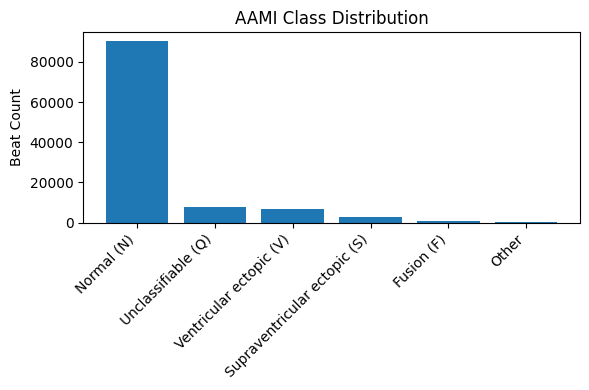

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your feature CSV
csv_file = "ecg_features_with_spectral.csv"  # <-- adjust path if needed
df = pd.read_csv(csv_file)

# 2) Define the MIT‑BIH → AAMI mapping
aami_map = {
    'N': 'Normal (N)',   'L': 'Normal (N)',   'R': 'Normal (N)',   'e': 'Normal (N)',   'j': 'Normal (N)',
    'V': 'Ventricular ectopic (V)', 'E': 'Ventricular ectopic (V)',
    'A': 'Supraventricular ectopic (S)', 'S': 'Supraventricular ectopic (S)',
    'a': 'Supraventricular ectopic (S)', 'J': 'Supraventricular ectopic (S)',
    'F': 'Fusion (F)',
    '/': 'Unclassifiable (Q)', 'f': 'Unclassifiable (Q)', 'Q': 'Unclassifiable (Q)'
}

# 3) Map into AAMI classes
df['AAMI_class'] = df['label'].map(aami_map).fillna('Other')

# 4) Build the tables
raw_dist = (
    df['label']
    .value_counts()
    .rename_axis('MITBIH_label')
    .reset_index(name='count')
)

aami_dist = (
    df['AAMI_class']
    .value_counts()
    .rename_axis('AAMI_class')
    .reset_index(name='count')
)

# 5) Print them
print("=== MIT‑BIH 15‑beat Label Distribution ===")
print(raw_dist.to_string(index=False))
print("\n=== AAMI 5‑class Distribution ===")
print(aami_dist.to_string(index=False))

# 6) (Optional) Bar chart of the AAMI classes
plt.figure(figsize=(6,4))
plt.bar(aami_dist['AAMI_class'], aami_dist['count'])
plt.title("AAMI Class Distribution")
plt.ylabel("Beat Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────── SETTINGS ────────────────────────────────
CSV_FILE = "ecg_features_with_spectral.csv"  # adjust to your filename

# ───────────────────────────── LOAD & MAP ──────────────────────────────
df = pd.read_csv(CSV_FILE)

# MIT-BIH → AAMI 5-class mapping
aami_map = {
    'N': 'Normal (N)',   'L': 'Normal (N)',   'R': 'Normal (N)',   'e': 'Normal (N)',   'j': 'Normal (N)',
    'V': 'Ventricular (V)', 'E': 'Ventricular (V)',
    'A': 'Supraventricular (S)', 'S': 'Supraventricular (S)',
    'a': 'Supraventricular (S)', 'J': 'Supraventricular (S)',
    'F': 'Fusion (F)',
    '/': 'Unclassifiable (Q)', 'f': 'Unclassifiable (Q)', 'Q': 'Unclassifiable (Q)'
}

df['AAMI_class'] = df['label'].map(aami_map).fillna('Other')

# ─────────────────────────── DISTRIBUTIONS ────────────────────────────
raw_dist = (
    df['label']
      .value_counts()
      .rename_axis('MITBIH_label')
      .reset_index(name='count')
)

aami_dist = (
    df['AAMI_class']
      .value_counts()
      .rename_axis('AAMI_class')
      .reset_index(name='count')
)

# ─────────────────────────── FILTER OUT “Other” ───────────────────────────
aami_dist = aami_dist[aami_dist['AAMI_class'] != 'Other'].reset_index(drop=True)

# ───────────────────────────── PRINT TABLES ─────────────────────────────
print("\n### MIT-BIH 15-beat Label Distribution\n")
print(raw_dist.to_string(index=False))

print("\n### AAMI 5-Class Distribution\n")
print(aami_dist.to_string(index=False))



### MIT-BIH 15-beat Label Distribution

MITBIH_label  count
           N  74704
           L   8037
           R   7257
           /   7004
           V   6728
           A   2543
           f    965
           F    790
           !    249
           j    229
           E     88
           J     83
           a     80
           |     33
           Q     25
           e     16
           S      2
           +      1
           ]      1
           ~      1

### AAMI 5-Class Distribution

          AAMI_class  count
          Normal (N)  90243
  Unclassifiable (Q)   7994
     Ventricular (V)   6816
Supraventricular (S)   2708
          Fusion (F)    790


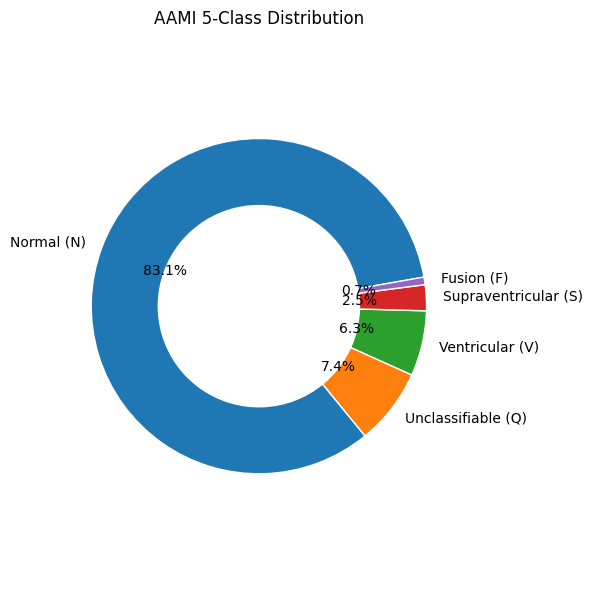

In [3]:
# ────────────────────────────── DONUT CHART ───────────────────────────────
plt.figure(figsize=(6,6))
plt.pie(
    aami_dist['count'],
    labels=aami_dist['AAMI_class'],
    autopct="%1.1f%%",
    startangle=10,
    wedgeprops=dict(width=0.4, edgecolor='w')  # <-- makes it a donut
)
plt.title("AAMI 5‑Class Distribution")
plt.axis("equal")   # keep it circular
plt.tight_layout()
plt.show()


In [39]:
# in a Jupyter or Colab notebook cell
!pip install imbalanced-learn


In [37]:
from sklearn.model_selection import train_test_split

# assume `df` already has all 72+ spectral features, plus `AAMI_class`
X = df.drop(columns=['AAMI_class','label','record'])
y = df['AAMI_class']

# stratify to keep each AAMI class proportionally in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


In [41]:
from imblearn.over_sampling import SMOTE

# your desired absolute counts on the train set
sampling_strategy = {
    'Supraventricular (S)': 5000,
    'Ventricular (V)'     : 20000,
    'Fusion (F)'          : 5000,
    'Unclassifiable (Q)'  : 20000,
    # note: by default SMOTE will leave the majority class ('Normal (N)')
    # alone, but you can downsample it later if you wish.
}

sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE, training class counts:")
print(pd.Series(y_res).value_counts())


After SMOTE, training class counts:
AAMI_class
Normal (N)              72194
Unclassifiable (Q)      20000
Ventricular (V)         20000
Supraventricular (S)     5000
Fusion (F)               5000
Other                     228
Name: count, dtype: int64


In [42]:
from scipy.stats import ks_2samp

for cls in sampling_strategy:
    real = X_train[y_train == cls]['QT_duration']
    synth = X_res[y_res == cls]['QT_duration']
    stat, p = ks_2samp(real, synth)
    print(f"{cls} QT_duration KS p-value: {p:.3f}")


Supraventricular (S) QT_duration KS p-value: 0.071
Ventricular (V) QT_duration KS p-value: 0.000
Fusion (F) QT_duration KS p-value: 0.000
Unclassifiable (Q) QT_duration KS p-value: 0.000


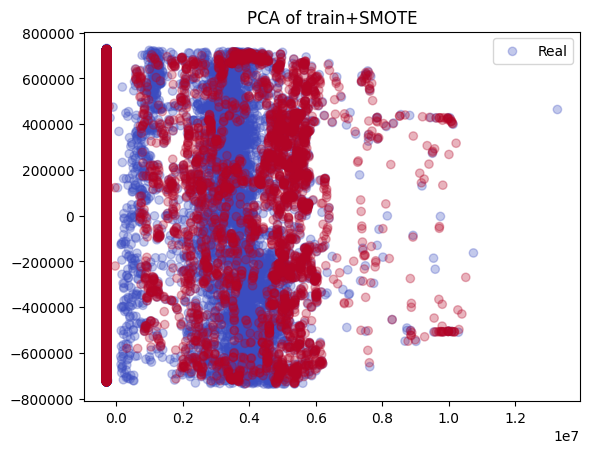

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(2).fit(X_res)
proj = pca.transform(X_res)
is_synth = np.concatenate([
    np.zeros(len(X_train)),  # real
    np.ones(len(X_res)-len(X_train))  # synthetic
])
plt.scatter(proj[:,0], proj[:,1], c=is_synth, cmap='coolwarm', alpha=0.3)
plt.legend(['Real','Synth'])
plt.title("PCA of train+SMOTE")
plt.show()


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

labels_rt = np.concatenate([np.zeros(len(X_train)), np.ones(len(X_res)-len(X_train))])
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(np.vstack([X_train, X_res[len(X_train):]]), labels_rt)
scores = rf.predict_proba(np.vstack([X_train, X_res[len(X_train):]]))[:,1]
print("Real-vs-Synth AUC:", roc_auc_score(labels_rt, scores))


Real-vs-Synth AUC: 0.9999999847313468


In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ─────────────────────────────── LOAD DATA ───────────────────────────────
df = pd.read_csv("ecg_features_with_spectral.csv")  # ← your feature CSV

# ────────────────────────── MAP & FILTER AAMI CLASSES ─────────────────────
aami_map = {
    'N': 'Normal (N)', 'L': 'Normal (N)', 'R': 'Normal (N)',
    'e': 'Normal (N)', 'j': 'Normal (N)',
    'V': 'Ventricular (V)', 'E': 'Ventricular (V)',
    'A': 'Supraventricular (S)', 'S': 'Supraventricular (S)',
    'a': 'Supraventricular (S)', 'J': 'Supraventricular (S)',
    'F': 'Fusion (F)',
    '/': 'Unclassifiable (Q)', 'f': 'Unclassifiable (Q)',
    'Q': 'Unclassifiable (Q)'
}
df['AAMI_class'] = df['label'].map(aami_map)
df = df[df['AAMI_class'].notna()].reset_index(drop=True)  # drop “Other”

# ────────────────────────────── 1) TRAIN/TEST SPLIT ─────────────────────────────
X = df.drop(columns=['label','AAMI_class','record'])
y = df['AAMI_class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.10,
    random_state=42
)

# ───────────────────────────── 2) DOWNSAMPLE NORMAL ────────────────────────────
maskN   = (y_train == 'Normal (N)')
to_keep = np.random.choice(
    X_train[maskN].index,
    size=50_000,
    replace=False
)
keep_idx = np.concatenate([to_keep, X_train[~maskN].index])
X_train = X_train.loc[keep_idx]
y_train = y_train.loc[keep_idx]

# ────────────────────────── 3) BORDERLINE-SMOTE UPSAMPLING ─────────────────────
sm = BorderlineSMOTE(
    sampling_strategy={
        'Supraventricular (S)': 3000,     # lowered from 5k
        'Ventricular (V)'     : 8000,     # lowered from 10k
        'Fusion (F)'          : 1500,     # lowered from 2k
        'Unclassifiable (Q)'  : 8000      # lowered from 10k
    },
    k_neighbors=3,
    random_state=42
)
X_res, y_res = sm.fit_resample(X_train, y_train)

# ────────────────────────────── 4) JITTER SYNTHETIC ────────────────────────────
# cast to float first so adding small noise won’t raise dtype warnings
X_res = X_res.astype(float)

is_synth = ~X_res.index.isin(X_train.index)
noise    = np.random.normal(scale=1e-3, size=X_res.shape)
X_res.loc[is_synth, :] += noise[is_synth, :]

# ────────────────────────────── 5) QC: KS TESTS ────────────────────────────
print("\n--- KS TESTS: real vs synth (p-values) ---")
ks_pvals = {}
for feat in X_res.columns:
    real_vals  = X_train[feat].values
    synth_vals = X_res.loc[is_synth, feat].values
    p = ks_2samp(real_vals, synth_vals).pvalue
    ks_pvals[feat] = p
    if p < 0.05:
        print(f"{feat:20s}  p={p:.3e}  (DIFFERENT)")
print("\n→ %d / %d features failed the KS test at α=0.05\n"
      % (sum(p<0.05 for p in ks_pvals.values()), len(ks_pvals)))

# ──────────────────── 6) QC: Real-vs-Synthetic Discriminator AUC ────────────────────
print("--- Real vs Synth Discriminator AUC ---")
X_disc = pd.concat([X_train, X_res.loc[is_synth]], axis=0)
y_disc = np.hstack([
    np.zeros(len(X_train)),       # real=0
    np.ones(sum(is_synth))        # synth=1
])
clf   = LogisticRegression(solver='liblinear', max_iter=500).fit(X_disc, y_disc)
probs = clf.predict_proba(X_disc)[:,1]
auc   = roc_auc_score(y_disc, probs)
print(f"Discriminator AUC = {auc:.6f}")
print("→ Aim for something close to 0.50; anything ≫ 0.60 means synth too easy to spot.")

# ─────────────────────────────── 7) FINAL MODEL TRAINING ─────────────────────────────
# Now that QC looks reasonable, you can train your downstream classifier on (X_res, y_res)
# and evaluate on (X_test, y_test).
#
# Example with RandomForest:
#
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics   import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)
print("\n--- Final RF on held-out test set ---")
print(classification_report(y_test, y_pred))



--- KS TESTS: real vs synth (p-values) ---
Tdiff_P_R             p=3.367e-82  (DIFFERENT)
Tdiff_Q_R             p=3.387e-234  (DIFFERENT)
Tdiff_S_R             p=4.450e-288  (DIFFERENT)
Tdiff_T_R             p=1.338e-16  (DIFFERENT)
Delta_P_Q             p=1.305e-22  (DIFFERENT)
Delta_P_S             p=2.083e-28  (DIFFERENT)
Delta_P_T             p=3.294e-06  (DIFFERENT)
Delta_Q_S             p=1.922e-30  (DIFFERENT)
Delta_Q_T             p=4.591e-04  (DIFFERENT)
Delta_S_T             p=1.005e-08  (DIFFERENT)
PT_duration           p=1.842e-06  (DIFFERENT)
QT_duration           p=9.154e-04  (DIFFERENT)
d_PQ                  p=1.475e-06  (DIFFERENT)
d_QR                  p=3.135e-08  (DIFFERENT)
d_RS                  p=2.761e-20  (DIFFERENT)
d_ST                  p=3.054e-02  (DIFFERENT)
d_PR                  p=2.399e-06  (DIFFERENT)
d_QS                  p=5.260e-05  (DIFFERENT)
d_PS                  p=1.364e-02  (DIFFERENT)
d_QT                  p=2.156e-02  (DIFFERENT)
AmpDiff_R_P   

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# ─────────────────────────────── LOAD DATA ───────────────────────────────
df = pd.read_csv("ecg_features_with_spectral.csv")

# ────────────────────────── MAP & FILTER AAMI CLASSES ─────────────────────
aami_map = {
    'N': 'Normal (N)', 'L': 'Normal (N)', 'R': 'Normal (N)',
    'e': 'Normal (N)', 'j': 'Normal (N)',
    'V': 'Ventricular (V)', 'E': 'Ventricular (V)',
    'A': 'Supraventricular (S)', 'S': 'Supraventricular (S)',
    'a': 'Supraventricular (S)', 'J': 'Supraventricular (S)',
    'F': 'Fusion (F)',
    '/': 'Unclassifiable (Q)', 'f': 'Unclassifiable (Q)', 'Q': 'Unclassifiable (Q)'
}
df['AAMI_class'] = df['label'].map(aami_map)
df = df[df['AAMI_class'].notna()].reset_index(drop=True)   # drop “Other”

# ─────────────────────────────── 1) SPLIT ────────────────────────────────
X = df.drop(columns=['label','AAMI_class','record'])
y = df['AAMI_class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.10, random_state=42
)

# ───────────────────────────── 2) DOWNSAMPLE NORMAL ───────────────────────
maskN   = (y_train == 'Normal (N)')
to_keep = np.random.choice(
    X_train[maskN].index,
    size=50_000,
    replace=False
)
keep_idx = np.concatenate([to_keep, X_train[~maskN].index])
X_train = X_train.loc[keep_idx]
y_train = y_train.loc[keep_idx]

# ────────────────────────── 3) BORDERLINE‐SMOTE UPSAMPLING ─────────────────
sm = BorderlineSMOTE(
    sampling_strategy={
        'Supraventricular (S)': 5000,  # extra boost
        'Fusion (F)'         : 5000,  # extra boost
        'Ventricular (V)'     :  8000,
        'Unclassifiable (Q)'  :  8000
    },
    k_neighbors=3,
    random_state=42
)
X_res, y_res = sm.fit_resample(X_train, y_train)

# ────────────────────────────── 4) OPTIONAL GAN SAMPLING ───────────────────
try:
    from sdv.tabular import CTGAN
    print("SDV found → running CTGAN on Fusion & S only…")
    gan = CTGAN(epochs=100)
    df_train = pd.concat([X_train, y_train], axis=1)
    # only Fusion
    fdf = df_train[df_train['AAMI_class']=='Fusion (F)']
    gan.fit(fdf)
    synth_f = gan.sample(4000)
    # only Supraventricular
    sdf = df_train[df_train['AAMI_class']=='Supraventricular (S)']
    gan.fit(sdf)
    synth_s = gan.sample(3000)

    X_gan = pd.concat([synth_f, synth_s], axis=0).drop(columns='AAMI_class')
    y_gan = pd.concat([synth_f['AAMI_class'], synth_s['AAMI_class']], axis=0)
    X_res = pd.concat([X_res.astype(float), X_gan.astype(float)], axis=0)
    y_res = pd.concat([y_res, y_gan], axis=0)
    print(f"  + Generated {len(synth_f)} Fusion and {len(synth_s)} Supraventricular samples via GAN.")
except ModuleNotFoundError:
    print("SDV not installed; skipping GAN step (install with `pip install sdv` to enable).")

# ─────────────────────────────── 5) JITTER ────────────────────────────────
X_res = X_res.astype(float)
is_synth = ~X_res.index.isin(X_train.index)
noise    = np.random.normal(scale=1e-3, size=X_res.shape)
X_res.loc[is_synth, :] += noise[is_synth, :]

# ─────────────────────────────── 6) QC: KS TEST ───────────────────────────
print("\n--- KS TESTS: real vs synth (p-values) ---")
ks_fail = 0
for feat in X_res.columns:
    p = ks_2samp(X_train[feat], X_res.loc[is_synth, feat]).pvalue
    if p < 0.05:
        ks_fail += 1
        print(f"{feat:20s} p={p:.3e} (DIFF)")
print(f"\n→ {ks_fail} / {len(X_res.columns)} features failed KS at α=0.05\n")

# ──────────────────── 7) QC: Real‐vs‐Synthetic AUC ────────────────────────
X_disc = pd.concat([X_train, X_res.loc[is_synth]], axis=0)
y_disc = np.hstack([np.zeros(len(X_train)), np.ones(is_synth.sum())])
clf    = LogisticRegression(solver='liblinear', max_iter=500).fit(X_disc, y_disc)
auc    = roc_auc_score(y_disc, clf.predict_proba(X_disc)[:,1])
print(f"Discriminator AUC = {auc:.4f} (want ≈0.50)")

# ──────────────────────────── 8) FINAL RF TRAIN & EVAL ─────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)

print("\n--- Final RF on held-out test set ---")
print(classification_report(y_test, y_pred))


SDV not installed; skipping GAN step (install with `pip install sdv` to enable).

--- KS TESTS: real vs synth (p-values) ---
Tdiff_P_R            p=2.405e-85 (DIFF)
Tdiff_Q_R            p=3.786e-259 (DIFF)
Tdiff_S_R            p=0.000e+00 (DIFF)
Tdiff_T_R            p=1.227e-24 (DIFF)
Delta_P_Q            p=5.290e-41 (DIFF)
Delta_P_S            p=1.188e-21 (DIFF)
Delta_P_T            p=1.757e-05 (DIFF)
Delta_Q_S            p=3.143e-47 (DIFF)
Delta_Q_T            p=4.443e-11 (DIFF)
Delta_S_T            p=5.020e-09 (DIFF)
PT_duration          p=3.337e-05 (DIFF)
QT_duration          p=1.649e-10 (DIFF)
d_PQ                 p=2.692e-11 (DIFF)
d_QR                 p=4.463e-07 (DIFF)
d_RS                 p=4.646e-22 (DIFF)
d_ST                 p=7.014e-08 (DIFF)
d_PR                 p=6.752e-05 (DIFF)
d_QS                 p=3.025e-12 (DIFF)
d_PS                 p=1.107e-06 (DIFF)
d_QT                 p=6.355e-04 (DIFF)
AmpDiff_R_P          p=6.990e-05 (DIFF)
AmpDiff_R_Q          p=4.429e-07 (

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# ─────────────────────────────── LOAD DATA ───────────────────────────────
df = pd.read_csv("ecg_features_with_spectral.csv")

# ────────────────────────── MAP & FILTER AAMI CLASSES ─────────────────────
aami_map = {
    'N': 'Normal (N)', 'L': 'Normal (N)', 'R': 'Normal (N)',
    'e': 'Normal (N)', 'j': 'Normal (N)',
    'V': 'Ventricular (V)', 'E': 'Ventricular (V)',
    'A': 'Supraventricular (S)', 'S': 'Supraventricular (S)',
    'a': 'Supraventricular (S)', 'J': 'Supraventricular (S)',
    'F': 'Fusion (F)',
    '/': 'Unclassifiable (Q)', 'f': 'Unclassifiable (Q)', 'Q': 'Unclassifiable (Q)'
}
df['AAMI_class'] = df['label'].map(aami_map)
df = df[df['AAMI_class'].notna()].reset_index(drop=True)   # drop “Other”

# ─────────────────────────────── 1) SPLIT ────────────────────────────────
X = df.drop(columns=['label','AAMI_class','record'])
y = df['AAMI_class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.10, random_state=42
)

# ───────────────────────────── 2) DOWNSAMPLE NORMAL ───────────────────────
maskN   = (y_train == 'Normal (N)')
to_keep = np.random.choice(
    X_train[maskN].index,
    size=50_000,
    replace=False
)
keep_idx = np.concatenate([to_keep, X_train[~maskN].index])
X_train = X_train.loc[keep_idx]
y_train = y_train.loc[keep_idx]

# ────────────────────────── 3) BORDERLINE‐SMOTE UPSAMPLING ─────────────────
sm = BorderlineSMOTE(
    sampling_strategy={
        'Supraventricular (S)': 5000,  # extra boost
        'Fusion (F)'         : 5000,  # extra boost
        'Ventricular (V)'     :  8000,
        'Unclassifiable (Q)'  :  8000
    },
    k_neighbors=3,
    random_state=42
)
X_res, y_res = sm.fit_resample(X_train, y_train)

# ────────────────────────────── 4) OPTIONAL GAN SAMPLING ───────────────────
try:
    from sdv.tabular import CTGAN
    print("SDV found → running CTGAN on Fusion & S only…")
    gan = CTGAN(epochs=100)
    df_train = pd.concat([X_train, y_train], axis=1)
    # only Fusion
    fdf = df_train[df_train['AAMI_class']=='Fusion (F)']
    gan.fit(fdf)
    synth_f = gan.sample(4000)
    # only Supraventricular
    sdf = df_train[df_train['AAMI_class']=='Supraventricular (S)']
    gan.fit(sdf)
    synth_s = gan.sample(3000)

    X_gan = pd.concat([synth_f, synth_s], axis=0).drop(columns='AAMI_class')
    y_gan = pd.concat([synth_f['AAMI_class'], synth_s['AAMI_class']], axis=0)
    X_res = pd.concat([X_res.astype(float), X_gan.astype(float)], axis=0)
    y_res = pd.concat([y_res, y_gan], axis=0)
    print(f"  + Generated {len(synth_f)} Fusion and {len(synth_s)} Supraventricular samples via GAN.")
except ModuleNotFoundError:
    print("SDV not installed; skipping GAN step (install with `pip install sdv` to enable).")

# ─────────────────────────────── 5) JITTER ────────────────────────────────
X_res = X_res.astype(float)
is_synth = ~X_res.index.isin(X_train.index)
noise    = np.random.normal(scale=1e-3, size=X_res.shape)
X_res.loc[is_synth, :] += noise[is_synth, :]

# ─────────────────────────────── 6) QC: KS TEST ───────────────────────────
print("\n--- KS TESTS: real vs synth (p-values) ---")
ks_fail = 0
for feat in X_res.columns:
    p = ks_2samp(X_train[feat], X_res.loc[is_synth, feat]).pvalue
    if p < 0.05:
        ks_fail += 1
        print(f"{feat:20s} p={p:.3e} (DIFF)")
print(f"\n→ {ks_fail} / {len(X_res.columns)} features failed KS at α=0.05\n")

# ──────────────────── 7) QC: Real‐vs‐Synthetic AUC ────────────────────────
X_disc = pd.concat([X_train, X_res.loc[is_synth]], axis=0)
y_disc = np.hstack([np.zeros(len(X_train)), np.ones(is_synth.sum())])
clf    = LogisticRegression(solver='liblinear', max_iter=500).fit(X_disc, y_disc)
auc    = roc_auc_score(y_disc, clf.predict_proba(X_disc)[:,1])
print(f"Discriminator AUC = {auc:.4f} (want ≈0.50)")

# ──────────────────────────── 8) FINAL RF TRAIN & EVAL ─────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)

print("\n--- Final RF on held-out test set ---")
print(classification_report(y_test, y_pred))


SDV not installed; skipping GAN step (install with `pip install sdv` to enable).

--- KS TESTS: real vs synth (p-values) ---
Tdiff_P_R            p=1.234e-84 (DIFF)
Tdiff_Q_R            p=4.040e-255 (DIFF)
Tdiff_S_R            p=0.000e+00 (DIFF)
Tdiff_T_R            p=8.879e-26 (DIFF)
Delta_P_Q            p=5.176e-40 (DIFF)
Delta_P_S            p=8.650e-20 (DIFF)
Delta_P_T            p=1.017e-04 (DIFF)
Delta_Q_S            p=1.310e-48 (DIFF)
Delta_Q_T            p=7.448e-10 (DIFF)
Delta_S_T            p=7.698e-08 (DIFF)
PT_duration          p=8.192e-05 (DIFF)
QT_duration          p=4.744e-09 (DIFF)
d_PQ                 p=2.138e-12 (DIFF)
d_QR                 p=4.641e-09 (DIFF)
d_RS                 p=1.854e-22 (DIFF)
d_ST                 p=1.086e-07 (DIFF)
d_PR                 p=1.005e-06 (DIFF)
d_QS                 p=2.131e-16 (DIFF)
d_PS                 p=2.565e-07 (DIFF)
d_QT                 p=1.907e-05 (DIFF)
AmpDiff_R_P          p=1.043e-06 (DIFF)
AmpDiff_R_Q          p=4.331e-09 (

In [65]:
!pip install seaborn


=== Random Forest ===
 Accuracy : 0.9826
 Macro-F1 : 0.9109

                      precision    recall  f1-score   support

          Normal (N)     0.9850    0.9962    0.9906      9025
     Ventricular (V)     0.9581    0.9384    0.9481       682
Supraventricular (S)     0.9770    0.7823    0.8689       271
          Fusion (F)     0.7973    0.7468    0.7712        79
  Unclassifiable (Q)     0.9948    0.9574    0.9758       799

            accuracy                         0.9826     10856
           macro avg     0.9424    0.8842    0.9109     10856
        weighted avg     0.9825    0.9826    0.9822     10856



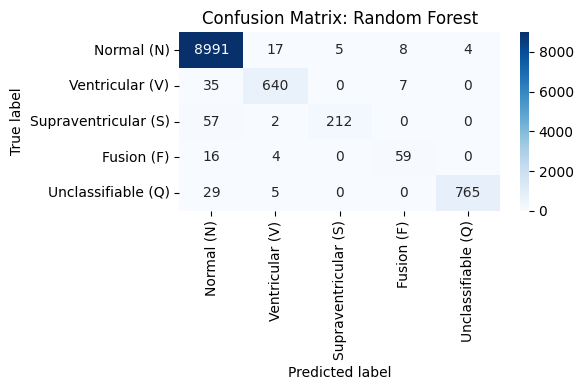


=== KNN (k=5) ===
 Accuracy : 0.9754
 Macro-F1 : 0.8818

                      precision    recall  f1-score   support

          Normal (N)     0.9877    0.9857    0.9867      9025
     Ventricular (V)     0.9445    0.9238    0.9340       682
Supraventricular (S)     0.8175    0.8266    0.8220       271
          Fusion (F)     0.6238    0.7975    0.7000        79
  Unclassifiable (Q)     0.9616    0.9712    0.9664       799

            accuracy                         0.9754     10856
           macro avg     0.8670    0.9009    0.8818     10856
        weighted avg     0.9761    0.9754    0.9757     10856



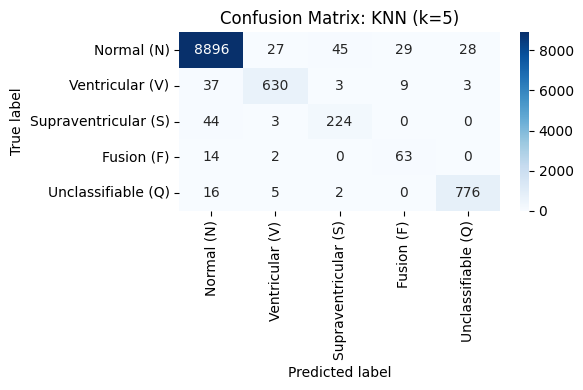


=== Logistic (sag) ===


/home/hbhatt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



 Accuracy : 0.7278
 Macro-F1 : 0.5310

                      precision    recall  f1-score   support

          Normal (N)     0.9799    0.7020    0.8180      9025
     Ventricular (V)     0.5702    0.8636    0.6869       682
Supraventricular (S)     0.1349    0.7306    0.2277       271
          Fusion (F)     0.0648    0.7342    0.1191        79
  Unclassifiable (Q)     0.7243    0.9011    0.8031       799

            accuracy                         0.7278     10856
           macro avg     0.4948    0.7863    0.5310     10856
        weighted avg     0.9076    0.7278    0.7889     10856



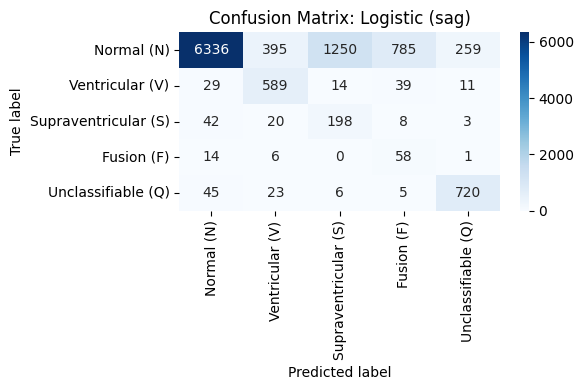


=== SGD SVM ===
 Accuracy : 0.8771
 Macro-F1 : 0.6393

                      precision    recall  f1-score   support

          Normal (N)     0.9746    0.8870    0.9287      9025
     Ventricular (V)     0.6315    0.8695    0.7316       682
Supraventricular (S)     0.3870    0.6568    0.4870       271
          Fusion (F)     0.1144    0.5949    0.1918        79
  Unclassifiable (Q)     0.8401    0.8748    0.8571       799

            accuracy                         0.8771     10856
           macro avg     0.5895    0.7766    0.6393     10856
        weighted avg     0.9222    0.8771    0.8947     10856



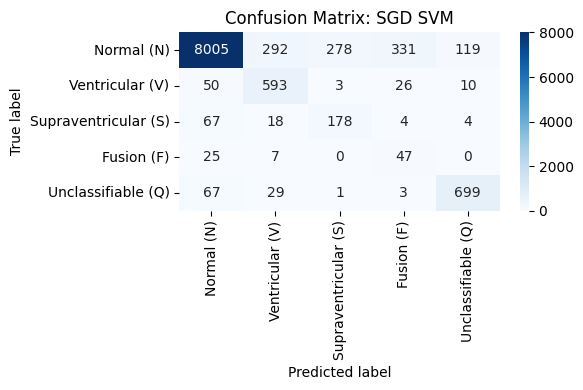


=== Baseline Models Comparison ===


,Accuracy,Macro-F1
Model,,
Random Forest,0.982590,0.910918
KNN (k=5),0.975405,0.881822
Logistic (sag),0.727800,0.530968
SGD SVM,0.877119,0.639268


In [6]:
# ─────────────────────────────── Imports ──────────────────────────────
import numpy as np
import pandas as pd

from sklearn.pipeline        import make_pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.model_selection import train_test_split

from imblearn.over_sampling  import BorderlineSMOTE

from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import SGDClassifier, LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ───────────────────────────── Assumed Data ─────────────────────────────
# X_res, y_res  → augmented train set
# X_test, y_test → hold-out test set

class_labels = [
    "Normal (N)",
    "Ventricular (V)",
    "Supraventricular (S)",
    "Fusion (F)",
    "Unclassifiable (Q)"
]

# ─────────────────────────── Baseline Models ────────────────────────────
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, n_jobs=-1,
        class_weight="balanced", random_state=42
    ),

    "KNN (k=5)": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),

    "Logistic (sag)": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="sag",  # fast on large data
            max_iter=1000,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42
        )
    ),

    "SGD SVM": make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss="hinge",    # linear SVM
            max_iter=1000,
            tol=1e-3,
            class_weight="balanced",
            random_state=42
        )
    ),

    # If you really want to, you can add a small PCA step here:
    # "SGD+PCA": make_pipeline(
    #     StandardScaler(),
    #     PCA(n_components=30, random_state=42),
    #     SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, class_weight="balanced", random_state=42)
    # )
}

results = []
for name, clf in models.items():
    print(f"\n=== {name} ===")
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_test)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f" Accuracy : {acc:.4f}")
    print(f" Macro-F1 : {macro_f1:.4f}\n")
    print(classification_report(
        y_test, y_pred,
        labels=class_labels,
        target_names=class_labels,
        digits=4
    ))

    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_labels,
                yticklabels=class_labels,
                cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model":    name,
        "Accuracy": acc,
        "Macro-F1": macro_f1
    })

summary_df = pd.DataFrame(results).set_index("Model")
print("\n=== Baseline Models Comparison ===")
display(summary_df)


→ XGBoost Accuracy : 0.9878
→ XGBoost Macro-F1  : 0.9313

                      precision    recall  f1-score   support

          Normal (N)     0.9916    0.9961    0.9939      9025
     Ventricular (V)     0.9631    0.9560    0.9595       682
Supraventricular (S)     0.9320    0.8598    0.8944       271
          Fusion (F)     0.8400    0.7975    0.8182        79
  Unclassifiable (Q)     0.9975    0.9837    0.9905       799

            accuracy                         0.9878     10856
           macro avg     0.9448    0.9186    0.9313     10856
        weighted avg     0.9877    0.9878    0.9877     10856



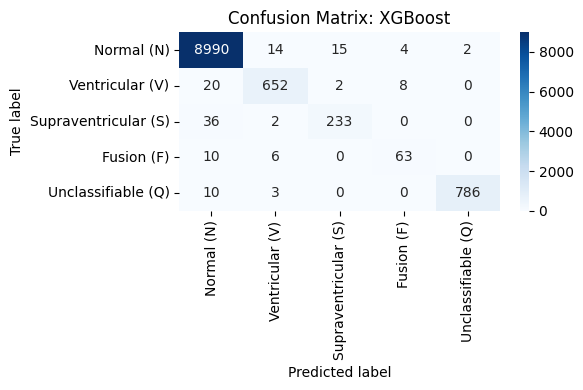

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ────────────────────────── Assumed in memory ──────────────────────────
# X_res, y_res  → your augmented train set (features + labels, strings)
# X_test, y_test → your hold-out test set (features + labels, strings)
# class_labels  → ["Normal (N)", "Ventricular (V)", "Supraventricular (S)", "Fusion (F)", "Unclassifiable (Q)"]

# ───────────────────────── 0) Encode string labels → integers ──────────────
le = LabelEncoder()
le.fit(class_labels)
y_train_enc = le.transform(y_res)
y_test_enc  = le.transform(y_test)

# ──────────────────────── 1) Build & fit XGBoost ─────────────────────────
xgb_clf = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    objective="multi:softprob",
    num_class=len(class_labels),
    eval_metric="mlogloss"
)

xgb_clf.fit(
    X_res.values,
    y_train_enc,
    verbose=False
)

# ────────────────────── 2) Predict & decode back to strings ───────────────
y_pred_enc = xgb_clf.predict(X_test.values)
y_pred     = le.inverse_transform(y_pred_enc)

# ───────────────────── 3) Metrics & classification report ─────────────────
acc  = accuracy_score(y_test, y_pred)
f1m  = f1_score(y_test, y_pred, average="macro")

print(f"→ XGBoost Accuracy : {acc:.4f}")
print(f"→ XGBoost Macro-F1  : {f1m:.4f}\n")

print(classification_report(
    y_test, y_pred,
    labels=class_labels,
    target_names=class_labels,
    digits=4
))

# ──────────────────── 4) Confusion Matrix ────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=class_labels)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.title("Confusion Matrix: XGBoost")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()



=== Random Forest ===
 Accuracy : 0.9836
 Macro-F1 : 0.9144

                      precision    recall  f1-score   support

          Normal (N)     0.9867    0.9958    0.9912      9025
     Ventricular (V)     0.9598    0.9443    0.9520       682
Supraventricular (S)     0.9604    0.8044    0.8755       271
          Fusion (F)     0.8082    0.7468    0.7763        79
  Unclassifiable (Q)     0.9910    0.9637    0.9772       799

            accuracy                         0.9836     10856
           macro avg     0.9412    0.8910    0.9144     10856
        weighted avg     0.9834    0.9836    0.9833     10856



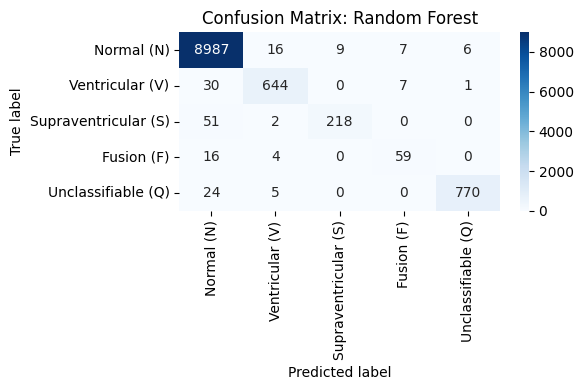


=== KNN (k=5) ===
 Accuracy : 0.9732
 Macro-F1 : 0.8734

                      precision    recall  f1-score   support

          Normal (N)     0.9891    0.9823    0.9857      9025
     Ventricular (V)     0.9296    0.9296    0.9296       682
Supraventricular (S)     0.7517    0.8376    0.7923       271
          Fusion (F)     0.6038    0.8101    0.6919        79
  Unclassifiable (Q)     0.9651    0.9700    0.9675       799

            accuracy                         0.9732     10856
           macro avg     0.8478    0.9059    0.8734     10856
        weighted avg     0.9748    0.9732    0.9738     10856



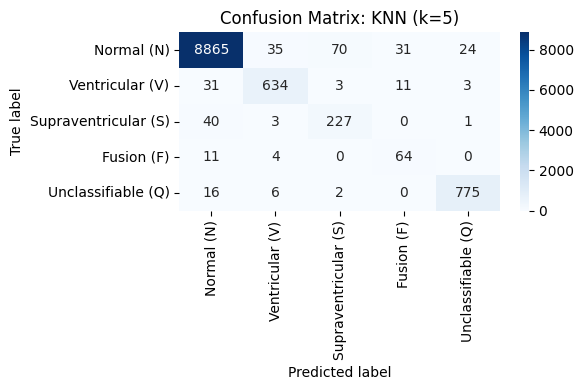


=== Logistic (sag) ===


/home/hbhatt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



 Accuracy : 0.7442
 Macro-F1 : 0.5401

                      precision    recall  f1-score   support

          Normal (N)     0.9812    0.7212    0.8313      9025
     Ventricular (V)     0.5744    0.8607    0.6890       682
Supraventricular (S)     0.1452    0.7232    0.2418       271
          Fusion (F)     0.0718    0.7722    0.1315        79
  Unclassifiable (Q)     0.7253    0.9086    0.8067       799

            accuracy                         0.7442     10856
           macro avg     0.4996    0.7972    0.5401     10856
        weighted avg     0.9093    0.7442    0.8008     10856



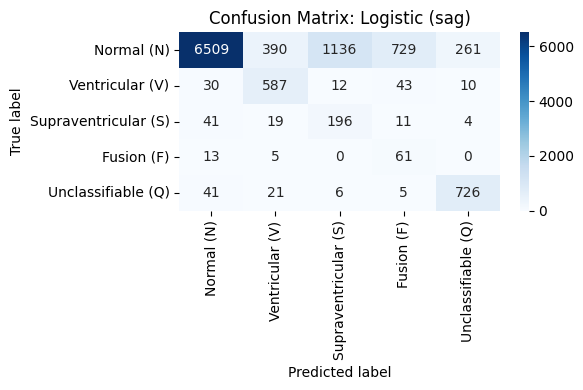


=== SGD SVM ===
 Accuracy : 0.8735
 Macro-F1 : 0.6332

                      precision    recall  f1-score   support

          Normal (N)     0.9763    0.8813    0.9264      9025
     Ventricular (V)     0.5796    0.8754    0.6974       682
Supraventricular (S)     0.3839    0.6531    0.4836       271
          Fusion (F)     0.1519    0.5443    0.2376        79
  Unclassifiable (Q)     0.7615    0.8911    0.8212       799

            accuracy                         0.8735     10856
           macro avg     0.5707    0.7691    0.6332     10856
        weighted avg     0.9148    0.8735    0.8882     10856



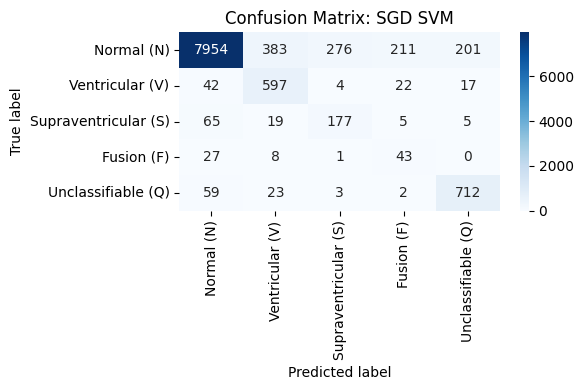


=== Baseline Models Comparison ===


,Accuracy,Macro-F1
Model,,
Random Forest,0.983604,0.914433
KNN (k=5),0.973195,0.873406
Logistic (sag),0.744197,0.540054
SGD SVM,0.873526,0.633244


In [17]:
# ─────────────────────────────── Imports ──────────────────────────────
import numpy as np
import pandas as pd

from sklearn.pipeline        import make_pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.model_selection import train_test_split

from imblearn.over_sampling  import BorderlineSMOTE

from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import SGDClassifier, LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ───────────────────────────── Assumed Data ─────────────────────────────
# X_res, y_res  → augmented train set
# X_test, y_test → hold-out test set

class_labels = [
    "Normal (N)",
    "Ventricular (V)",
    "Supraventricular (S)",
    "Fusion (F)",
    "Unclassifiable (Q)"
]

# ─────────────────────────── Baseline Models ────────────────────────────
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, n_jobs=-1,
        class_weight="balanced", random_state=42
    ),

    "KNN (k=5)": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),

    "Logistic (sag)": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="sag",  # fast on large data
            max_iter=1000,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42
        )
    ),

    "SGD SVM": make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss="hinge",    # linear SVM
            max_iter=1000,
            tol=1e-3,
            class_weight="balanced",
            random_state=42
        )
    ),

    # If you really want to, you can add a small PCA step here:
    # "SGD+PCA": make_pipeline(
    #     StandardScaler(),
    #     PCA(n_components=30, random_state=42),
    #     SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, class_weight="balanced", random_state=42)
    # )
}

results = []
for name, clf in models.items():
    print(f"\n=== {name} ===")
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_test)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f" Accuracy : {acc:.4f}")
    print(f" Macro-F1 : {macro_f1:.4f}\n")
    print(classification_report(
        y_test, y_pred,
        labels=class_labels,
        target_names=class_labels,
        digits=4
    ))

    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_labels,
                yticklabels=class_labels,
                cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model":    name,
        "Accuracy": acc,
        "Macro-F1": macro_f1
    })

summary_df = pd.DataFrame(results).set_index("Model")
print("\n=== Baseline Models Comparison ===")
display(summary_df)


In [19]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 50.4 MB/s eta 0:00:0000:0100:01


In [8]:
import numpy as np
import pandas as pd

# X_res is your augmented training features
corr = pd.DataFrame(X_res, columns=X_res.columns).corr().abs()
# Select upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find columns with correlation > 0.90
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
print(f"Dropping {len(to_drop)} highly-correlated features:", to_drop)

X_reduced = X_res.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)


Dropping 25 highly-correlated features: ['Delta_Q_T', 'Delta_S_T', 'PT_duration', 'QT_duration', 'AmpDiff_R_P', 'AmpDiff_R_Q', 'AmpDiff_R_S', 'AmpDiff_P_Q', 'AmpDiff_Q_R', 'AmpDiff_S_T', 'AmpDiff_P_S', 'AmpDiff_Q_S', 'AmpDiff_Q_T', 'Ratio_PQ_QR', 'Slope_P_T', 'Slope_Q_T', 'QRS_perimeter', 'QRS_inradius', 'spec_rolloff', 'spec_flatness', 'P_idx', 'Q_idx', 'R_idx', 'S_idx', 'T_idx']


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_reduced, y_res)

importances = pd.Series(rf.feature_importances_, index=X_reduced.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(20))   # your top 20 features


bp_0_5              0.052053
spec_entropy        0.049419
Tdiff_S_R           0.043697
bp_ratio_lo_hi      0.040800
Slope_R_S           0.034006
spec_bandwidth      0.026643
Angle_PQR           0.025510
d_RS                0.025123
d_QR                0.024961
d_QS                0.024067
Angle_RPT           0.021651
Tdiff_T_R           0.021181
Ratio_QS_RT         0.021171
d_ST                0.020785
AmpDiff_P_T         0.020653
spec_pow_total      0.019243
Ratio_RS_RT         0.018839
QRS_centroid_amp    0.018491
Ratio_QR_ST         0.017893
Ratio_RT_PT         0.017675
dtype: float64


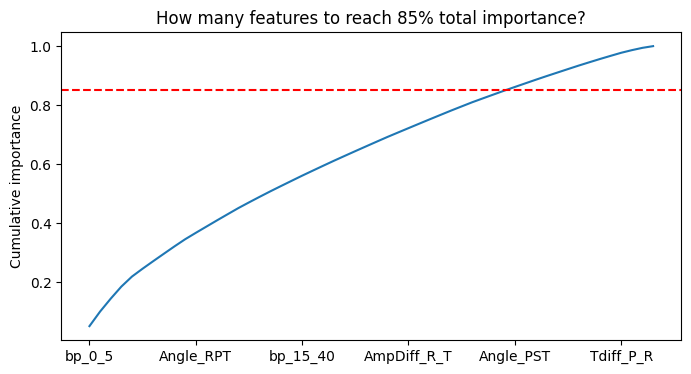

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
(importances.cumsum()/importances.sum()).plot()
plt.ylabel("Cumulative importance")
plt.axhline(0.85, color='red', linestyle='--')
plt.title("How many features to reach 85% total importance?")
plt.show()


In [12]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics     import classification_report, f1_score

# ───────────────────────────── LOAD DATA ─────────────────────────────
df = pd.read_csv("ecg_features_with_spectral.csv")
# … your AAMI mapping, train/test split, downsample + SMOTE/jitter etc …
# Let’s assume you end up with:
#   X_res (pd.DataFrame), y_res (pd.Series)  ← your GPU-ready train set
#   X_test, y_test                          ← your hold-out set

# ─────────────────────────── ENCODE LABELS ───────────────────────────
le       = LabelEncoder().fit(y_res)
y_res_enc  = le.transform(y_res)     # 0…4
y_test_enc = le.transform(y_test)

# ─────────────────────────── TO NUMPY FLOAT32 ────────────────────────
# XGBoost’s GPU kernel expects float32 arrays
X_train_np = X_res.values.astype("float32")
X_test_np  = X_test.values.astype("float32")

# ─────────────────────────── BUILD DMATRICES ─────────────────────────
dtrain = xgb.DMatrix(X_train_np, label=y_res_enc)
dtest  = xgb.DMatrix(X_test_np,  label=y_test_enc)

# ───────────────────────────── PARAMETERS ────────────────────────────
# Make sure you have the GPU‐enabled XGBoost installed (e.g. via
#   pip install xgboost==1.7.0 
# or conda install -c rapidsai -c nvidia -c conda-forge xgboost-gpu)
params = {
    "tree_method":    "gpu_hist",        # ← GPU histogram algorithm
    "predictor":      "gpu_predictor",   # ← GPU prediction
    "objective":      "multi:softprob",  # ← multiclass
    "num_class":      len(le.classes_),  
    "learning_rate":  0.1,
    "max_depth":      6,
    "subsample":      0.8,
    "colsample_bytree":0.8,
    "eval_metric":    "mlogloss",
    "gpu_id":         0                  # ← use GPU #0
}

# ─────────────────────── TRAIN WITH EARLY STOPPING ────────────────────
evals = [(dtrain, "train"), (dtest, "valid")]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=10
)

# ─────────────────────────── PREDICT & EVAL ───────────────────────────
probs = bst.predict(dtest)
preds = np.argmax(probs, axis=1)

print("\nHold-out classification report:\n")
print(classification_report(y_test_enc, preds, target_names=le.classes_, digits=4))
print("Hold-out macro-F1:", f1_score(y_test_enc, preds, average="macro"))


[0]	train-mlogloss:1.41206	valid-mlogloss:1.40452


/home/hbhatt/miniconda3/lib/python3.13/site-packages/xgboost/callback.py:386: UserWarning:

[23:28:27] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0

/home/hbhatt/miniconda3/lib/python3.13/site-packages/xgboost/callback.py:386: UserWarning:

[23:28:27] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"


/home/hbhatt/miniconda3/lib/python3.13/site-packages/xgboost/callback.py:386: UserWarning:

[23:28:27] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.




[10]	train-mlogloss:0.56291	valid-mlogloss:0.53132
[20]	train-mlogloss:0.29370	valid-mlogloss:0.26484
[30]	train-mlogloss:0.18052	valid-mlogloss:0.16066
[40]	train-mlogloss:0.12525	valid-mlogloss:0.11480
[50]	train-mlogloss:0.09590	valid-mlogloss:0.09316
[60]	train-mlogloss:0.07829	valid-mlogloss:0.08156
[70]	train-mlogloss:0.06644	valid-mlogloss:0.07458
[80]	train-mlogloss:0.05704	valid-mlogloss:0.06941
[90]	train-mlogloss:0.05011	valid-mlogloss:0.06565
[100]	train-mlogloss:0.04383	valid-mlogloss:0.06254
[110]	train-mlogloss:0.03876	valid-mlogloss:0.05983
[120]	train-mlogloss:0.03477	valid-mlogloss:0.05770
[130]	train-mlogloss:0.03077	valid-mlogloss:0.05547
[140]	train-mlogloss:0.02753	valid-mlogloss:0.05390
[150]	train-mlogloss:0.02481	valid-mlogloss:0.05269
[160]	train-mlogloss:0.02222	valid-mlogloss:0.05145
[170]	train-mlogloss:0.02007	valid-mlogloss:0.05063
[180]	train-mlogloss:0.01836	valid-mlogloss:0.04982
[190]	train-mlogloss:0.01670	valid-mlogloss:0.04912
[199]	train-mlogloss:

/home/hbhatt/miniconda3/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning:

[23:28:30] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"




In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing    import LabelEncoder
from sklearn.model_selection   import RandomizedSearchCV
from sklearn.metrics          import make_scorer, f1_score, classification_report

# ───────────────────────── LOAD & PREP ────────────────────────────────
df = pd.read_csv("ecg_features_with_spectral.csv")
# … your AAMI‐mapping, train/test split, downsample & SMOTE & jitter …
# assume X_res, y_res, X_test, y_test are ready here

# numpy arrays
X_res_np  = X_res.values.astype("float32")
X_test_np = X_test.values.astype("float32")

# encode text‐labels → ints 0…4
le       = LabelEncoder()
y_res_enc   = le.fit_transform(y_res)
y_test_enc  = le.transform(y_test)

# ───────────────────────── DEFINE MODEL ───────────────────────────────
xgb_clf = XGBClassifier(
    tree_method="hist",
    device="cuda",
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1
)

# ─────────────────────────── SEARCH SPACE ─────────────────────────────
param_dist = {
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [3, 5, 7],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma":            [0, 0.1, 0.2],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1.0, 5.0, 10.0],
    "n_estimators":     [50, 100, 150]
}

macro_f1 = make_scorer(f1_score, average="macro")

search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=macro_f1,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

# ───────────────────── RUN THE RANDOMIZED SEARCH ──────────────────────
search.fit(X_res_np, y_res_enc)

print("\nBest hyper‐parameters:")
print(search.best_params_)
print(f"Best CV Macro‐F1 = {search.best_score_:.4f}")

# ─────────────────────── FINAL RE‐FIT & EVAL ──────────────────────────
best = search.best_estimator_
best.fit(X_res_np, y_res_enc)   # no early‐stop here

y_pred_enc = best.predict(X_test_np)
y_pred     = le.inverse_transform(y_pred_enc)

print("\n=== Final XGBoost on hold-out ===")
print(classification_report(y_test, y_pred, digits=4))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=100, reg_alpha=1.0, reg_lambda=5.0, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=100, reg_alpha=1.0, reg_lambda=5.0, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=100, reg_alpha=1.0, reg_lambda=5.0, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0.1, reg_lambda=10.0, subsample=1.0; total time=   1.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0.1, reg_lambda=10.0, subsample=1.0; total time=   1.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0.1, reg_lambda=10.0, subsample=1.0; total t

In [18]:
# after your RandomizedSearchCV called `search` finishes...
xgb_best = search.best_estimator_



── Classification Report (before threshold tuning) ──
                      precision    recall  f1-score   support

          Fusion (F)     0.8101    0.8101    0.8101        79
          Normal (N)     0.9893    0.9947    0.9920      9025
Supraventricular (S)     0.9150    0.8339    0.8726       271
  Unclassifiable (Q)     0.9962    0.9787    0.9874       799
     Ventricular (V)     0.9583    0.9428    0.9505       682

            accuracy                         0.9849     10856
           macro avg     0.9338    0.9121    0.9225     10856
        weighted avg     0.9847    0.9849    0.9847     10856



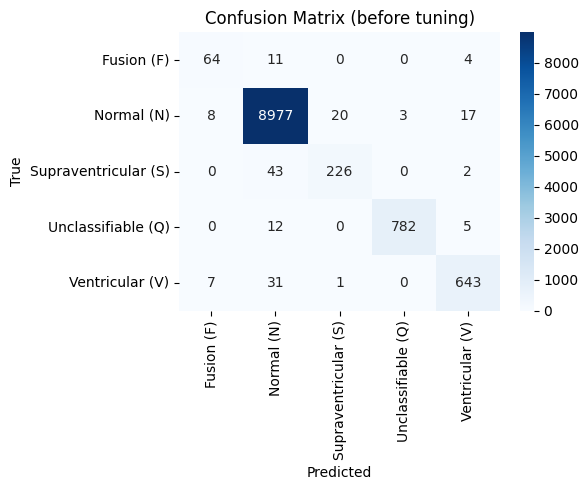


── Per-class best thresholds (max F₁ on PR curve) ──
Fusion (F)            best_thr = 0.49,  F₁ = 0.818
Normal (N)            best_thr = 0.49,  F₁ = 0.992
Supraventricular (S)  best_thr = 0.49,  F₁ = 0.873
Unclassifiable (Q)    best_thr = 0.34,  F₁ = 0.988
Ventricular (V)       best_thr = 0.32,  F₁ = 0.952

── Classification Report (after threshold tuning) ──
                      precision    recall  f1-score   support

          Fusion (F)     0.8101    0.8101    0.8101        79
          Normal (N)     0.9899    0.9942    0.9920      9025
Supraventricular (S)     0.9150    0.8339    0.8726       271
  Unclassifiable (Q)     0.9937    0.9800    0.9868       799
     Ventricular (V)     0.9557    0.9487    0.9522       682

            accuracy                         0.9850     10856
           macro avg     0.9329    0.9134    0.9227     10856
        weighted avg     0.9848    0.9850    0.9848     10856



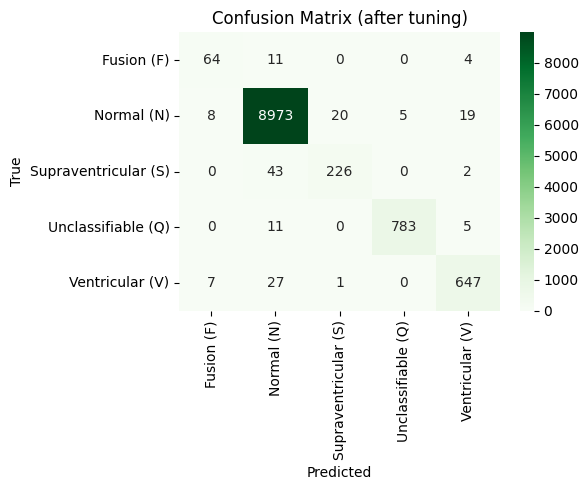

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder

# ───────────────────────── ASSUMED IN SCOPE ──────────────────────────
# 1) xgb_best        → your tuned XGBClassifier
# 2) search.best_estimator_ is xgb_best
# 3) X_test, y_test  → your hold‐out (pandas DataFrame + Series)
# 4) le              → the LabelEncoder you used to encode y_res for training

# If you haven’t already kept le around, re-fit it here:
le = LabelEncoder().fit(y_res)        # y_res = your augmented train‐labels (strings)
y_test_enc = le.transform(y_test)     # numeric version of the hold‐out labels
class_labels = le.classes_.tolist()   # e.g. ["Normal (N)", "Ventricular (V)", …]

# ───────────────────── 1) BEFORE THRESHOLD TUNING ─────────────────────
# (Get numeric preds, then decode back to strings)
y_pred_enc = xgb_best.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("\n── Classification Report (before threshold tuning) ──")
print(classification_report(
    y_test,
    y_pred,
    labels=class_labels,
    target_names=class_labels,
    digits=4
))

cm = confusion_matrix(y_test, y_pred, labels=class_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.title("Confusion Matrix (before tuning)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ──────────────────── 2) THRESHOLD TUNING ────────────────────────────
probs = xgb_best.predict_proba(X_test)

print("\n── Per-class best thresholds (max F₁ on PR curve) ──")
thresholds = {}
for idx, cls in enumerate(class_labels):
    y_true_bin = (y_test == cls).astype(int)
    precision, recall, thr = precision_recall_curve(y_true_bin, probs[:, idx])
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_i = np.argmax(f1_scores[:-1])  # ignore the last support point
    thresholds[cls] = thr[best_i]
    print(f"{cls:20s}  best_thr = {thresholds[cls]:.2f},  F₁ = {f1_scores[best_i]:.3f}")

# ──────────────────── 3) APPLY & RE-EVALUATE ─────────────────────────
def predict_with_thresholds(probs, thresholds, class_labels):
    preds = []
    for p in probs:
        passed = [cls for cls in class_labels 
                  if p[class_labels.index(cls)] >= thresholds[cls]]
        if passed:
            # pick the one with largest margin above its threshold
            choice = max(passed, key=lambda c: p[class_labels.index(c)] - thresholds[c])
        else:
            # fallback = highest-prob class
            choice = class_labels[np.argmax(p)]
        preds.append(choice)
    return np.array(preds)

y_pred_tuned = predict_with_thresholds(probs, thresholds, class_labels)

print("\n── Classification Report (after threshold tuning) ──")
print(classification_report(
    y_test,
    y_pred_tuned,
    labels=class_labels,
    target_names=class_labels,
    digits=4
))

cm2 = confusion_matrix(y_test, y_pred_tuned, labels=class_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Greens")
plt.title("Confusion Matrix (after tuning)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()



── Calibrating probabilities via isotonic regression... ──

── Classification Report (before threshold tuning) ──
                      precision    recall  f1-score   support

          Fusion (F)     0.8289    0.7975    0.8129        79
          Normal (N)     0.9903    0.9925    0.9914      9025
Supraventricular (S)     0.8707    0.8450    0.8577       271
  Unclassifiable (Q)     0.9899    0.9825    0.9862       799
     Ventricular (V)     0.9514    0.9472    0.9493       682

            accuracy                         0.9838     10856
           macro avg     0.9263    0.9129    0.9195     10856
        weighted avg     0.9836    0.9838    0.9837     10856



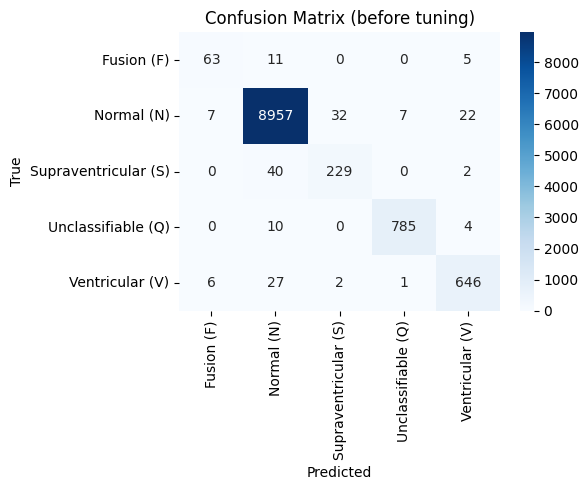


── Per-class best thresholds (max F₁ on PR curve) ──
Fusion (F)            best_thr = 0.45,  F₁ = 0.828
Normal (N)            best_thr = 0.36,  F₁ = 0.992
Supraventricular (S)  best_thr = 0.69,  F₁ = 0.872
Unclassifiable (Q)    best_thr = 0.52,  F₁ = 0.987
Ventricular (V)       best_thr = 0.46,  F₁ = 0.953

── Classification Report (after threshold tuning) ──
                      precision    recall  f1-score   support

          Fusion (F)     0.8400    0.7975    0.8182        79
          Normal (N)     0.9895    0.9945    0.9920      9025
Supraventricular (S)     0.9113    0.8339    0.8709       271
  Unclassifiable (Q)     0.9936    0.9787    0.9861       799
     Ventricular (V)     0.9556    0.9472    0.9514       682

            accuracy                         0.9849     10856
           macro avg     0.9380    0.9104    0.9237     10856
        weighted avg     0.9847    0.9849    0.9847     10856



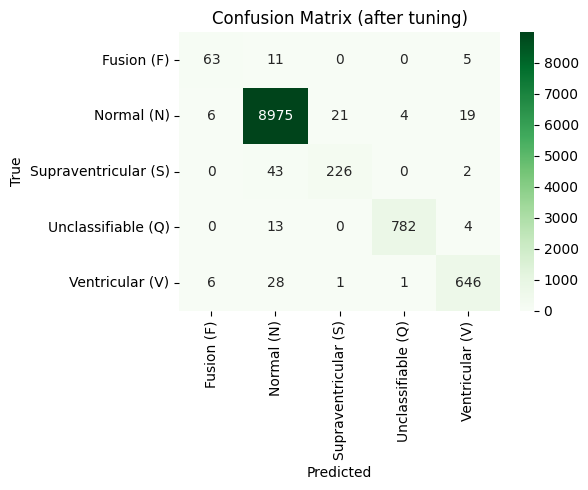

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV

# ───────────────────────── ASSUMED IN SCOPE ──────────────────────────
#  xgb_best       → your tuned XGBClassifier (already .fit on X_res, y_res_enc)
#  X_res, y_res   → your augmented train set
#  X_test, y_test → your hold‐out set

# ─────────────────── 0) LABEL-ENCODE ALL TARGETS ─────────────────────
le        = LabelEncoder().fit(y_res)
class_labels = le.classes_.tolist()            # e.g. ["Fusion (F)", "Normal (N)", …]
y_res_enc   = le.transform(y_res)              # numeric 0–4
y_test_enc  = le.transform(y_test)

# ───────────────────── 1) PROBABILITY CALIBRATION ─────────────────────
print("\n── Calibrating probabilities via isotonic regression... ──")
calibrator = CalibratedClassifierCV(
    estimator=xgb_best,
    method="isotonic",
    cv=10
)
calibrator.fit(X_res, y_res_enc)
model = calibrator  # from now on use model.predict / model.predict_proba

# ───────────────────── 2) BEFORE THRESHOLD TUNING ─────────────────────
y_pred_enc = model.predict(X_test)
print("\n── Classification Report (before threshold tuning) ──")
print(classification_report(
    y_test_enc,
    y_pred_enc,
    labels=range(len(class_labels)),
    target_names=class_labels,
    digits=4
))

cm = confusion_matrix(y_test_enc, y_pred_enc, labels=range(len(class_labels)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.title("Confusion Matrix (before tuning)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ─────────────────── 3) THRESHOLD TUNING ────────────────────────────
probs = model.predict_proba(X_test)

print("\n── Per-class best thresholds (max F₁ on PR curve) ──")
thresholds = {}
for idx, cls in enumerate(class_labels):
    y_true_bin = (y_test_enc == idx).astype(int)
    precision, recall, thr = precision_recall_curve(y_true_bin, probs[:, idx])
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_i    = np.argmax(f1_scores[:-1])
    thresholds[idx] = thr[best_i]
    print(f"{cls:20s}  best_thr = {thresholds[idx]:.2f},  F₁ = {f1_scores[best_i]:.3f}")

def predict_with_thresholds(probs, thresholds):
    preds = []
    for p in probs:
        # find all classes exceeding their threshold
        passed = [i for i in range(len(p)) if p[i] >= thresholds[i]]
        if passed:
            # pick the one with largest margin above threshold
            choice = max(passed, key=lambda i: p[i] - thresholds[i])
        else:
            # fallback to highest-prob
            choice = np.argmax(p)
        preds.append(choice)
    return np.array(preds)

y_pred_tuned_enc = predict_with_thresholds(probs, thresholds)

print("\n── Classification Report (after threshold tuning) ──")
print(classification_report(
    y_test_enc,
    y_pred_tuned_enc,
    labels=range(len(class_labels)),
    target_names=class_labels,
    digits=4
))

cm2 = confusion_matrix(y_test_enc, y_pred_tuned_enc, labels=range(len(class_labels)))
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Greens")
plt.title("Confusion Matrix (after tuning)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


In [28]:
import os
import numpy as np
import wfdb
from scipy.signal import find_peaks

# (Bring in your existing preprocess_ecg, detector functions, refine_peak, etc.)

# AAMI 5-class grouping of MIT-BIH annotation symbols
AAMI_GROUP = {
    # Normal
    'N':'N', 'L':'N', 'R':'N', 'e':'N', 'j':'N',
    # Supraventricular
    'A':'S', 'a':'S', 'J':'S', 'S':'S',
    # Ventricular
    'V':'V', '!':'V', 'E':'V',
    # Fusion
    'F':'F',
    # Unknown / paced
    '/':'Q'
}

# Numeric encoding
CLASSES = ['N','S','V','F','Q']
LABEL2IDX = {c:i for i,c in enumerate(CLASSES)}


In [29]:
def segment_beats(signal, r_peaks, fs, 
                  pre_sec=0.2, post_sec=0.4):
    """
    Extract fixed-length windows around each R-peak.
    pre_sec  = seconds before R-peak
    post_sec = seconds after R-peak
    """
    pre = int(pre_sec * fs)
    post = int(post_sec * fs)
    L = pre + post
    segments = []
    for r in r_peaks:
        start = max(r - pre, 0)
        end   = min(r + post, len(signal))
        seg = signal[start:end]
        # pad if at edges
        if len(seg) < L:
            seg = np.pad(seg, (0, L - len(seg)), 'constant')
        segments.append(seg)
    return np.stack(segments)  # shape = (n_beats, L)


In [30]:
def load_and_segment(record_path):
    """
    For one MIT-BIH record:
      - load raw ECG
      - preprocess
      - detect R-peaks (choose your best detector)
      - validate against annotations
      - segment beats
      - map each beat to AAMI label
    Returns:
      X_rec: np.array, shape (n_beats, L)
      y_rec: np.array, shape (n_beats,)
    """
    # 1) read record + annotation
    rd  = wfdb.rdrecord(record_path)
    sig = rd.p_signal[:,0]        # Lead II
    fs  = rd.fs
    ann = wfdb.rdann(record_path, 'atr')
    
    # 2) preprocess (your existing function)
    pre = preprocess_ecg(sig, fs)
    
    # 3) detect with all detectors & pick best (highest validated count)
    validated = {}
    for name, fn in detector_fns.items():
        pks = fn(pre, fs)
        val = validate_peaks(pks, ann.sample, tol=TOL)
        validated[name] = val
    best_peaks = max(validated.values(), key=len)
    
    # 4) segment around those R-peaks
    X = segment_beats(pre, best_peaks, fs)
    
    # 5) assign labels
    y = []
    for r in best_peaks:
        # find nearest annotation index
        idx = np.argmin(np.abs(ann.sample - r))
        sym = ann.symbol[idx]
        grp = AAMI_GROUP.get(sym, 'Q')          # default to 'Q'
        y.append(LABEL2IDX[grp])
    y = np.array(y, dtype=np.int64)
    
    return X, y


In [45]:
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
records = sorted(
    fn[:-4] for fn in os.listdir(DATA_DIR) 
    if fn.endswith('.hea')
)

all_X, all_y, rec_ids = [], [], []
for rec in records:
    path = os.path.join(DATA_DIR, rec)
    X_rec, y_rec = load_and_segment(path)
    all_X.append(X_rec)
    all_y.append(y_rec)
    rec_ids += [rec]*len(y_rec)

# Stack everything
X = np.vstack(all_X)   # shape = (total_beats, L)
y = np.concatenate(all_y)
rec_ids = np.array(rec_ids)

print("Total beats:", X.shape, y.shape)


Total beats: (108836, 216) (108836,)


In [46]:
# Option A: separate .npy files
np.save("ecg_1d_segments.npy", X)
np.save("ecg_1d_labels.npy",   y)
np.save("ecg_1d_rec_ids.npy",  rec_ids)

# Option B: single compressed .npz
np.savez_compressed("ecg_1d_dataset.npz",
                    X=X, y=y, record=rec_ids)


In [68]:
pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu126


Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 52.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 60.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 39.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 68.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 68.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 68.1 MB/s eta 0:00:00

In [69]:
import torch
print(torch.__version__)


2.7.0+cu126


In [5]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

# AAMI grouping & numeric labels
AAMI_GROUP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','!':'V','E':'V',
    'F':'F','/':'Q'
}
CLASSES = ['N','S','V','F','Q']
LABEL2IDX = {c:i for i,c in enumerate(CLASSES)}

# tolerance for matching detected R-peaks to annotations:
TOL = 0.05  # 50 ms

# stub your existing functions here:
#   preprocess_ecg(sig, fs) → denoised, normalized 1D np.array
#   detector_fns = { 'pan': pan_tompkins, … }
#   validate_peaks(peaks, ann_samples, tol) → subset of peaks


In [65]:
def segment_beats(sig, r_peaks, fs, pre=0.2, post=0.4):
    pre_samp  = int(pre * fs)
    post_samp = int(post * fs)
    L = pre_samp + post_samp
    beats = []
    for r in r_peaks:
        start = max(r - pre_samp, 0)
        end   = min(r + post_samp, len(sig))
        seg = sig[start:end]
        if len(seg) < L:
            seg = np.pad(seg, (0, L-len(seg)), 'constant')
        beats.append(seg)
    return np.stack(beats)  # (n_beats, L)

def load_and_segment(rec_path):
    rd  = wfdb.rdrecord(rec_path)
    sig = rd.p_signal[:,0]
    fs  = rd.fs
    ann = wfdb.rdann(rec_path, 'atr')

    pre = preprocess_ecg(sig, fs)

    # pick best detector
    best = []
    best_val = -1
    for name, fn in detector_fns.items():
        pks = fn(pre, fs)
        val = validate_peaks(pks, ann.sample, tol=int(TOL*fs))
        if len(val) > best_val:
            best_val, best = len(val), val

    X = segment_beats(pre, best, fs)
    y = []
    for r in best:
        idx = np.argmin(np.abs(ann.sample - r))
        grp = AAMI_GROUP.get(ann.symbol[idx], 'Q')
        y.append(LABEL2IDX[grp])
    return X, np.array(y, dtype=np.int64)


In [66]:
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
recs = sorted(fn[:-4] for fn in os.listdir(DATA_DIR) if fn.endswith('.hea'))

all_X, all_y, all_groups = [], [], []
for rec in recs:
    path = os.path.join(DATA_DIR, rec)
    Xr, yr = load_and_segment(path)
    all_X.append(Xr)
    all_y.append(yr)
    all_groups += [rec]*len(yr)

X = np.vstack(all_X)     # (total_beats, L)
y = np.concatenate(all_y)
groups = np.array(all_groups)

print("Beats:", X.shape, y.shape)


Beats: (107949, 216) (107949,)


In [58]:
import numpy as np
from imblearn.pipeline        import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling  import SMOTE

# X: np.array of shape (n_beats, L)  (or (n_beats, 1, L))
# y: np.array of shape (n_beats,)  with labels {0:'N',1:'S',2:'V',3:'F',4:'Q'}

# 1) flatten each beat into a feature vector
orig_shape = X.shape[1:]                # e.g. (L,) or (1,L)
X_flat    = X.reshape(X.shape[0], -1)    # (n_beats, prod(orig_shape))

# 2) define the two steps
rus = RandomUnderSampler(
    sampling_strategy={0: 50_000},  # keep exactly 50k of class 0
    random_state=42
)
sm = SMOTE(
    sampling_strategy={
        1:  5_000,  # S
        2:  8_000,  # V
        3:  5_000,  # F
        4:  8_000   # Q
    },
    k_neighbors=5,
    random_state=42
)

pipeline = Pipeline([
    ('under', rus),
    ('over',  sm)
])

# 3) fit+resample
X_res_flat, y_res = pipeline.fit_resample(X_flat, y)

# 4) reshape back to time-series beats
X_res = X_res_flat.reshape(-1, *orig_shape)

print("Resampled dataset size:", X_res.shape, y_res.shape)
# e.g. (~76k, L) or (~76k,1,L)

# — now proceed to convert X_res, y_res into your DataLoaders as before —


Resampled dataset size: (76000, 216) (76000,)


In [ ]:
import random

def augment_ecg(sig, noise_std=0.01, scale_range=(0.9,1.1)):
    sig = sig + np.random.randn(*sig.shape)*noise_std
    return sig * random.uniform(*scale_range)

def balance_dataset(X, y, target=5000):
    Xb, yb = [], []
    for cls in np.unique(y):
        idx = np.where(y==cls)[0]
        if len(idx) >= target:
            sel = np.random.choice(idx, target, replace=False)
            Xc = X[sel]
        else:
            Xc = X[idx]
            needed = target - len(idx)
            picks = np.random.choice(idx, needed, replace=True)
            Xc = np.vstack([Xc, np.stack([augment_ecg(X[p]) for p in picks])])
        Xb.append(Xc)
        yb.append(np.full(target, cls))
    Xb = np.vstack(Xb)
    yb = np.concatenate(yb)
    perm = np.random.permutation(len(yb))
    return Xb[perm], yb[perm]

X_bal, y_bal = balance_dataset(X, y, target=5000)
print("Balanced:", X_bal.shape, y_bal.shape)


In [11]:
# first, attach group labels to the balanced set:
# (simple hack: map original samples → groups via nearest-match;
#  in practice, better to balance _within_ each record.)
groups_bal = np.random.choice(groups, len(y_bal))  

# 70/30
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr, tt = next(gss.split(X_bal, y_bal, groups_bal))
X_tr, X_tt = X_bal[tr], X_bal[tt]
y_tr, y_tt = y_bal[tr], y_bal[tt]
grp_tr      = groups_bal[tr]

# 80/20 of train → val
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
t2, v2 = next(gss2.split(X_tr, y_tr, grp_tr))
X_train, X_val = X_tr[t2], X_tr[v2]
y_train, y_val = y_tr[t2], y_tr[v2]

# to torch: shape = (B,1,L)
def to_tensor(X, y):
    tX = torch.from_numpy(X).float().unsqueeze(1)
    ty = torch.from_numpy(y).long()
    return tX, ty

tX_tr, ty_tr = to_tensor(X_train, y_train)
tX_va, ty_va = to_tensor(X_val,   y_val)
tX_te, ty_te = to_tensor(X_tt,    y_tt)

bs = 64
train_loader = DataLoader(TensorDataset(tX_tr, ty_tr), batch_size=bs, shuffle=True)
val_loader   = DataLoader(TensorDataset(tX_va, ty_va), batch_size=bs)
test_loader  = DataLoader(TensorDataset(tX_te, ty_te), batch_size=bs)


In [14]:
class BiLSTMClassifier(nn.Module):
    def __init__(self,
                 n_classes: int = 5,
                 input_dim: int = 1,   # <-- features per time‐step
                 hidden_size: int = 256,
                 num_layers: int = 2,
                 dropout: float = 0.5):
        super().__init__()
        self.blstm = nn.LSTM(
            input_size=input_dim,    # <--- must be # features, not seq length
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, n_classes)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, 1, L)  —> we want (B, L, 1)
        x = x.permute(0, 2, 1)            # now (B, L, 1)
        out, _ = self.blstm(x)           # out: (B, L, hidden_size*2)
        last = out[:, -1, :]             # take the final time-step: (B, hidden_size*2)
        x = self.drop(self.relu(self.fc1(last)))
        x = self.drop(self.relu(self.fc2(x)))
        return self.out(x)               # (B, n_classes)



In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiLSTMClassifier(
    n_classes=5,
    input_dim=1,        # <-- number of features per time‐step
    hidden_size=256,
    num_layers=2,
    dropout=0.5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_val = float('inf')
patience, bad = 10, 0

for epoch in range(1,101):
    model.train()
    total_loss = 0
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*xb.size(0)
    train_loss = total_loss/len(train_loader.dataset)

    # validate
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += criterion(out,yb).item()*xb.size(0)
            correct += (out.argmax(1)==yb).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc   = correct/len(val_loader.dataset)

    print(f"[{epoch:03d}] train={train_loss:.4f}  val={val_loss:.4f}/{val_acc:.4f}")

    if val_loss < best_val:
        best_val, bad = val_loss, 0
        torch.save(model.state_dict(), "best_bilstm.pt")
    else:
        bad += 1
        if bad>=patience:
            print("Early stop.")
            break


[001] train=1.3128  val=1.1229/0.5384
[002] train=1.0566  val=0.9688/0.6237
[003] train=0.9123  val=0.8145/0.7008
[004] train=0.8424  val=0.8776/0.6843
[005] train=0.7844  val=0.6796/0.7600
[006] train=0.7501  val=0.6955/0.7417
[007] train=0.6585  val=0.5800/0.7989
[008] train=0.5884  val=0.5587/0.7994
[009] train=0.5995  val=0.5733/0.7750
[010] train=0.5423  val=0.4804/0.8211
[011] train=0.4964  val=0.4399/0.8314
[012] train=0.4474  val=0.4131/0.8448
[013] train=0.4298  val=0.4214/0.8433
[014] train=0.4358  val=0.4448/0.8310
[015] train=0.5062  val=0.4369/0.8406
[016] train=0.4120  val=0.4101/0.8489
[017] train=0.3813  val=0.4238/0.8472
[018] train=0.3853  val=0.3766/0.8546
[019] train=0.3367  val=0.3197/0.8793
[020] train=0.3318  val=0.3200/0.8775
[021] train=0.3128  val=0.2861/0.8943
[022] train=0.3358  val=0.3259/0.8714
[023] train=0.3959  val=0.3910/0.8477
[024] train=0.3438  val=0.3082/0.8849
[025] train=0.2936  val=0.2954/0.8866
[026] train=0.3059  val=0.3046/0.8810
[027] train=

In [17]:
model.load_state_dict(torch.load("best_bilstm.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb,yb in test_loader:
        xb = xb.to(device)
        out = model(xb).argmax(1).cpu().numpy()
        y_pred.extend(out)
        y_true.extend(yb.numpy())

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=CLASSES))
print("CM:\n", confusion_matrix(y_true, y_pred))


              precision    recall  f1-score   support

           N       0.93      0.91      0.92      1586
           S       0.93      0.95      0.94      1510
           V       0.96      0.96      0.96      1569
           F       0.97      0.97      0.97      1549
           Q       1.00      0.99      0.99      1547

    accuracy                           0.96      7761
   macro avg       0.96      0.96      0.96      7761
weighted avg       0.96      0.96      0.96      7761

CM:
 [[1450   93   22   17    4]
 [  62 1433   14    1    0]
 [  21    7 1512   27    2]
 [  21    1   22 1505    0]
 [   3    5    3    0 1536]]


Resampled dataset size: (76000, 216) (76000,)


In [54]:
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.SiLU(),       # Swish
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y


In [55]:
class CNN_LSTM_SE_Sun(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Conv1D_1 → (B,1,360) → (B,128,120)
        self.conv1 = nn.Conv1d(1, 128, kernel_size=20, stride=3)
        self.bn1   = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=3)   # → (B,128,40)

        # Conv1D_2 → (B,128,40) → (B,32,40)
        self.conv2 = nn.Conv1d(128, 32, kernel_size=7, stride=1, padding=3)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)   # → (B,32,20)

        # Conv1D_3 → (B,32,20) → (B,32,20) + SE → → (B,32,20)
        self.conv3 = nn.Conv1d(32, 32, kernel_size=10, stride=1, padding=5)
        self.bn3   = nn.BatchNorm1d(32)
        self.se    = SEBlock(channels=32, reduction=4)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)   # → (B,32,10)

        # LSTM over T=10 steps of D=32 features
        self.lstm  = nn.LSTM(input_size=32, hidden_size=100,
                             num_layers=1, batch_first=True, dropout=0.1)

        # classification head
        self.dropout = nn.Dropout(0.1)
        self.fc1     = nn.Linear(100, 20)
        self.fc2     = nn.Linear(20, 10)
        self.fc3     = nn.Linear(10, num_classes)

    def forward(self, x):
        # x: (B,1,360)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)                          # → (B,128,40)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)                          # → (B,32,20)
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.se(x)                             # → (B,32,20)
        x = self.pool3(x)                          # → (B,32,10)

        # LSTM expects (B, T, C)
        x = x.permute(0, 2, 1)                     # → (B,10,32)
        out, _ = self.lstm(x)                      # → (B,10,100)
        out = out[:, -1, :]                        # take final step → (B,100)

        # dense head
        out = self.dropout(torch.relu(self.fc1(out)))
        out = self.dropout(torch.relu(self.fc2(out)))
        return self.fc3(out)                       # → (B,5)


In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sun = CNN_LSTM_SE_Sun(num_classes=5).to(device)

criterion_sun = nn.CrossEntropyLoss()
optimizer_sun = torch.optim.Adam(model_sun.parameters(), lr=1e-3)


/home/hbhatt/miniconda3/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


In [57]:
import copy
from sklearn.metrics import classification_report

# 1) Put your models into a dict
models = {
    
    'CNN-LSTM': model_sun         
}

# 2) Create matching optimizers & (shared) criterion
optimizers = {
    name: torch.optim.Adam(m.parameters(), lr=1.5e-3)
    for name, m in models.items()
}
criterion = nn.CrossEntropyLoss()

# 3) Training / validation routine
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def eval_model(model, loader):
    model.eval()
    total_loss, correct = 0., 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            total_loss += criterion(preds, yb).item() * xb.size(0)
            correct   += (preds.argmax(1) == yb).sum().item()
    loss = total_loss / len(loader.dataset)
    acc  = correct / len(loader.dataset)
    return loss, acc

# 4) Loop over models
histories = {}
for name, model in models.items():
    model = model.to(device)
    opt   = optimizers[name]
    best_val = float('inf')
    history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(1, 51):            # say 50 epochs
        tr_loss = train_epoch(model, train_loader, opt)
        vl_loss, vl_acc = eval_model(model, val_loader)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        # optional: early‐stop
        if vl_loss < best_val:
            best_val = vl_loss
            best_state = copy.deepcopy(model.state_dict())

    # restore best weights
    model.load_state_dict(best_state)
    histories[name] = history

# 5) Final test‐set comparison
for name, model in models.items():
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb).argmax(1).cpu().tolist()
            y_pred.extend(out)
            y_true.extend(yb.tolist())

    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES))



=== CNN-LSTM ===
              precision    recall  f1-score   support

           N       0.97      0.94      0.96      1579
           S       0.96      0.98      0.97      1579
           V       0.98      0.97      0.98      1569
           F       0.97      0.99      0.98      1585
           Q       0.99      0.99      0.99      1545

    accuracy                           0.98      7857
   macro avg       0.98      0.98      0.98      7857
weighted avg       0.98      0.98      0.98      7857



=== 2D CNN-LSTM Test Report ===
              precision    recall  f1-score   support

           N     0.9955    0.8619    0.9239     19066
           S     0.1524    0.8092    0.2565       346
           V     0.4544    0.9735    0.6196       717
           F     0.0530    0.5714    0.0970        14
           Q     0.9159    0.9654    0.9400      2054

    accuracy                         0.8741     22197
   macro avg     0.5142    0.8363    0.5674     22197
weighted avg     0.9569    0.8741    0.9046     22197



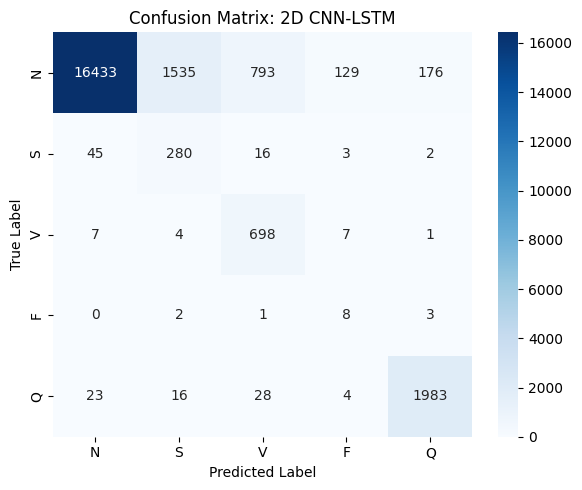

In [79]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# ─── 1. RELOAD THE RAW .npz AND REPEAT YOUR SPLIT ─────────────────────────────

data = np.load("ecg_1d_dataset.npz")
X_all   = data["X"]        # shape = (N_beats, L)
y_all   = data["y"]
groups  = data["record"]   # record IDs, used for group‐wise split

# exactly the same split you used before:
gss = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
_, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_test = X_all[test_idx]
y_test = y_all[test_idx]

# ─── 2. BUILD THE SPECTROGRAM DATASET + DATALOADER ────────────────────────────

test_ds = SpectrogramBeatDataset(
    X_beats     = X_test,
    y_beats     = y_test,
    fs          = 360,
    nperseg     = 64,
    noverlap    = 32,
    slice_width = 3,
    max_freq    = 100.0
)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

# ─── 3. RUN model2 ON THE TEST SET ─────────────────────────────────────────────

model2.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model2(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ─── 4. PRINT A CLASSIFICATION REPORT ──────────────────────────────────────────

print("=== 2D CNN-LSTM Test Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=['N','S','V','F','Q'],
    digits=4
))

# ─── 5. PLOT THE CONFUSION MATRIX ─────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['N','S','V','F','Q'],
            yticklabels=['N','S','V','F','Q'])
plt.title("Confusion Matrix: 2D CNN-LSTM")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [76]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pywt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

# ─── 0. LOAD YOUR PRE‐SEGMENTED BEATS ────────────────────────────────────────
# Assumes you saved everything in a .npz as in your earlier pipeline:
#   X: shape = (N_beats, 1, L) or (N_beats, L)
#   y: shape = (N_beats,)
#   record: shape = (N_beats,) giving the record id (for grouping)

data = np.load("ecg_1d_dataset.npz")
X = data["X"]
y = data["y"]
rec_ids = data["record"]

# If you still have a channel‐dim of 1, squeeze it:
if X.ndim == 3 and X.shape[1] == 1:
    X = X[:, 0, :]
elif X.ndim != 2:
    raise ValueError(f"Expected X to be (N,1,L) or (N,L), got {X.shape}")

print("Loaded:", X.shape, y.shape, rec_ids.shape)


# ─── 1. SCALOGRAM GENERATION ──────────────────────────────────────────────────

def compute_scalogram(
    beat: np.ndarray,
    wavelet: str = "morl",
    scales: np.ndarray = None,
    out_width: int = 128
) -> np.ndarray:
    """Compute CWT scalogram, then resample time axis to out_width."""
    if scales is None:
        # log-spaced between 1 and 128
        scales = np.logspace(np.log2(1), np.log2(128), num=32, base=2)
    coefs, _ = pywt.cwt(beat, scales, wavelet)
    S = np.abs(coefs)                      # (n_scales, L)
    L = S.shape[1]
    idx = np.linspace(0, L - 1, out_width).astype(int)
    return S[:, idx]                       # → (n_scales, out_width)


# ─── 2. DATASET ────────────────────────────────────────────────────────────────

class ScalogramBeatDataset(Dataset):
    def __init__(self,
                 X_beats: np.ndarray,   # (N, L)
                 y_beats: np.ndarray,   # (N,)
                 wavelet: str = "morl",
                 n_scales: int = 32,
                 out_width: int = 128):
        super().__init__()
        # prepare scales once
        self.scales = np.logspace(np.log2(1), np.log2(128),
                                  num=n_scales, base=2)
        self.wavelet = wavelet
        self.out_width = out_width

        specs = []
        for beat in X_beats:
            S = compute_scalogram(beat,
                                  wavelet=self.wavelet,
                                  scales=self.scales,
                                  out_width=self.out_width)
            specs.append(S)

        # stack and add channel dim
        self.X = np.stack(specs)[:, None, :, :]  # (N,1,n_scales,out_width)
        self.y = y_beats.copy()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).float()  # (1,scales,width)
        y = torch.tensor(self.y[i], dtype=torch.long)
        return x, y


# ─── 3. SIMPLE 2D‐CNN MODEL ──────────────────────────────────────────────────

class ScalogramCNN(nn.Module):
    def __init__(self, n_classes=5, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → (16, n_scales/2, out_width/2)
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → (32, n_scales/4, out_width/4)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)) # → (64,1,1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),               # → (64,)
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# ─── 4. TRAIN/TEST SPLIT BY RECORD ────────────────────────────────────────────

gss = GroupShuffleSplit(test_size=0.3, random_state=42, n_splits=1)
train_idx, test_idx = next(
    gss.split(np.zeros(len(y)), y, groups=rec_ids)
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ─── 5. BUILD DATA LOADERS ────────────────────────────────────────────────────

train_ds = ScalogramBeatDataset(X_train, y_train,
                                wavelet="morl",
                                n_scales=32,
                                out_width=128)
test_ds  = ScalogramBeatDataset(X_test,  y_test,
                                wavelet="morl",
                                n_scales=32,
                                out_width=128)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=4)


# ─── 6. INSTANTIATE MODEL & TRAIN ─────────────────────────────────────────────

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ScalogramCNN(n_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30
for epoch in range(1, num_epochs+1):
    # — train —
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # — eval —
    model.eval()
    test_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            test_loss += criterion(out, yb).item() * xb.size(0)
            correct   += (out.argmax(1) == yb).sum().item()
    test_loss /= len(test_loader.dataset)
    test_acc   = correct / len(test_loader.dataset)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test  Loss: {test_loss:.4f} | "
          f"Test  Acc:  {test_acc:.4f}")



Loaded: (108836, 216) (108836,) (108836,)
Epoch 01 | Train Loss: 0.4612 | Test  Loss: 0.3383 | Test  Acc:  0.9289
Epoch 02 | Train Loss: 0.3076 | Test  Loss: 0.3880 | Test  Acc:  0.9444
Epoch 03 | Train Loss: 0.2416 | Test  Loss: 0.4483 | Test  Acc:  0.9404
Epoch 04 | Train Loss: 0.2090 | Test  Loss: 0.3734 | Test  Acc:  0.9460
Epoch 05 | Train Loss: 0.1850 | Test  Loss: 0.3886 | Test  Acc:  0.9453
Epoch 06 | Train Loss: 0.1651 | Test  Loss: 0.4154 | Test  Acc:  0.9456
Epoch 07 | Train Loss: 0.1469 | Test  Loss: 0.4091 | Test  Acc:  0.9410
Epoch 08 | Train Loss: 0.1306 | Test  Loss: 0.4054 | Test  Acc:  0.9427
Epoch 09 | Train Loss: 0.1206 | Test  Loss: 0.3819 | Test  Acc:  0.9389
Epoch 10 | Train Loss: 0.1082 | Test  Loss: 0.4350 | Test  Acc:  0.9299
Epoch 11 | Train Loss: 0.0996 | Test  Loss: 0.4408 | Test  Acc:  0.9087
Epoch 12 | Train Loss: 0.0920 | Test  Loss: 0.4426 | Test  Acc:  0.9300
Epoch 13 | Train Loss: 0.0860 | Test  Loss: 0.4439 | Test  Acc:  0.9204
Epoch 14 | Train Loss:

In [81]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pywt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# ─── 0. LOAD YOUR PRE‐SEGMENTED BEATS ────────────────────────────────────────
data = np.load("ecg_1d_dataset.npz")
X = data["X"]
y = data["y"]
rec_ids = data["record"]

# squeeze out channel dim if present
if X.ndim == 3 and X.shape[1] == 1:
    X = X[:, 0, :]
elif X.ndim != 2:
    raise ValueError(f"Expected X to be (N,1,L) or (N,L), got {X.shape}")

# ─── 1. SCALOGRAM GENERATION ──────────────────────────────────────────────────
def compute_scalogram(beat, wavelet="morl", scales=None, out_width=128):
    if scales is None:
        scales = np.logspace(np.log2(1), np.log2(128), num=32, base=2)
    coefs, _ = pywt.cwt(beat, scales, wavelet)
    S = np.abs(coefs)  # (n_scales, L)
    L = S.shape[1]
    idx = np.linspace(0, L-1, out_width).astype(int)
    return S[:, idx]  # (n_scales, out_width)

# ─── 2. DATASET ────────────────────────────────────────────────────────────────
class ScalogramBeatDataset(Dataset):
    def __init__(self, X_beats, y_beats, wavelet="morl", n_scales=32, out_width=128):
        self.scales = np.logspace(np.log2(1), np.log2(128), num=n_scales, base=2)
        self.wavelet = wavelet
        self.out_width = out_width
        specs = []
        for beat in X_beats:
            S = compute_scalogram(beat,
                                  wavelet=self.wavelet,
                                  scales=self.scales,
                                  out_width=self.out_width)
            specs.append(S)
        self.X = np.stack(specs)[:, None, :, :]  # (N,1,scales,width)
        self.y = y_beats.copy()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).float()
        y = torch.tensor(self.y[i], dtype=torch.long)
        return x, y

# ─── 3. SIMPLE 2D‐CNN MODEL ──────────────────────────────────────────────────
class ScalogramCNN(nn.Module):
    def __init__(self, n_classes=5, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → (16,scales/2,width/2)
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → (32,scales/4,width/4)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)) # → (64,1,1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),               # → (64,)
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ─── 4. TRAIN/TEST SPLIT BY RECORD ────────────────────────────────────────────
gss = GroupShuffleSplit(test_size=0.3, random_state=42, n_splits=1)
train_idx, test_idx = next(gss.split(np.zeros(len(y)), y, groups=rec_ids))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ─── 5. DATA LOADERS ──────────────────────────────────────────────────────────
train_ds = ScalogramBeatDataset(X_train, y_train, wavelet="morl", n_scales=32, out_width=128)
test_ds  = ScalogramBeatDataset(X_test,  y_test,  wavelet="morl", n_scales=32, out_width=128)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=4)

# ─── 6. TRAIN LOOP ─────────────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ScalogramCNN(n_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30
for epoch in range(1, num_epochs+1):
    # — train —
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # — eval —
    model.eval()
    test_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            test_loss += criterion(out, yb).item() * xb.size(0)
            correct   += (out.argmax(1) == yb).sum().item()
    test_loss /= len(test_loader.dataset)
    test_acc   = correct / len(test_loader.dataset)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test  Loss: {test_loss:.4f} | "
          f"Test  Acc:  {test_acc:.4f}")

# ─── 7. FINAL EVALUATION ──────────────────────────────────────────────────────
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

# class names in AAMI order
class_names = ["N","S","V","F","Q"]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Epoch 01 | Train Loss: 0.4361 | Test  Loss: 0.2994 | Test  Acc:  0.9402
Epoch 02 | Train Loss: 0.2469 | Test  Loss: 0.3451 | Test  Acc:  0.9360
Epoch 03 | Train Loss: 0.2076 | Test  Loss: 0.3431 | Test  Acc:  0.9367
Epoch 04 | Train Loss: 0.1858 | Test  Loss: 0.3576 | Test  Acc:  0.9472
Epoch 05 | Train Loss: 0.1620 | Test  Loss: 0.3479 | Test  Acc:  0.9402
Epoch 06 | Train Loss: 0.1451 | Test  Loss: 0.3676 | Test  Acc:  0.9433
Epoch 07 | Train Loss: 0.1289 | Test  Loss: 0.3569 | Test  Acc:  0.9356
Epoch 08 | Train Loss: 0.1171 | Test  Loss: 0.3443 | Test  Acc:  0.9252
Epoch 09 | Train Loss: 0.1058 | Test  Loss: 0.3838 | Test  Acc:  0.9141
Epoch 10 | Train Loss: 0.0983 | Test  Loss: 0.3710 | Test  Acc:  0.9461
Epoch 11 | Train Loss: 0.0903 | Test  Loss: 0.4407 | Test  Acc:  0.9220
Epoch 12 | Train Loss: 0.0856 | Test  Loss: 0.3692 | Test  Acc:  0.9235
Epoch 13 | Train Loss: 0.0780 | Test  Loss: 0.4014 | Test  Acc:  0.9216
Epoch 14 | Train Loss: 0.0740 | Test  Loss: 0.4098 | Test  Acc: 

In [86]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.signal import stft, get_window
from torch.utils.data import Dataset, DataLoader
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# ─── 1. SPECTROGRAM GENERATION ────────────────────────────────────────────────

def compute_spectrogram(
    beat: np.ndarray,
    fs: int = 360,
    nperseg: int = 64,
    noverlap: int = 32,
    max_freq: float = 100.0
) -> np.ndarray:
    f, t, Zxx = stft(
        beat,
        fs=fs,
        window=get_window('hann', nperseg),
        nperseg=nperseg,
        noverlap=noverlap,
        boundary='zeros',
        padded=True
    )
    Sxx = np.abs(Zxx)
    Sxx = np.log1p(Sxx)
    freq_mask = f <= max_freq
    return Sxx[freq_mask, :]

# ─── 2. DATASET CLASS ─────────────────────────────────────────────────────────

class SpectrogramBeatDataset(Dataset):
    def __init__(self,
                 X_beats: np.ndarray,    # shape = (N, L)
                 y_beats: np.ndarray,    # shape = (N,)
                 fs: int = 360,
                 nperseg: int = 64,
                 noverlap: int = 32,
                 slice_width: int = 3,
                 max_freq: float = 100.0):
        specs, labels = [], []
        for beat, lbl in zip(X_beats, y_beats):
            Sxx = compute_spectrogram(beat, fs, nperseg, noverlap, max_freq)
            M, T = Sxx.shape
            pad = (slice_width - (T % slice_width)) % slice_width
            if pad > 0:
                Sxx = np.pad(Sxx, ((0,0),(0,pad)), 'constant')
                T += pad
            K = T // slice_width
            Sxx = Sxx.reshape(M, K, slice_width).transpose(1,0,2)
            specs.append(Sxx)
            labels.append(lbl)
        self.X = np.stack(specs)   # (N, K, M, slice_width)
        self.y = np.array(labels)  # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).float().unsqueeze(1)  # → (K,1,M,W)
        y = torch.tensor(self.y[i], dtype=torch.long)
        return x, y

# ─── 3. MODEL DEFINITION ──────────────────────────────────────────────────────

class CNN2DLSTM(nn.Module):
    def __init__(self, n_classes=5, cnn_channels=(16,32), lstm_hidden=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn_channels[0], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,1)),
            nn.Conv2d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2,1)),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels[1],
            hidden_size=lstm_hidden,
            batch_first=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(lstm_hidden, n_classes)
        )

    def forward(self, x):
        B, K, C, M, W = x.size()
        x = x.view(B*K, C, M, W)
        x = self.cnn(x)                # (B*K, C_out,1,1)
        x = x.view(B, K, -1)           # (B, K, C_out)
        out,_ = self.lstm(x)           # (B, K, H)
        last = out[:, -1, :]           # (B, H)
        return self.classifier(last)   # (B, n_classes)

# ─── 4. LOAD & PREPARE RAW BEATS ──────────────────────────────────────────────

data = np.load("ecg_1d_dataset.npz")
X    = data["X"]     # (N,1,L) or (N,L)
y    = data["y"]
rec_ids = data["record"]

if X.ndim==3 and X.shape[1]==1:
    X = X[:,0,:]
elif X.ndim!=2:
    raise ValueError(f"Expected X to be (N,L) or (N,1,L), got {X.shape}")

# ─── 5. TRAIN/TEST SPLIT ────────────────────────────────────────────────────────

gss = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
train_idx, test_idx = next(gss.split(X, y, groups=rec_ids))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ─── 6. SMOTE OVERSAMPLING + UNDER‐SAMPLE N CLASS ────────────────────────────

sampling_targets = {
    0: 50000, 1: 5000, 2: 8000, 3: 5000, 4: 8000
}

smote = SMOTE(sampling_strategy={cls: tgt for cls,tgt in sampling_targets.items() if cls!=0},
              k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

rus = RandomUnderSampler(sampling_strategy={0: sampling_targets[0]}, random_state=42)
X_bal, y_bal = rus.fit_resample(X_res, y_res)

print("After resampling:", {cls: int((y_bal==cls).sum()) for cls in np.unique(y_bal)})

# ─── 7. BUILD DATASETS & DATALOADERS ────────────────────────────────────────

train_ds = SpectrogramBeatDataset(
    X_beats    = X_bal,
    y_beats    = y_bal,
    fs         = 360,
    nperseg    = 64,
    noverlap   = 32,
    slice_width= 3,
    max_freq   = 100.0
)
test_ds = SpectrogramBeatDataset(
    X_beats    = X_test,
    y_beats    = y_test,
    fs         = 360,
    nperseg    = 64,
    noverlap   = 32,
    slice_width= 3,
    max_freq   = 100.0
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=4)

# ─── 8. INSTANTIATE & TRAIN WITH EARLY STOPPING ─────────────────────────────

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN2DLSTM(n_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_loss = float('inf')
patience, bad_epochs = 5, 0
num_epochs = 30

for epoch in range(1, num_epochs+1):
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(train_loader.dataset)

    model.eval()
    te_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            te_loss += criterion(out, yb).item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
    te_loss /= len(test_loader.dataset)
    acc = correct / len(test_loader.dataset)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {tr_loss:.4f} | "
          f"Test Loss:  {te_loss:.4f} | "
          f"Test Acc:   {acc:.4f}")

    # Early stopping check
    if te_loss < best_loss:
        best_loss = te_loss
        bad_epochs = 0
        torch.save(model.state_dict(), "best_cnn2dlstm.pt")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"No improvement for {patience} epochs. Stopping early.")
            break

# ─── 9. FINAL EVALUATION ───────────────────────────────────────────────────────

model.load_state_dict(torch.load("best_cnn2dlstm.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['N','S','V','F','Q']))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


After resampling: {np.int64(0): 50000, np.int64(1): 5000, np.int64(2): 8000, np.int64(3): 5000, np.int64(4): 8000}
Epoch 01 | Train Loss: 0.7932 | Test Loss:  0.4711 | Test Acc:   0.9114
Epoch 02 | Train Loss: 0.4744 | Test Loss:  0.5422 | Test Acc:   0.8485
Epoch 03 | Train Loss: 0.3533 | Test Loss:  0.4903 | Test Acc:   0.8647
Epoch 04 | Train Loss: 0.2945 | Test Loss:  0.5098 | Test Acc:   0.8430
Epoch 05 | Train Loss: 0.2606 | Test Loss:  0.5121 | Test Acc:   0.8352
Epoch 06 | Train Loss: 0.2357 | Test Loss:  0.5343 | Test Acc:   0.8287
No improvement for 5 epochs. Stopping early.

Classification Report:
              precision    recall  f1-score   support

           N       0.95      0.97      0.96     19066
           S       0.14      0.02      0.03       346
           V       0.63      0.49      0.55       717
           F       0.00      0.00      0.00        14
           Q       0.75      0.69      0.72      2054

    accuracy                           0.91     22197
   m

In [87]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pywt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix

# ─── 0. LOAD YOUR PRE‐SEGMENTED BEATS ────────────────────────────────────────
data = np.load("ecg_1d_dataset.npz")
X = data["X"]      # (N,1,L) or (N,L)
y = data["y"]      # (N,)
rec_ids = data["record"]

if X.ndim == 3 and X.shape[1] == 1:
    X = X[:,0,:]
elif X.ndim != 2:
    raise ValueError(f"Expected X to be (N,1,L) or (N,L), got {X.shape}")

print("Loaded:", X.shape, y.shape, rec_ids.shape)

# ─── 1. SCALOGRAM GENERATION ──────────────────────────────────────────────────
def compute_scalogram(beat, wavelet="morl", scales=None, out_width=128):
    if scales is None:
        scales = np.logspace(np.log2(1), np.log2(128), num=32, base=2)
    coefs, _ = pywt.cwt(beat, scales, wavelet)
    S = np.abs(coefs)
    idx = np.linspace(0, S.shape[1]-1, out_width).astype(int)
    return S[:, idx]

# ─── 2. DATASET ────────────────────────────────────────────────────────────────
class ScalogramBeatDataset(Dataset):
    def __init__(self, X_beats, y_beats, wavelet="morl", n_scales=32, out_width=128):
        self.scales   = np.logspace(np.log2(1), np.log2(128), num=n_scales, base=2)
        self.wavelet  = wavelet
        self.out_width= out_width
        specs = []
        for beat in X_beats:
            S = compute_scalogram(beat, wavelet=self.wavelet, scales=self.scales, out_width=self.out_width)
            specs.append(S)
        self.X = np.stack(specs)[:, None, :, :]
        self.y = y_beats.copy()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]).float(), torch.tensor(self.y[i], dtype=torch.long)

# ─── 3. MODEL ─────────────────────────────────────────────────────────────────
class ScalogramCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.2), nn.Linear(64,n_classes)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

# ─── 4. TRAIN/TEST SPLIT BY RECORD ───────────────────────────────────────────
gss = GroupShuffleSplit(test_size=0.3, random_state=42, n_splits=1)
train_idx, test_idx = next(gss.split(np.zeros(len(y)), y, groups=rec_ids))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ─── 5. SMOTE + UNDER‐SAMPLE ─────────────────────────────────────────────────
targets = {0:50000,1:5000,2:8000,3:5000,4:8000}
sm = SMOTE(sampling_strategy={k:v for k,v in targets.items() if k!=0}, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
rus = RandomUnderSampler(sampling_strategy={0:targets[0]}, random_state=42)
X_bal, y_bal = rus.fit_resample(X_res, y_res)
print("After resample:", {int(c):(y_bal==c).sum() for c in np.unique(y_bal)})

# ─── 6. DATALOADERS ─────────────────────────────────────────────────────────
train_ds = ScalogramBeatDataset(X_bal, y_bal)
test_ds  = ScalogramBeatDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False,num_workers=4)

# ─── 7. TRAIN + EARLY STOPPING ───────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ScalogramCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_loss = float('inf')
patience, bad_epochs = 5, 0
num_epochs = 50

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss = 0
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for xb,yb in test_loader:
            xb,yb = xb.to(device), yb.to(device)
            out = model(xb)
            test_loss += criterion(out,yb).item()*xb.size(0)
            correct   += (out.argmax(1)==yb).sum().item()
    test_loss /= len(test_loader.dataset)
    test_acc  = correct / len(test_loader.dataset)

    print(f"Epoch {epoch:02d}: Train Loss={train_loss:.4f} | Val Loss={test_loss:.4f} | Val Acc={test_acc:.4f}")

    # Early stopping check
    if test_loss < best_loss:
        best_loss = test_loss
        bad_epochs = 0
        torch.save(model.state_dict(), "best_scalogram_cnn.pt")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"No improvement for {patience} epochs. Early stopping.")
            break

# ─── 8. FINAL EVALUATION ─────────────────────────────────────────────────────
model.load_state_dict(torch.load("best_scalogram_cnn.pt"))
model.eval()
y_true,y_pred = [], []
with torch.no_grad():
    for xb,yb in test_loader:
        out = model(xb.to(device))
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['N','S','V','F','Q']))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Loaded: (108836, 216) (108836,) (108836,)
After resample: {0: np.int64(50000), 1: np.int64(5000), 2: np.int64(8000), 3: np.int64(5000), 4: np.int64(8000)}
Epoch 01: Train Loss=0.7438 | Val Loss=0.3622 | Val Acc=0.9337
Epoch 02: Train Loss=0.4801 | Val Loss=0.4563 | Val Acc=0.8961
Epoch 03: Train Loss=0.3594 | Val Loss=0.4443 | Val Acc=0.8931
Epoch 04: Train Loss=0.2873 | Val Loss=0.4544 | Val Acc=0.8946
Epoch 05: Train Loss=0.2442 | Val Loss=0.5119 | Val Acc=0.8810
Epoch 06: Train Loss=0.2156 | Val Loss=0.4694 | Val Acc=0.9096
No improvement for 5 epochs. Early stopping.

Classification Report:
              precision    recall  f1-score   support

           N       0.95      0.98      0.97     28961
           S       0.17      0.01      0.02       380
           V       0.93      0.78      0.85      1760
           F       0.20      0.01      0.01       378
           Q       0.70      0.70      0.70      2054

    accuracy                           0.93     33533
   macro avg      